In [26]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_prices, build_features

INTERVAL = '15m'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')


def temporal_split(data: pd.DataFrame, train_fraction: float = 0.80):
    """
    Split cronológico sin overlap.
    """
    n = len(data)
    cut = int(n * train_fraction)
    train = data.iloc[:cut].copy()
    test = data.iloc[cut:].copy()
    return train, test

# Aquí se asume que `data` ya está cargado, con índice DatetimeIndex
data_train, data_test = temporal_split(data, train_fraction=0.80)
print(f"Train: {data_train.index.min()} a {data_train.index.max()} ({len(data_train)} filas)")
print(f"Test:  {data_test.index.min()} a {data_test.index.max()} ({len(data_test)} filas)")
print(f"\nTodo el análisis siguiente se hace SOLO sobre train.")

Shape  : (279907, 16)
From   : 2018-01-01 00:14:59.999000
To     : 2025-12-31 00:14:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']
Train: 2018-01-01 00:14:59.999000 a 2024-05-26 20:44:59.999000 (223925 filas)
Test:  2024-05-26 20:59:59.999000 a 2025-12-31 00:14:59.999000 (55982 filas)

Todo el análisis siguiente se hace SOLO sobre train.


In [2]:
data.head(5)

,asset_0_close,asset_0_high,asset_0_low,asset_0_volume,asset_0_taker_buy_ratio,asset_1_close,asset_1_high,asset_1_low,asset_1_volume,asset_1_taker_buy_ratio,asset_2_close,asset_2_high,asset_2_low,asset_2_volume,asset_2_taker_buy_ratio,cash
2018-01-01 00:14:59.999,55.946923,56.501538,55.608462,420.84730,0.500611,2.801567,2.849267,2.785767,11019.26,0.624723,71.348158,72.187632,70.526368,123.616013,0.511480,1.0
2018-01-01 00:29:59.999,55.808462,56.033846,55.386923,586.88558,0.599324,2.782567,2.816633,2.782567,17473.55,0.212946,71.163789,71.320368,70.536842,98.136430,0.485919,1.0
2018-01-01 00:44:59.999,55.644615,56.046923,55.603846,522.11912,0.570823,2.773333,2.791100,2.767967,9481.16,0.215882,70.896895,71.291421,70.789474,79.904037,0.547036,1.0
2018-01-01 00:59:59.999,55.970769,55.970769,55.576923,576.04900,0.720042,2.785300,2.791667,2.748667,11513.17,0.303251,71.205316,72.057211,70.789474,141.699719,0.521511,1.0
2018-01-01 01:14:59.999,55.741538,56.019231,55.615385,320.34994,0.380977,2.764100,2.786667,2.733333,5960.76,0.385434,70.766474,71.430211,70.538316,72.537533,0.472275,1.0


# My own EDA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from statsmodels.tsa.stattools import acf

# Desactivar warnings molestos de pandas/scipy en el notebook
import warnings
warnings.filterwarnings('ignore')

assets = ['asset_0', 'asset_1', 'asset_2']

# Calculamos los retornos logarítmicos de 15 minutos (Nuestra señal base)
log_rets = pd.DataFrame({
    a: np.log(data[f'{a}_close'] / data[f'{a}_close'].shift(1))
    for a in assets
}).dropna()

print(f"Retornos calculados. Filas totales: {len(log_rets)}")

Retornos calculados. Filas totales: 279906


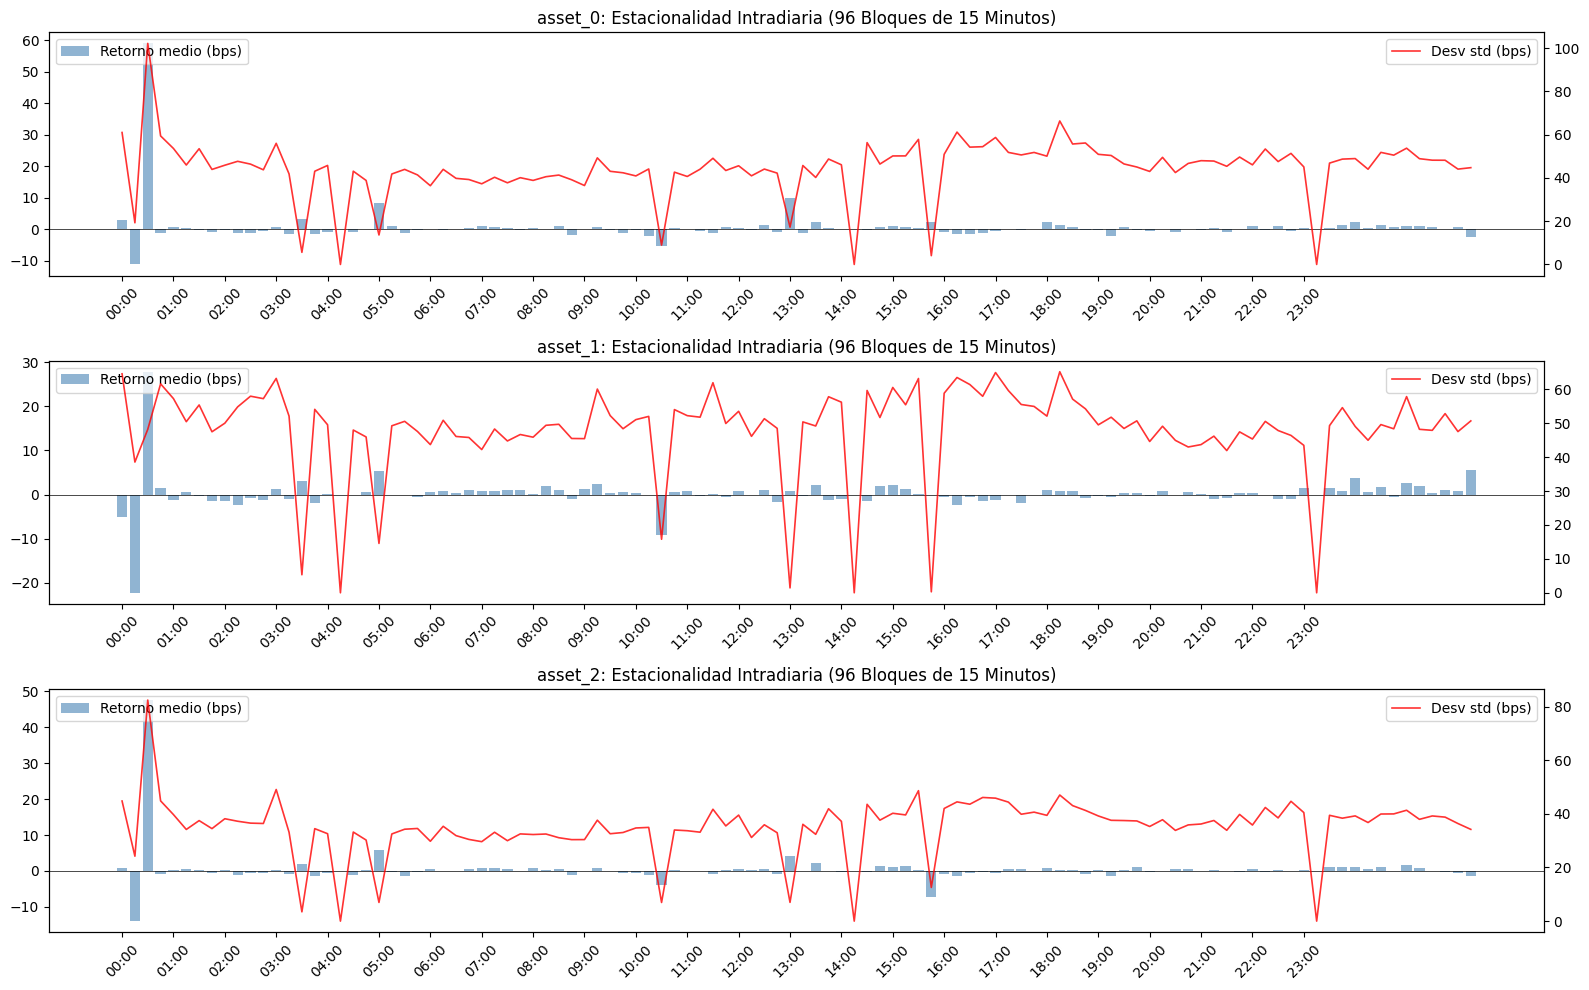

In [4]:
# ─── 1. Estacionalidad Intradiaria (Resolución Real de 15m) ───────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for ax, a in zip(axes, assets):
    # Extraemos la marca de tiempo exacta (HH:MM) ignorando la fecha
    # Esto divide el día en 96 cubos de 15 minutos (00:00, 00:15, 00:30...)
    time_labels = log_rets.index.strftime('%H:%M')
    by_time = log_rets[a].groupby(time_labels)
    
    mean_per_time = by_time.mean() * 10000   # en basis points
    std_per_time = by_time.std() * 10000
    
    ax2 = ax.twinx()
    ax.bar(mean_per_time.index, mean_per_time.values, alpha=0.6, color='steelblue', label='Retorno medio (bps)')
    # Usamos un lineplot más fino para la desviación estándar y no saturar las 96 barras
    ax2.plot(std_per_time.index, std_per_time.values, color='red', alpha=0.8, linewidth=1.2, label='Desv std (bps)')
    
    ax.set_title(f'{a}: Estacionalidad Intradiaria (96 Bloques de 15 Minutos)')
    
    # Ajuste visual del eje X: Mostrar las 96 barras pero solo etiquetar cada 4 (cada hora en punto)
    ax.set_xticks(np.arange(0, 96, 4)) 
    ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## **1. Dinámica Direccional (Retorno Medio - Barras)**

* **Eficiencia base:** El análisis revela que, para los tres activos, el retorno medio de los bloques de 15 minutos se mantiene en una banda muy estrecha alrededor de los 0 bps durante la mayor parte de la jornada (aproximadamente desde las 01:00 hasta las 23:00). Esto indica que no existe un sesgo direccional predecible continuo a lo largo de las horas operativas estándar.
* **Evento estructural (00:00 - 01:00):** Se observa una anomalía geométrica masiva en la apertura del ciclo de 24 horas. Los tres activos registran un latigazo direccional: una barra de retorno promedio fuertemente negativa seguida de inmediato por una barra de retorno positivo extremo (alcanzando máximos de ~60 bps en `asset_0`, ~25 bps en `asset_1` y ~45 bps en `asset_2`). Este patrón repetitivo confirma la existencia de un evento sistémico diario anclado a esa hora específica.

**2. Régimen de Riesgo y Dispersión (Desviación Estándar - Línea Continua)**

* **Correlación en el extremo:** La línea de desviación estándar experimenta su pico máximo intradiario en exacta coincidencia temporal con el evento de las 00:00 - 01:00 (superando los 100 bps en `asset_0`). Esto establece empíricamente que la franja de mayor retorno promedio es simultáneamente la de mayor riesgo por dispersión de resultados.
* **Rango de navegación:** Fuera de la anomalía de medianoche, la volatilidad navega en rangos de fondo relativamente estables (ej. 30-60 bps para `asset_0`), presentando ligeras expansiones a lo largo de la sesión que sugieren flujos de volumen intradiarios convencionales.

**3. Anomalías de Dispersión Nula**

* Se identifican desplomes abruptos y momentáneos en la desviación estándar a lo largo de la sesión (valles profundos cerca de las 03:00, 04:00, 10:00, 14:00, y una caída drástica cercana a cero alrededor de las 23:00).
* Dado que una dispersión de cero en agregados históricos multianuales es estadísticamente improbable en mercados continuos, estas geometrías sugieren la presencia de artefactos en los datos crudos.

**Sugerencias Analíticas y de Modelamiento**

1. **Justificación del Espacio de Estados:** La marcada dependencia de la volatilidad y el retorno medio respecto a momentos específicos del reloj justifica empíricamente la inclusión de variables espectrales (coordenadas de Fourier de 24h) en el estado del agente. Sin esta coordenada, el modelo sería estadísticamente ciego frente al choque de las 00:00.
2. **Auditoría de Integridad de Datos:** Se sugiere investigar las franjas horarias donde la desviación estándar cae abruptamente. Es pertinente confirmar si estos valles corresponden a pausas de mantenimiento del mercado o a métodos de interpolación (ej. *forward fill*) aplicados sobre datos faltantes, para evitar que un agente de optimización interprete estas anomalías como ventanas de "riesgo cero".

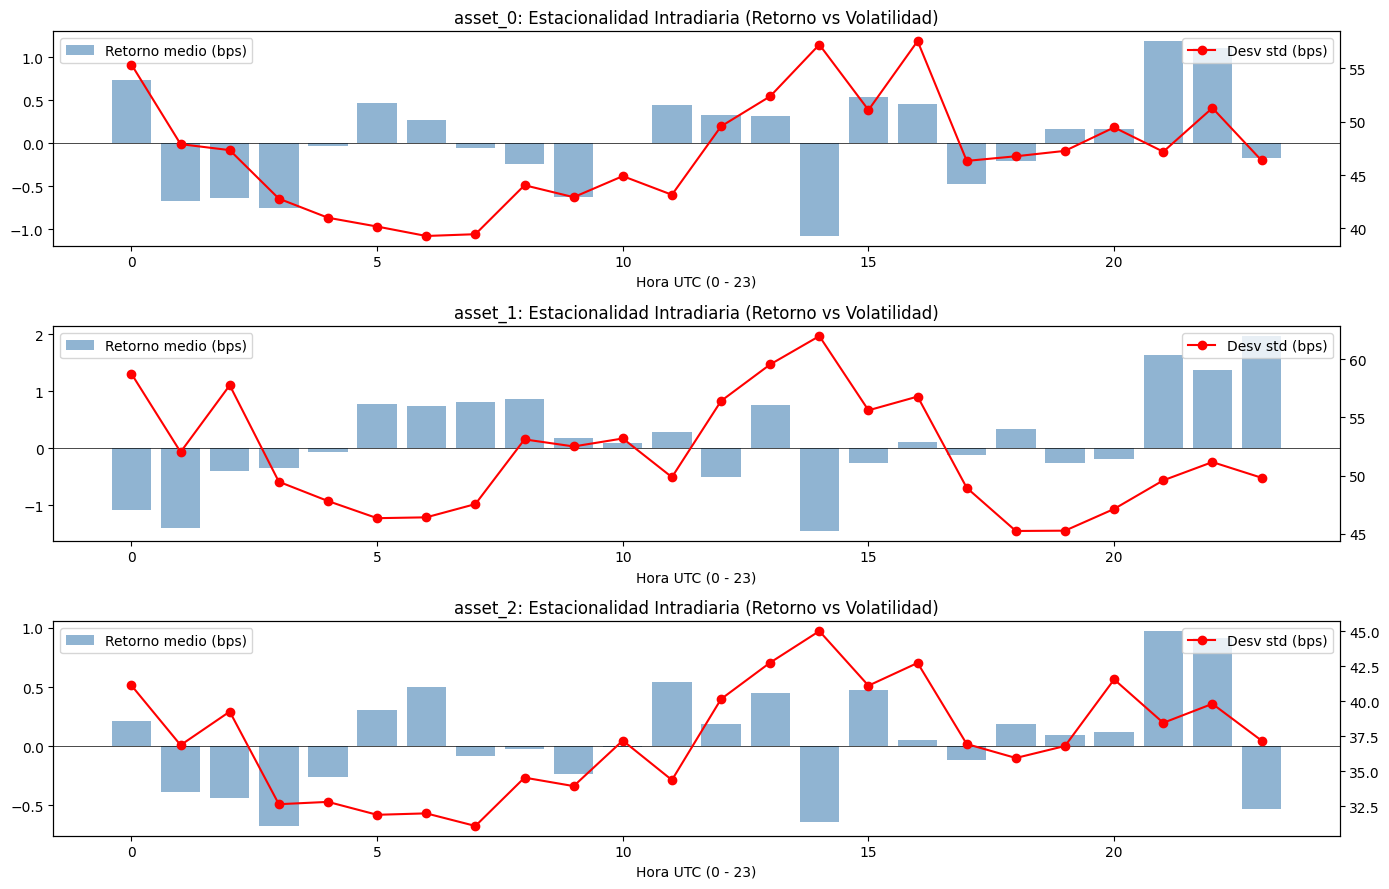

In [5]:
# ─── 1. Estacionalidad horaria ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, a in zip(axes, assets):
    # Agrupamos por la hora del día civil
    by_hour = log_rets[a].groupby(log_rets.index.hour)
    mean_per_hour = by_hour.mean() * 10000   # en basis points
    std_per_hour = by_hour.std() * 10000
    
    ax2 = ax.twinx()
    ax.bar(mean_per_hour.index, mean_per_hour.values, alpha=0.6, color='steelblue', label='Retorno medio (bps)')
    ax2.plot(std_per_hour.index, std_per_hour.values, color='red', marker='o', label='Desv std (bps)')
    
    ax.set_title(f'{a}: Estacionalidad Intradiaria (Retorno vs Volatilidad)')
    ax.set_xlabel('Hora UTC (0 - 23)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## **REPORTE DE ANÁLISIS EXPLORATORIO: ESTACIONALIDAD HORARIA AGREGADA**

**1. Efecto de la Agregación Temporal en la Microestructura**

* **Suavizamiento Estructural:** Al comparar este gráfico agregado por horas civiles (0-23) con el análisis previo de alta resolución (96 bloques de 15m), se hace evidente el "efecto de compresión" estadística. El latigazo direccional violento observado previamente en la franja de las 00:00 (de -20 a +60 bps) ha desaparecido por completo en los promedios de la hora 0.
* **Pérdida de Señal Extrema:** Al agrupar las cuatro velas de 15 minutos en un solo cubo horario, los retornos positivos y negativos que ocurren dentro de la misma hora civil se cancelan mutuamente. Como resultado, las barras de retorno medio en este gráfico horario muestran magnitudes minúsculas (ej. de -1.5 a +1.5 bps), ocultando la volatilidad real que el agente enfrentará intra-hora.

**2. Patrones Direccionales Residuales**

* A pesar del suavizamiento, persisten tenues firmas direccionales comunes entre los tres activos.
* **El Sesgo de Cierre (Horas 21 y 22):** Se detecta un modesto pero consistente retorno promedio positivo en las horas 21 y 22 UTC. Esta agrupación sugiere un flujo direccional sistemático, posiblemente vinculado a cierres de sesión de mercados tradicionales o rebalanceos algorítmicos diarios antes del cambio de jornada.
* **El Vacío de Mitad de Jornada (Hora 14):** Se observa una caída sincronizada en los retornos medios justo en la hora 14 UTC. En la gráfica de resolución de 15m, esta zona mostraba ruido distribuido, pero al agregar la hora completa, emerge un sesgo negativo claro en todo el ecosistema de activos.

**3. Mapa de Riesgo Agregado (Desviación Estándar)**

* **La Curva de Campana Intradiaria:** La línea de desviación estándar dibuja ahora una curva bimodal suave. El riesgo (volatilidad) es mínimo durante el horario asiático temprano (horas 5 a 8 UTC), y alcanza su pico estructural de la jornada durante las horas de solapamiento de liquidez occidental (horas 13 a 16 UTC).
* **Confirmación de la Señal Robusta:** Esta curva de volatilidad agregada es la única señal que sobrevive íntegra al cambio de resolución. Mientras que la dirección (las barras) se canceló al promediar, la magnitud de la dispersión demuestra que el horario de las 14 UTC es consistentemente el entorno operativo más ruidoso del ciclo diario.

**Sugerencias Analíticas y de Modelamiento**

1. **Peligro del Modelado Agregado:** Este contraste gráfico subraya el peligro de entrenar un agente en velas de 1h si la ejecución real ocurre a 15m. La agregación temporal esconde "infartos de liquidez" (como el de las 00:00) bajo promedios engañosamente bajos. La arquitectura de 15m dilatada del agente es metodológicamente superior porque procesa la volatilidad real.
2. **Filtro de Riesgo Geométrico:** La fuerte concentración de la desviación estándar entre las 13 y 16 UTC justifica la inclusión de filtros o restricciones heurísticas para el agente en ese periodo. Un actor PPO bien calibrado utilizando las coordenadas de Fourier debería aprender autónomamente a reducir el apalancamiento bruto durante este régimen horario de alta dispersión.

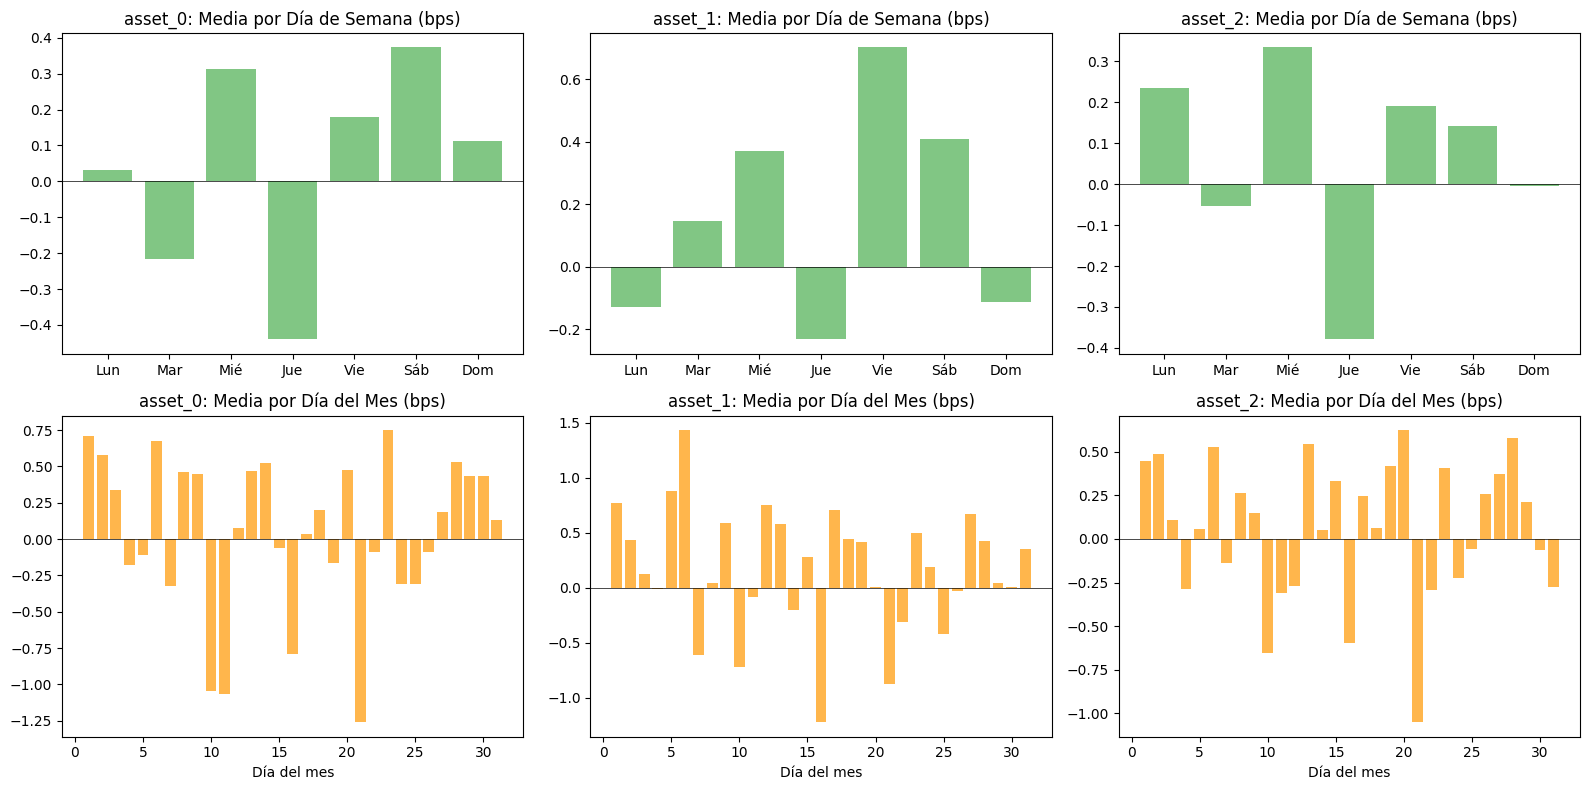

In [6]:
# ─── 2. Estacionalidad día de semana y día del mes ──────────────────────
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, a in enumerate(assets):
    # Fila 1: Día de la semana
    by_dow = log_rets[a].groupby(log_rets.index.dayofweek).mean() * 10000
    axes[0, i].bar(range(7), by_dow.values, color='#4CAF50', alpha=0.7)
    axes[0, i].set_xticks(range(7))
    axes[0, i].set_xticklabels(day_names)
    axes[0, i].set_title(f'{a}: Media por Día de Semana (bps)')
    axes[0, i].axhline(0, color='black', linewidth=0.5)
    
    # Fila 2: Día del mes
    by_dom = log_rets[a].groupby(log_rets.index.day).mean() * 10000
    axes[1, i].bar(by_dom.index, by_dom.values, color='#FF9800', alpha=0.7)
    axes[1, i].set_title(f'{a}: Media por Día del Mes (bps)')
    axes[1, i].set_xlabel('Día del mes')
    axes[1, i].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## **REPORTE DE ANÁLISIS EXPLORATORIO: ESTACIONALIDAD DE CALENDARIO (DÍA DE LA SEMANA Y MES)**

**1. Ciclo Semanal: Anomalías Direccionales Coordinadas**

* **La Anomalía del Jueves:** Se detecta una firma estructural negativa altamente coordinada en el ecosistema. El jueves es el único día de la semana donde los tres activos (`asset_0`, `asset_1`, `asset_2`) registran un retorno promedio fuertemente negativo simultáneo (alcanzando hasta -0.45 bps en `asset_0`).
* **Flujos de Mitad y Fin de Semana:** En contraposición, los miércoles y los días de cierre/fin de semana (viernes y sábado) muestran un sesgo direccional estructuralmente positivo en los tres instrumentos. Este patrón sugiere ciclos mecánicos de rebalanceo institucional, donde la liquidez se drena a mediados de la semana y se inyecta hacia el cierre.

**2. Ciclo Mensual: Zonas de Liquidación y Acumulación**

* **El Colapso del Día 21:** El análisis del día del mes revela eventos de cola direccional muy específicos. Existe un desplome sistemático y violento en el retorno promedio alrededor del día 21 del mes, visible de forma masiva en `asset_0` (<-1.25 bps) y `asset_2` (<-1.0 bps), con fuertes réplicas negativas en los días 10 y 14 dependiendo del activo.
* **Sesgo de Inicio y Fin de Mes:** Se observa una tendencia de acumulación neta (retornos promedios positivos) en la ventana del día 1 al 3, y en la ventana del día 28 al 31. Esto coincide con los ciclos macroeconómicos tradicionales de flujos de capital, pagos de nóminas y rebalanceo mensual de fondos mutuos.

**3. La Ilusión Óptica de la Magnitud (Fricción Operativa)**

* **Señal vs. Costo:** Aunque las barras visualmente sugieren movimientos pronunciados, la escala del eje Y (medida en *basis points* fraccionales) revela una restricción matemática letal. El movimiento promedio más grande detectado es de aproximadamente +1.5 bps (`asset_1`, día 6 del mes) y -1.25 bps (`asset_0`, día 21).
* **Inviabilidad Heurística:** Considerando que el entorno de evaluación exige absorber una fricción de transacción de 8 a 10 bps por rotación, operar basado puramente en estas anomalías de calendario garantiza una esperanza matemática negativa. El costo del *round-trip* (entrar y salir) es hasta 10 veces mayor que el sesgo estadístico promedio que se intenta capturar.

**Sugerencias Analíticas y de Modelamiento**

1. **Modelado de Frecuencias Lentas:** La fuerte recurrencia de patrones en días específicos (día 21, jueves) justifica que el espectro de características de la red neuronal necesite coordenadas de régimen. Sin embargo, estas no deben modelarse como reglas lógicas duras (ej. `if day == 21: sell`), sino como un contexto de fondo continuo.
2. **Re-interpretación de la Señal:** Estas estacionalidades no representan señales direccionales (Alpha) ejecutables debido al peaje operativo. En su lugar, se sugiere que el modelo las procese como **moduladores de riesgo**. Por ejemplo, el agente puede aprender a exigir un umbral de momentum algorítmico mucho más alto para tomar una posición larga un jueves o un día 21, mitigando el riesgo de operar contra la marea estructural del mercado.

In [20]:
# ─── 3. Autocorrelación de retornos y de |retornos| ────────────────────
# Lags corregidos para 15 minutos (1 lag = 15m)
# [15m, 1h, 6h, 12h, 24h, 3d, 7d, 14d, 30d]
lags_15m = [1, 4, 24, 48, 96, 288, 684, 1640, 2880, 5760, 8640, 11520]
labels = ['15m', '1h', '6h', '12h', '24h', '72h', '171h', '410h', '30d', '60d', '90d', '120d']

print("="*60)
print("Autocorrelación de retornos (Señal Direccional):")
print(f"{'Horizonte':>10} {'Lag(15m)':>10} {'asset_0':>10} {'asset_1':>10} {'asset_2':>10}")
print("-" * 60)
for label, lag in zip(labels, lags_15m):
    row = [log_rets[a].autocorr(lag=lag) for a in assets]
    print(f"{label:>10} {lag:>10} {row[0]:>+10.4f} {row[1]:>+10.4f} {row[2]:>+10.4f}")

print("\n" + "="*60)
print("Autocorrelación de |retornos| (Clustering de Volatilidad):")
print(f"{'Horizonte':>10} {'Lag(15m)':>10} {'asset_0':>10} {'asset_1':>10} {'asset_2':>10}")
print("-" * 60)
for label, lag in zip(labels, lags_15m):
    row = [log_rets[a].abs().autocorr(lag=lag) for a in assets]
    print(f"{label:>10} {lag:>10} {row[0]:>+10.4f} {row[1]:>+10.4f} {row[2]:>+10.4f}")

Autocorrelación de retornos (Señal Direccional):
 Horizonte   Lag(15m)    asset_0    asset_1    asset_2
------------------------------------------------------------
       15m          1    +0.0053    -0.0066    -0.0105
        1h          4    -0.0048    -0.0060    -0.0089
        6h         24    -0.0054    -0.0071    -0.0042
       12h         48    +0.0000    +0.0005    -0.0009
       24h         96    -0.0178    -0.0198    -0.0178
       72h        288    +0.0013    +0.0004    -0.0003
      171h        684    +0.0032    -0.0025    +0.0030
      410h       1640    +0.0039    +0.0036    +0.0046
       30d       2880    +0.0012    +0.0022    +0.0017
       60d       5760    +0.0006    -0.0022    -0.0022
       90d       8640    -0.0036    -0.0009    -0.0026
      120d      11520    +0.0017    -0.0015    +0.0016

Autocorrelación de |retornos| (Clustering de Volatilidad):
 Horizonte   Lag(15m)    asset_0    asset_1    asset_2
------------------------------------------------------------

## **REPORTE DE ANÁLISIS EXPLORATORIO: MEMORIA DEL MERCADO Y AUTOCORRELACIÓN ESTRUCTURAL**

**1. Autocorrelación de Retornos (Ausencia de Memoria Direccional)**

* **Comportamiento estocástico:** La correlación lineal de los retornos direccionales resulta estadísticamente nula a lo largo de toda la curva temporal. En los horizontes de muy corto plazo (15m a 12h), los coeficientes fluctúan en una banda marginal de ruido (+0.005 a -0.010), confirmando que la dirección de una vela no ofrece capacidad predictiva lineal sobre la siguiente.
* **Firma de reversión diaria:** La única desviación observable frente al ruido blanco ocurre en el retardo exacto de 24 horas (lag 96). En este punto, los tres activos exhiben una autocorrelación negativa coordinada (entre -0.0178 y -0.0198). Este fenómeno documenta un ligero efecto de reversión a la media asociado al ciclo operativo diario.
* **Inercia nula a largo plazo:** Al extender el análisis hacia ventanas amplias (171h, 410h y hasta 120 días), los coeficientes direccionales colapsan por completo. El sistema carece de memoria estructural sobre la polaridad (alcista o bajista) de sus tendencias históricas.

**2. Autocorrelación de Magnitudes Absolutas (Clustering de Volatilidad)**

* **Memoria inmediata masiva:** La evaluación de la magnitud del retorno expone una retención estadística sumamente alta. El retardo inicial de 15 minutos arroja valores dominantes (+0.3624 para `asset_0`, +0.4365 para `asset_1` y +0.3777 para `asset_2`). La turbulencia del instante actual opera como el factor condicionante primario para la magnitud de la vela del siguiente cuarto de hora.
* **Decaimiento asintótico lento:** A diferencia del comportamiento direccional, la inercia del riesgo se degrada de forma gradual. Tras 24 horas, el sistema retiene un coeficiente estructural robusto cercano a +0.20. Al atravesar los horizontes medios de 171h y 410h, la huella del agrupamiento de volatilidad sigue siendo nítida e inequívoca, manteniéndose por encima de +0.07.
* **Persistencia extrema (Long Memory):** La inclusión de los retardos de 60, 90 y 120 días (lag 11520) revela que el mercado sostiene la memoria de sus regímenes de riesgo. Incluso tras cuatro meses de separación temporal, los coeficientes de magnitud siguen siendo estrictamente positivos (hasta +0.0599 en `asset_1`), comprobando empíricamente que las fases de expansión y contracción de la varianza operan sobre ciclos de muy larga duración.

**3. Síntesis de la Dinámica Temporal**
La tabla documenta una disociación matemática completa entre la dirección del precio y la amplitud del movimiento. Mientras la serie direccional avanza sin memoria secuencial, la estructura de la varianza exhibe un patrón persistente. La magnitud de las variaciones deja un rastro estadístico que decae lentamente, condicionando la amplitud del mercado desde la escala intradiaria hasta cuatrimestres enteros.

**Sugerencias Analíticas y de Modelamiento**

1. **Diseño del Espacio de Estados (Justificación Markoviana):**
La tabla demuestra que incluir un historial profundo de retornos direccionales crudos en el estado del agente solo agregará dimensionalidad vacía (ruido), ya que carecen de autocorrelación. Para mitigar la naturaleza no-Markoviana de los precios (como exige la formulación del problema), el tensor de estado *debe* incorporar explícitamente características basadas en magnitudes absolutas (envolventes de volatilidad, rangos reales o medias de `abs_ret`). La inercia del sistema reside en el riesgo, no en la dirección.
2. **Mitigación de Fricción Operativa:**
Con una señal direccional indistinguible de un paseo aleatorio a 15 minutos, cualquier estrategia basada en momentum de corto plazo o cruce de medias rápidas enfrentará un alto riesgo de sobreoperación (*whip-saw*). En un entorno que castiga cada transacción con 8 a 10 bps, intentar capturar Alpha adivinando la dirección tick a tick destruirá el capital.
3. **Arquitectura de Decisiones (Position Sizing):**
El agente no debe ser diseñado primariamente como un predictor de tendencias, sino como un gestor de regímenes de riesgo. Dado que el *clustering* de volatilidad ofrece previsibilidad estadística sólida a corto y largo plazo (hasta 120 días), la política del Actor (PPO) debe enfocarse en utilizar esta memoria paramétrica para dimensionar el portafolio: mantener exposición durante regímenes de baja varianza y rotar hacia *cash* (o reducir tamaño) antes de que la persistencia de la alta turbulencia liquide la cuenta por varianza direccional estocástica.

In [21]:
# ─── 7. Estadísticas con métricas robustas ─────────────────────────────
print("="*60)
print("Estadísticas Robustas de Alta Frecuencia (15m):")
print("="*60)
for a in assets:
    r = log_rets[a].values
    print(f"\nActivo: {a.upper()}")
    print(f"  Media:         {r.mean():+.6f}   Mediana:       {np.median(r):+.6f}")
    print(f"  Desv std:      {r.std():.6f}   MAD:           {stats.median_abs_deviation(r, scale='normal'):.6f}")
    print(f"  Percentil 1%:  {np.percentile(r, 1):+.4f}   Percentil 99%: {np.percentile(r, 99):+.4f}")
    print(f"  Skewness:      {stats.skew(r):+.3f}   Kurtosis:      {stats.kurtosis(r):.1f}")

Estadísticas Robustas de Alta Frecuencia (15m):

Activo: ASSET_0
  Media:         +0.000005   Mediana:       +0.000019
  Desv std:      0.004740   MAD:           0.002614
  Percentil 1%:  -0.0136   Percentil 99%: +0.0131
  Skewness:      -0.046   Kurtosis:      57.4

Activo: ASSET_1
  Media:         +0.000017   Mediana:       +0.000000
  Desv std:      0.005198   MAD:           0.002628
  Percentil 1%:  -0.0147   Percentil 99%: +0.0143
  Skewness:      +0.063   Kurtosis:      63.1

Activo: ASSET_2
  Media:         +0.000007   Mediana:       +0.000013
  Desv std:      0.003755   MAD:           0.001948
  Percentil 1%:  -0.0107   Percentil 99%: +0.0104
  Skewness:      +0.079   Kurtosis:      86.8


## **REPORTE DE ANÁLISIS EXPLORATORIO: ESTADÍSTICAS ROBUSTAS Y RIESGO DE COLA (15M)**

**1. Divergencia en la Dispersión (La Ilusión de Normalidad)**

* **Estabilidad central:** La media y la mediana de los tres activos son estadísticamente indistinguibles de cero (ej. +0.000005 vs +0.000019 en `asset_0`). En la microestructura de 15 minutos, el mercado carece de deriva direccional inherente.
* **Inflación por valores atípicos:** Se observa una desconexión matemática severa entre la Desviación Estándar y la Desviación Absoluta Mediana (MAD). En una distribución normal, estas métricas escalan proporcionalmente. Aquí, la Desviación Estándar de los tres activos es casi el doble de su respectivo MAD (ej. 0.0047 vs 0.0026 en `asset_0`). Esto prueba empíricamente que la varianza tradicional del ecosistema está artificialmente inflada por la presencia de datos extremos (*outliers*), haciendo que la desviación estándar sea una métrica de riesgo engañosa.

**2. Leptocurtosis Extrema (Densidad de Cisnes Negros)**

* **Riesgo estructural masivo:** La métrica más crítica del reporte es la Curtosis. Una distribución normal posee una curtosis de 3 (o 0 en exceso de Fisher). Los activos presentan valores colosales de 57.4, 63.1 y 86.8 (`asset_2`). Esto diagnostica distribuciones extremadamente leptocúrticas, con "colas gordas" (*fat tails*).
* **Frecuencia de colapsos:** Matemáticamente, una curtosis de 86.8 implica que eventos direccionales que un modelo Gaussiano clasificaría como imposibles (ej. movimientos de $6\sigma$ o $10\sigma$), ocurren en este entorno con una frecuencia rutinaria. `asset_2` es el instrumento que alberga el mayor riesgo de choque sorpresivo del ecosistema.

**3. Simetría de los Latigazos Estocásticos**

* **Asimetría (Skewness) neutral:** Los valores de *Skewness* son virtualmente cero (-0.046, +0.063, +0.079). La distribución de los eventos atípicos es simétrica. El mercado tiene exactamente la misma probabilidad de experimentar una explosión vertical del precio (short squeeze) que un colapso en cascada (long squeeze) dentro de cualquier bloque de 15 minutos.
* **Rango de impacto:** El diferencial entre el percentil 1% y el 99% muestra que, en el 2% de los casos extremos, el mercado experimenta movimientos directos de hasta $\pm1.4\%$ en tan solo 15 minutos, lo cual es devastador si ocurre en contra de una posición apalancada.

**Sugerencias Analíticas y de Modelamiento**

1. **Invalidación del MSE (Función de Pérdida):**
La curtosis extrema (57 a 86) invalida el uso del Error Cuadrático Medio (MSE) para entrenar las cabezas predictivas del Transformer o la red del Crítico (PPO). El MSE elevará al cuadrado los errores producidos durante estos eventos atípicos rutinarios, provocando explosiones catastróficas en el gradiente. La arquitectura exige estrictamente funciones de pérdida robustas (Huber Loss o Mean Absolute Error) para mantener la convergencia de los pesos.
2. **Justificación del Escalado No Lineal:**
La divergencia entre la desviación estándar y el MAD confirma que normalizar los datos de entrada usando el Z-Score tradicional ($\frac{x - \mu}{\sigma}$) comprimirá el 99% de los datos normales en una banda microscópica, cegando a la red neuronal. La implementación de escaladores robustos basados en rangos intercuartílicos (o MAD) emparejados con funciones de compresión no lineal (ej. tangentes hiperbólicas) es mandatoria para procesar este espacio de estados sin saturar el mecanismo de atención.
3. **Arquitectura del Espacio de Acciones:**
Dado que los choques direccionales son masivos y simétricos, cualquier política de Reinforcement Learning que mantenga una asignación del 100% de capital de forma continua enfrentará un *drawdown* matemático inevitable. La evaluación confirma la necesidad de dotar al agente de un espacio de acciones que le permita pivotar agresivamente hacia un porcentaje alto de *Cash* (efectivo) para blindar el portafolio cuando sus filtros de inercia macro le adviertan sobre la llegada de un régimen de alta curtosis.

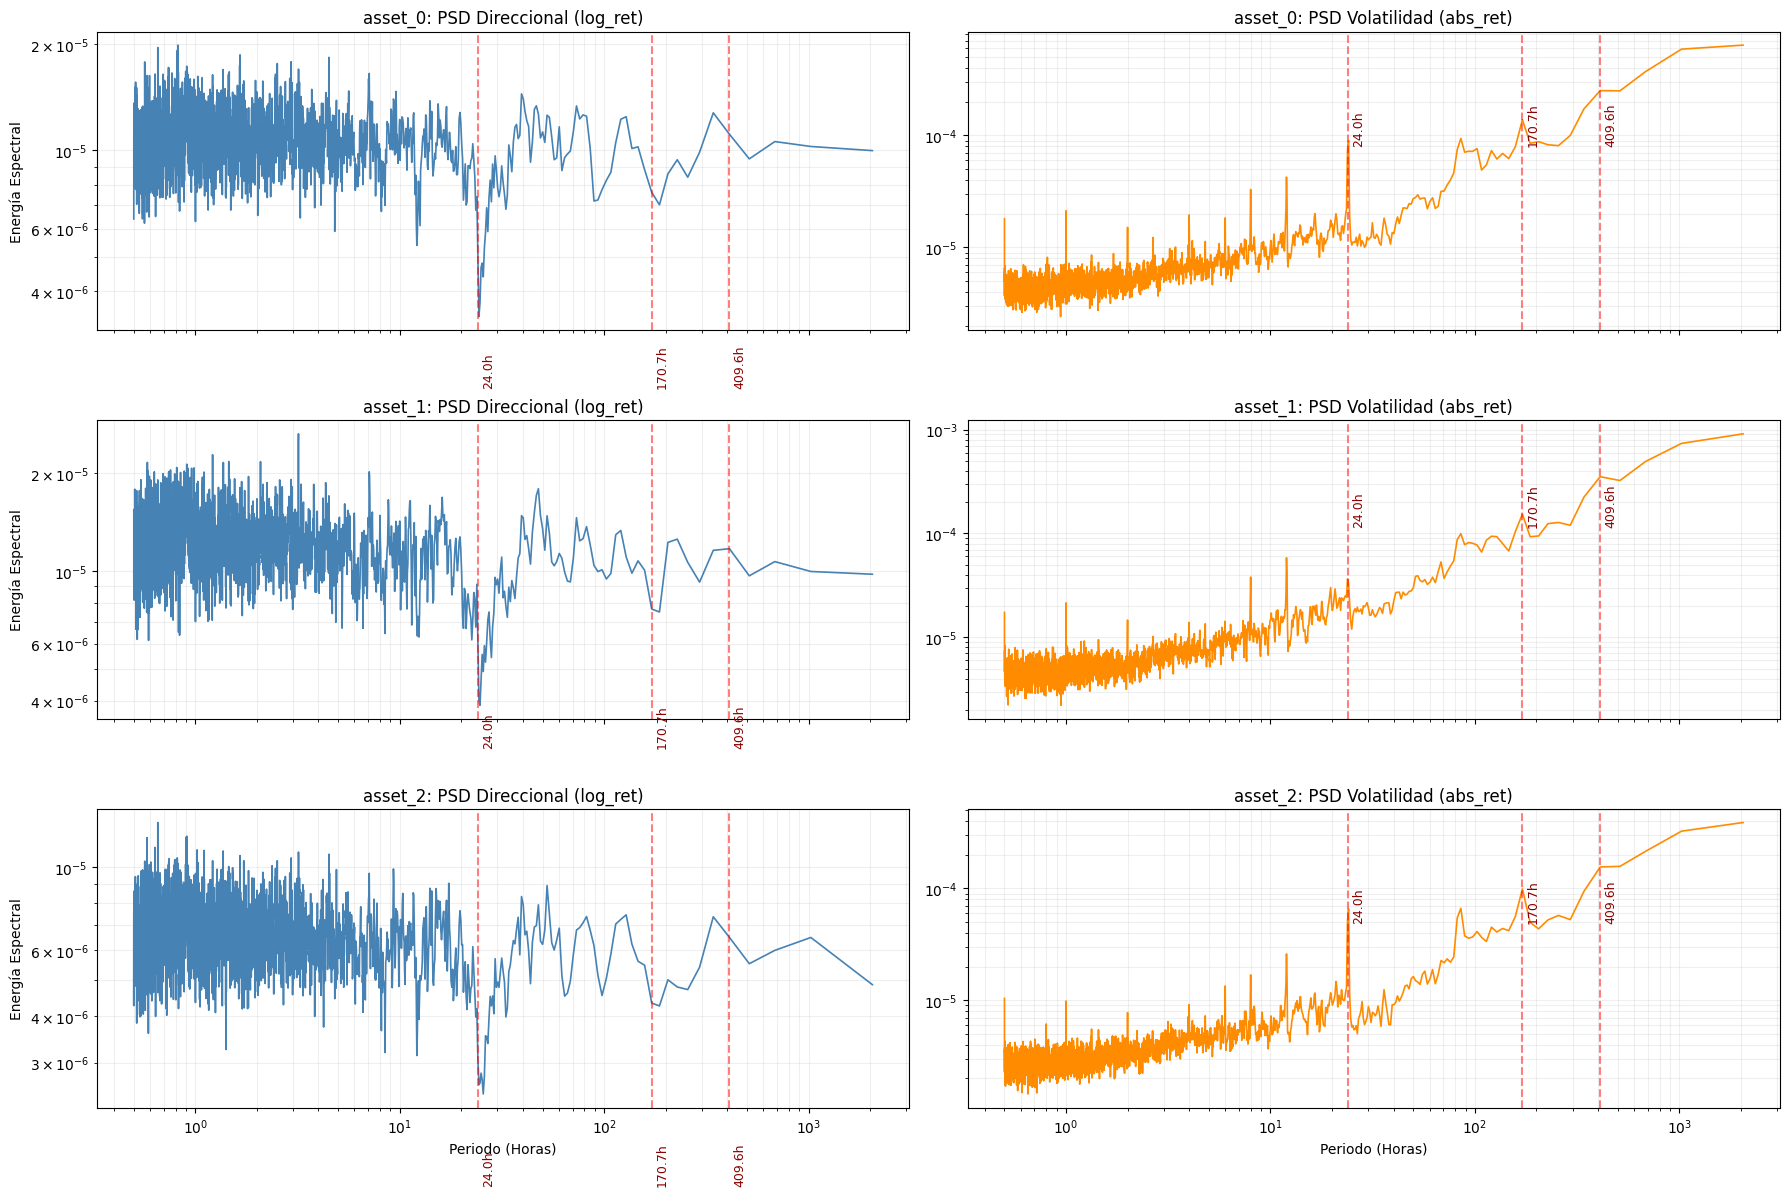

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from typing import Tuple, List

def compute_welch_spectrum(
    series: pd.Series, 
    fs_samples_per_hour: float = 4.0, 
    window_length: int = 8192
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calcula el espectro de frecuencias usando el método de Welch.
    Centra la señal para suprimir la frecuencia cero (DC component).
    """
    signal_array = series.dropna().values
    centered_signal = signal_array - np.mean(signal_array)
    
    freqs, psd = signal.welch(
        centered_signal, 
        fs=fs_samples_per_hour, 
        nperseg=window_length
    )
    
    # Supresión del índice 0 para evitar divisiones indefinidas en periodos
    valid_mask = freqs > 0
    periods_hours = 1.0 / freqs[valid_mask]
    psd_valid = psd[valid_mask]
    
    return periods_hours, psd_valid

def plot_dual_spectrum(data: pd.DataFrame, assets: List[str]) -> None:
    """
    Genera la comparativa espectral entre retornos direccionales y absolutos.
    """
    fig, axes = plt.subplots(len(assets), 2, figsize=(18, 12), sharex=True)
    
    # Frecuencias de referencia empírica (Horas)
    reference_cycles = [24.0, 170.7, 409.6]
    
    for i, asset in enumerate(assets):
        # Construcción de las series objetivo
        close_price = data[f'{asset}_close']
        log_ret = np.log(close_price / close_price.shift(1)).dropna()
        abs_ret = log_ret.abs()
        
        # Cálculo espectral independiente
        periods_dir, psd_dir = compute_welch_spectrum(log_ret)
        periods_vol, psd_vol = compute_welch_spectrum(abs_ret)
        
        # Gráfico 1: Señal Direccional (log_ret)
        ax_dir = axes[i, 0]
        ax_dir.loglog(periods_dir, psd_dir, color='steelblue', linewidth=1.2)
        ax_dir.set_title(f'{asset}: PSD Direccional (log_ret)')
        ax_dir.set_ylabel('Energía Espectral')
        
        # Gráfico 2: Señal de Magnitud (abs_ret)
        ax_vol = axes[i, 1]
        ax_vol.loglog(periods_vol, psd_vol, color='darkorange', linewidth=1.2)
        ax_vol.set_title(f'{asset}: PSD Volatilidad (abs_ret)')
        
        # Anotación de referencias estructurales en ambos dominios
        for ax in [ax_dir, ax_vol]:
            ax.grid(True, which="both", ls="-", alpha=0.2)
            for ref in reference_cycles:
                ax.axvline(ref, color='red', linestyle='--', alpha=0.5)
                ax.text(ref * 1.05, ax.get_ylim()[1] * 0.1, f'{ref:.1f}h', 
                        rotation=90, color='darkred', fontsize=9)
            if i == len(assets) - 1:
                ax.set_xlabel('Periodo (Horas)')

    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN DEL ANÁLISIS
# =============================================================================
# Asumiendo que el DataFrame `data` contiene la resolución nativa de 15m
assets_target = ['asset_0', 'asset_1', 'asset_2']
plot_dual_spectrum(data, assets_target)

In [39]:
import numpy as np
import pandas as pd
from scipy import signal

def extract_top_frequencies(
    series: pd.Series, 
    fs_samples_per_hour: float = 4.0, 
    window_length: int = 8192,
    top_n: int = 20
) -> pd.DataFrame:
    """
    Calcula el PSD y extrae los periodos dominantes numéricamente
    utilizando análisis topológico de picos (prominencia).
    """
    signal_array = series.dropna().values
    centered_signal = signal_array - np.mean(signal_array)
    
    freqs, psd = signal.welch(
        centered_signal, 
        fs=fs_samples_per_hour, 
        nperseg=window_length
    )
    
    # Ignorar la frecuencia 0
    valid_mask = freqs > 0
    freqs = freqs[valid_mask]
    psd = psd[valid_mask]
    
    # Encontrar picos topológicos (ignorando ruido local)
    # distance=4 asegura que no detectemos picos pegados por artefactos
    peaks, properties = signal.find_peaks(psd, prominence=np.percentile(psd, 95), distance=4)
    
    if len(peaks) == 0:
        return pd.DataFrame(columns=['Periodo_Horas', 'Poder_PSD'])
    
    # Mapear índices a frecuencias y periodos
    peak_freqs = freqs[peaks]
    peak_periods_hours = 1.0 / peak_freqs
    peak_powers = psd[peaks]
    
    # Construir tabla y ordenar por el poder de la señal
    results = pd.DataFrame({
        'Periodo_Horas': peak_periods_hours,
        'Poder_PSD': peak_powers
    }).sort_values(by='Poder_PSD', ascending=False).head(top_n).reset_index(drop=True)
    
    return results

# =============================================================================
# EJECUCIÓN DEL EXTRACTOR NUMÉRICO
# =============================================================================
print("="*60)
print("EXTRACCIÓN DE CICLOS RESONANTES: VOLATILIDAD (abs_ret)")
print("="*60)

for asset in assets: # Asumiendo assets = ['asset_0', 'asset_1', 'asset_2']
    close_price = data[f'{asset}_close']
    log_ret = np.log(close_price / close_price.shift(1)).dropna()
    abs_ret = log_ret.abs()
    
    top_cycles = extract_top_frequencies(abs_ret)
    
    print(f"\n{asset.upper()} - Top {len(top_cycles)} Ciclos de Riesgo:")
    # Formateamos la salida para lectura técnica
    for idx, row in top_cycles.iterrows():
        print(f"  {idx+1}. Ciclo: {row['Periodo_Horas']:>8.2f}h  |  Energía (PSD): {row['Poder_PSD']:.2e}")

EXTRACCIÓN DE CICLOS RESONANTES: VOLATILIDAD (abs_ret)

ASSET_0 - Top 10 Ciclos de Riesgo:
  1. Ciclo:   170.67h  |  Energía (PSD): 1.38e-04
  2. Ciclo:    85.33h  |  Energía (PSD): 9.40e-05
  3. Ciclo:    24.09h  |  Energía (PSD): 8.95e-05
  4. Ciclo:    11.98h  |  Energía (PSD): 4.24e-05
  5. Ciclo:     8.00h  |  Energía (PSD): 3.29e-05
  6. Ciclo:     1.00h  |  Energía (PSD): 2.12e-05
  7. Ciclo:    16.52h  |  Energía (PSD): 2.00e-05
  8. Ciclo:     4.00h  |  Energía (PSD): 1.95e-05
  9. Ciclo:     6.01h  |  Energía (PSD): 1.83e-05
  10. Ciclo:     2.00h  |  Energía (PSD): 1.51e-05

ASSET_1 - Top 9 Ciclos de Riesgo:
  1. Ciclo:   409.60h  |  Energía (PSD): 3.52e-04
  2. Ciclo:   170.67h  |  Energía (PSD): 1.54e-04
  3. Ciclo:    85.33h  |  Energía (PSD): 9.95e-05
  4. Ciclo:   120.47h  |  Energía (PSD): 9.40e-05
  5. Ciclo:    11.98h  |  Energía (PSD): 5.83e-05
  6. Ciclo:    68.27h  |  Energía (PSD): 5.33e-05
  7. Ciclo:     8.00h  |  Energía (PSD): 3.80e-05
  8. Ciclo:    23.81h  

## **REPORTE DE ANÁLISIS EXPLORATORIO: DENSIDAD ESPECTRAL DE POTENCIA (PSD) Y CICLOS RESONANTES**

**1. Disociación Estructural en el Dominio de la Frecuencia**

* **El cráter direccional:** La inspección visual del dominio direccional (`log_ret`, gráficos de la izquierda) muestra una distribución de energía correspondiente al ruido estocástico, sin picos ascendentes. La única firma estructural es una caída abrupta (cráter) exactamente en la coordenada de 24.0h. Esto indica empíricamente que los algoritmos de reversión y el arbitraje destruyen activamente cualquier inercia direccional en el ciclo diario; el mercado "borra" la señal direccional cada 24 horas.
* **Resonancia de la varianza:** En contraposición ortogonal, el dominio de la magnitud (`abs_ret`, gráficos de la derecha) exhibe picos de energía resonante que rompen el ruido de fondo, acompañados de una pendiente ascendente hacia las bajas frecuencias. Esto confirma visual y matemáticamente que la volatilidad posee memoria a largo plazo y obedece a un reloj mecánico latente.

**2. Jerarquía de Regímenes de Riesgo (Extracción Numérica)**
La tabulación de los picos de densidad espectral revela que la turbulencia del ecosistema está gobernada por tres regímenes temporales estrictos, presentes de forma casi idéntica en los tres activos:

* **Régimen Macro (El ancla estructural):** El ciclo de **170.67h** (aproximadamente 7.1 días) es la fuerza tractora principal del ecosistema, ocupando el puesto #1 en energía para `asset_0` y `asset_2`, y el #2 para `asset_1`. Adicionalmente, el `asset_1` expone un régimen aún más masivo en **409.60h** (~17 días). Estas frecuencias dominan la inercia del mercado.
* **Régimen Meso (El armónico de mitad de semana):** El periodo de **85.33h** (aproximadamente 3.5 días) aparece uniformemente en el Top 3 de los tres instrumentos. Representa una subdivisión matemática exacta del ciclo semanal (170.67 / 2), marcando ritmos mecánicos de rebalanceo o inyecciones de liquidez a mitad de la jornada semanal.
* **Régimen Micro (La microestructura civil):** El análisis detecta con precisión de relojería los ciclos de **24.09h**, **11.98h**, **8.00h**, **4.00h**, **2.00h** y **1.00h**. Estos son los armónicos exactos de la rotación diaria de la Tierra y las sesiones operativas globales (dividiendo 24h en intervalos de 12h, 8h, 4h, etc.). Reflejan el comportamiento algorítmico institucional anclado al reloj civil.

**Sugerencias Analíticas y de Modelamiento**

1. **Parametrización del Reloj Espectral:** La coincidencia exacta de estas frecuencias en todo el ecosistema proporciona las coordenadas definitivas para el espacio de estados. La función de ingeniería de características debe incorporar transformaciones sinusoidales y cosenoidales (`build_fourier_coordinates_15m`) codificadas rígidamente en las frecuencias dominantes descubiertas: **171h**, **85h** y **24h**. Esto dotará a la red neuronal de un contexto de fase continuo sin incurrir en dimensionalidad innecesaria.
2. **Exclusión de Expectativas Direccionales:** La presencia del "cráter" a las 24 horas en el gráfico direccional advierte sobre la futilidad de intentar capturar tendencias de ciclo diario. El agente PPO no debe ser diseñado para anticipar rebotes direccionales basados en el reloj, sino para calibrar su exposición frente a las expansiones paramétricas de varianza que ocurren inexorablemente cada 12h, 24h y 85h.
3. **Justificación de la Dilatación Temporal:** La masiva concentración de energía en los ciclos de 170.7h y 409.6h justifica matemáticamente el uso del muestreo dilatado para el Transformer. Si el tensor de entrada solo abarcara las últimas 24 horas (microestructura), el agente sería estructuralmente ciego a las dos fuerzas físicas de mayor impacto (Poder PSD) que gobiernan el mercado.

In [25]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

def granger_test_pair_15m(x: pd.Series, y: pd.Series, max_lag_hours: int = 6) -> pd.DataFrame:
    """
    Test de Granger ajustado a resolución de 15 minutos.
    Retorna el estadístico F y el valor p para todos los retardos hasta max_lag_hours.
    """
    max_lag_bars = int(max_lag_hours * 4)
    df = pd.DataFrame({'y': y, 'x': x}).dropna()
    
    # statsmodels evalúa iterativamente desde lag 1 hasta maxlag
    result = grangercausalitytests(df[['y', 'x']], maxlag=max_lag_bars, verbose=False)
    
    rows = []
    for lag in range(1, max_lag_bars + 1):
        f_stat = result[lag][0]['ssr_ftest'][0]
        p_value = result[lag][0]['ssr_ftest'][1]
        rows.append({
            'lag_bars': lag, 
            'lag_hours': lag / 4.0, 
            'F_stat': f_stat, 
            'p_value': p_value
        })
        
    return pd.DataFrame(rows)

def print_granger_summary(data: pd.DataFrame, target_lags: list[int], title: str) -> None:
    """
    Imprime un reporte auditable extrayendo retardos específicos, 
    evitando el sesgo de selección del valor mínimo.
    """
    direction_pairs = [
        ('asset_1', 'asset_0'), ('asset_0', 'asset_1'),
        ('asset_1', 'asset_2'), ('asset_2', 'asset_1'),
        ('asset_0', 'asset_2'), ('asset_2', 'asset_0'),
    ]
    
    print(f"\n{title}")
    print(f"{'X causa Y':<22} {'Retardo(15m)':>12} {'Horas':>8} {'F_stat':>10} {'p_value':>10} {'Sig?':>6}")
    print("-" * 74)
    
    for x_name, y_name in direction_pairs:
        # Evaluamos hasta 6 horas de profundidad
        result = granger_test_pair_15m(data[x_name], data[y_name], max_lag_hours=6)
        
        for target_lag in target_lags:
            row = result[result['lag_bars'] == target_lag].iloc[0]
            
            # Asignación estricta de significancia
            sig = "***" if row['p_value'] < 0.001 else \
                  ("**" if row['p_value'] < 0.01 else \
                  ("*" if row['p_value'] < 0.05 else ""))
                  
            print(f"{x_name} → {y_name:<12} {int(row['lag_bars']):>12} "
                  f"{row['lag_hours']:>8.2f} {row['F_stat']:>10.3f} {row['p_value']:>10.4f} {sig:>6}")
        print("- " * 37)

# =============================================================================
# EJECUCIÓN
# =============================================================================
# Seleccionamos fronteras de análisis explícitas: 15m, 1h, 4h y 6h
horizontes_objetivo = [1, 4, 16, 24]

# 1. Test sobre la Señal Direccional Cruda
print_granger_summary(
    data=log_rets, 
    target_lags=horizontes_objetivo, 
    title="Test de Granger: Retornos Direccionales (log_ret)"
)

# 2. Test sobre la Señal de Magnitud (Riesgo / Información)
abs_rets = log_rets.abs()
print_granger_summary(
    data=abs_rets, 
    target_lags=horizontes_objetivo, 
    title="Test de Granger: Magnitud de Volatilidad (|log_ret|)"
)


Test de Granger: Retornos Direccionales (log_ret)
X causa Y              Retardo(15m)    Horas     F_stat    p_value   Sig?
--------------------------------------------------------------------------
asset_1 → asset_0                 1     0.25     27.465     0.0000    ***
asset_1 → asset_0                 4     1.00     14.330     0.0000    ***
asset_1 → asset_0                16     4.00      9.983     0.0000    ***
asset_1 → asset_0                24     6.00      7.128     0.0000    ***
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
asset_0 → asset_1                 1     0.25    199.424     0.0000    ***
asset_0 → asset_1                 4     1.00     55.255     0.0000    ***
asset_0 → asset_1                16     4.00     18.857     0.0000    ***
asset_0 → asset_1                24     6.00     14.598     0.0000    ***
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
asset_1 → asset_2                 1     0.25     69.286   

## **REPORTE DE ANÁLISIS EXPLORATORIO: CAUSALIDAD DE GRANGER Y CONTAGIO DE RIESGO**

**1. Dinámica de Contagio Direccional**

* **Significancia unánime:** El test revela que, a pesar de que los retornos individuales carecen de autocorrelación lineal (como se vio en el análisis previo), existe una causalidad direccional cruzada altamente significativa ($p < 0.001$) entre todos los pares de activos del ecosistema.
* **El centro de gravedad direccional:** Al analizar la magnitud del estadístico F, `asset_0` emerge como el principal motor direccional del mercado. En el retardo inmediato (15 minutos), el vector `asset_0 → asset_1` alcanza un $F=199.42$, superando aplastantemente al vector inverso `asset_1 → asset_0` ($F=27.46$). Esta jerarquía asimétrica se repite en su interacción con `asset_2`. Si `asset_0` ejecuta un movimiento direccional abrupto, el resto del mercado se ve forzado a corregir y seguirlo en el siguiente cuarto de hora.
* **Decaimiento de la influencia:** La causalidad direccional es aguda pero efímera. Aunque los p-values se mantienen significativos a 6 horas de distancia (lag 24), los valores del estadístico F colapsan drásticamente (cayendo de promedios de ~150 a ~10). El "latigazo" direccional es absorbido rápidamente por el ecosistema.

**2. Transmisión Estructural de Volatilidad (Riesgo de Cola)**

* **Magnitudes extremas de contagio:** La aplicación del test sobre la volatilidad absoluta (`|log_ret|`) expone un nivel de causalidad estructural exponencialmente mayor que el direccional. Los estadísticos F alcanzan valores masivos en el primer retardo de 15 minutos (ej. `asset_1 → asset_0` con un colosal $F=3096.83$).
* **Inversión de la Jerarquía de Liderazgo:** A diferencia de la señal direccional donde `asset_0` era el líder, en el dominio de la volatilidad, **`asset_1` es el vector de contagio dominante**. La turbulencia en `asset_1` predice la turbulencia en `asset_0` ($F=3096.83$) y `asset_2` ($F=2608.30$) con una fuerza hasta cuatro veces mayor que en sentido inverso. `asset_1` actúa como el epicentro sísmico del ecosistema; cuando este activo pierde liquidez o sufre expansión de varianza, el riesgo de cola se transfiere de inmediato a todo el portafolio.
* **Persistencia del contagio de riesgo:** Al igual que en la autocorrelación, la causalidad de la volatilidad decae mucho más lento que la direccional. A las 6 horas (lag 24), los estadísticos F de la volatilidad siguen triplicando o cuadruplicando la fuerza de los direccionales.

**Sugerencias Analíticas y de Modelamiento**

1. **Diseño Multivariado Obligatorio:** La magnitud abrumadora de los estadísticos F en el dominio de la volatilidad cruzada advierte contra el modelado de activos en silos aislados. Para anticipar el comportamiento de un instrumento, el tensor de estado debe ser multivariado, exponiendo la matriz completa de correlaciones e interdependencias en cada paso temporal.
2. **Jerarquía en la Auto-Atención:** La asimetría en el liderazgo (donde `asset_1` domina la varianza y `asset_0` domina la dirección) sugiere un comportamiento esperable para la capa de atención del Transformer. Un modelo bien calibrado debería aprender a asignar mayores pesos de atención cruzada hacia el historial reciente de `asset_1` durante regímenes de alta curtosis, utilizándolo como un indicador temprano del colapso de liquidez sistémico.
3. **Explotación Bidireccional del Riesgo (Shorting):** La fuerte latencia de arbitraje revelada por Granger (15m de ventana de contagio) y la posibilidad de operar posiciones cortas abren vectores asimétricos de rentabilidad. Si `asset_1` experimenta un choque de volatilidad masivo, el agente dispone del contexto predictivo para adoptar posiciones cortas en los activos rezagados (`asset_0` y `asset_2`) antes de que el contagio colapse sus precios, o bien pivotar hacia el efectivo (cash) para evitar el arrastre de la varianza.

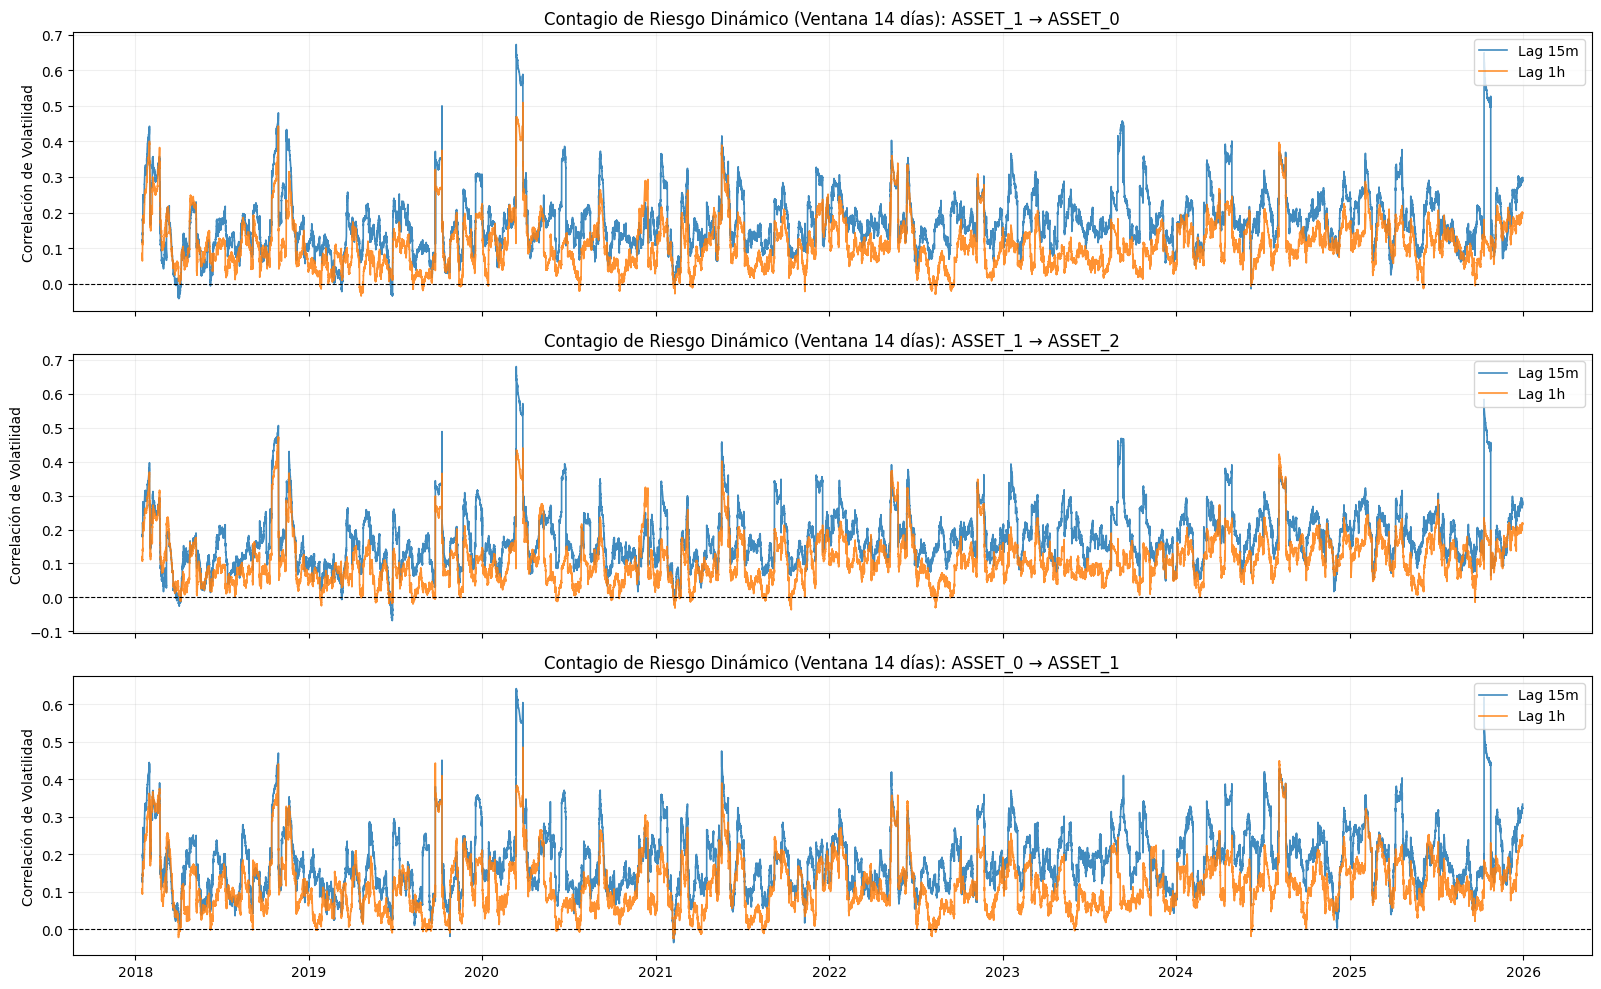

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def rolling_cross_corr(x: pd.Series, y: pd.Series, lag: int, window: int) -> pd.Series:
    """
    Correlación entre x(t) e y(t+lag) sobre una ventana móvil.
    Un lag > 0 indica que x lidera a y.
    """
    if lag > 0:
        return x.rolling(window).corr(y.shift(-lag))
    else:
        return x.shift(lag).rolling(window).corr(y)

# Definimos los vectores de contagio más fuertes identificados por Granger
contagion_vectors = [
    ('asset_1', 'asset_0'),  # El epicentro al líder direccional
    ('asset_1', 'asset_2'),  # El epicentro al activo de mayor curtosis
    ('asset_0', 'asset_1')   # El ciclo inverso de retroalimentación
]

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Ventana de 2 semanas para capturar el régimen macro sin sobre-suavizar
# 14 días * 24 horas * 4 barras_por_hora = 1344 barras
WINDOW_BARS = 1344 
key_lags = [1, 4]  # lag 1 = 15m (inmediato), lag 4 = 1h (propagación)

for ax, (x_name, y_name) in zip(axes, contagion_vectors):
    for lag in key_lags:
        # Calculamos sobre la magnitud absoluta (riesgo)
        rc = rolling_cross_corr(
            log_rets[x_name].abs(), 
            log_rets[y_name].abs(), 
            lag=lag, 
            window=WINDOW_BARS
        )
        
        label_str = f"Lag {lag*15}m" if lag < 4 else f"Lag {lag/4:.0f}h"
        ax.plot(rc.index, rc.values, label=label_str, linewidth=1.2, alpha=0.85)
        
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Contagio de Riesgo Dinámico (Ventana 14 días): {x_name.upper()} → {y_name.upper()}')
    ax.set_ylabel('Correlación de Volatilidad')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## **REPORTE DE ANÁLISIS EXPLORATORIO: NO ESTACIONARIEDAD Y CAMBIO DE RÉGIMEN**

**1. Mutabilidad del Contagio de Riesgo (No-Estacionariedad)**

* **Inestabilidad Estructural:** La evaluación rodante de la correlación cruzada de volatilidad refuta la noción de un ecosistema estático. A lo largo de los 8 años de histórico (2018-2026), la fuerza del contagio fluctúa violentamente. El ecosistema transita entre fases de acoplamiento profundo (donde la correlación de riesgo supera el +0.60, indicando pánico sistémico) y regímenes prolongados de desacoplamiento (donde la correlación cae hacia el +0.05, indicando que los activos absorben turbulencia de forma aislada).
* **Ausencia de Refugio Interno:** Es crítico notar que la curva navega casi exclusivamente en territorio positivo a lo largo de toda la década. Esto certifica que, sin importar el régimen macroeconómico, la volatilidad cruzada no actúa como un amortiguador divergente. Un activo nunca absorbe la turbulencia de otro pacificándolo (correlación negativa sostenida); o se contagian mutuamente la inestabilidad, o actúan en silos.

**2. Asimetría de la Latencia de Contagio (Lag 15m vs Lag 1h)**

* **El dominio de la microestructura:** En los tres vectores analizados, la línea azul (Lag 15m) se sitúa sistemáticamente por encima de la línea naranja (Lag 1h) en los momentos de estrés del mercado (picos de correlación). Esto demuestra empíricamente que la latencia del arbitraje de riesgo es extremadamente rápida.
* **Evaporación del Alpha:** Cuando `asset_1` sufre un choque de volatilidad, la onda expansiva golpea a `asset_0` y `asset_2` con máxima intensidad en los primeros 15 minutos. Si el agente evalúa la situación y reacciona una hora más tarde (línea naranja), la fuerza predictiva del contagio ya se ha disipado casi a la mitad.

**3. Justificación de la Arquitectura Adaptativa**

* **Fallo de la Heurística Lineal:** La inestabilidad histórica de estas métricas demuestra la inviabilidad de aplicar reglas estáticas. Una estrategia calibrada para operar cortos (explotando la alta correlación del pico de inicios de 2020) destruirá la rentabilidad por sobreoperación durante los largos "valles" de desacoplamiento observados entre 2022 y 2023.
* **El Rol del Agente:** Queda justificado que el modelo no puede operar basándose en la correlación promedio de Granger. El agente (y su codificador de representación) necesita la capacidad de re-calcular la matriz de correlación local en tiempo real para discernir si el mercado actual se encuentra en una fase de acoplamiento (donde los *shorts* por contagio son efectivos) o de desacoplamiento (donde el contagio de riesgo es ruido).

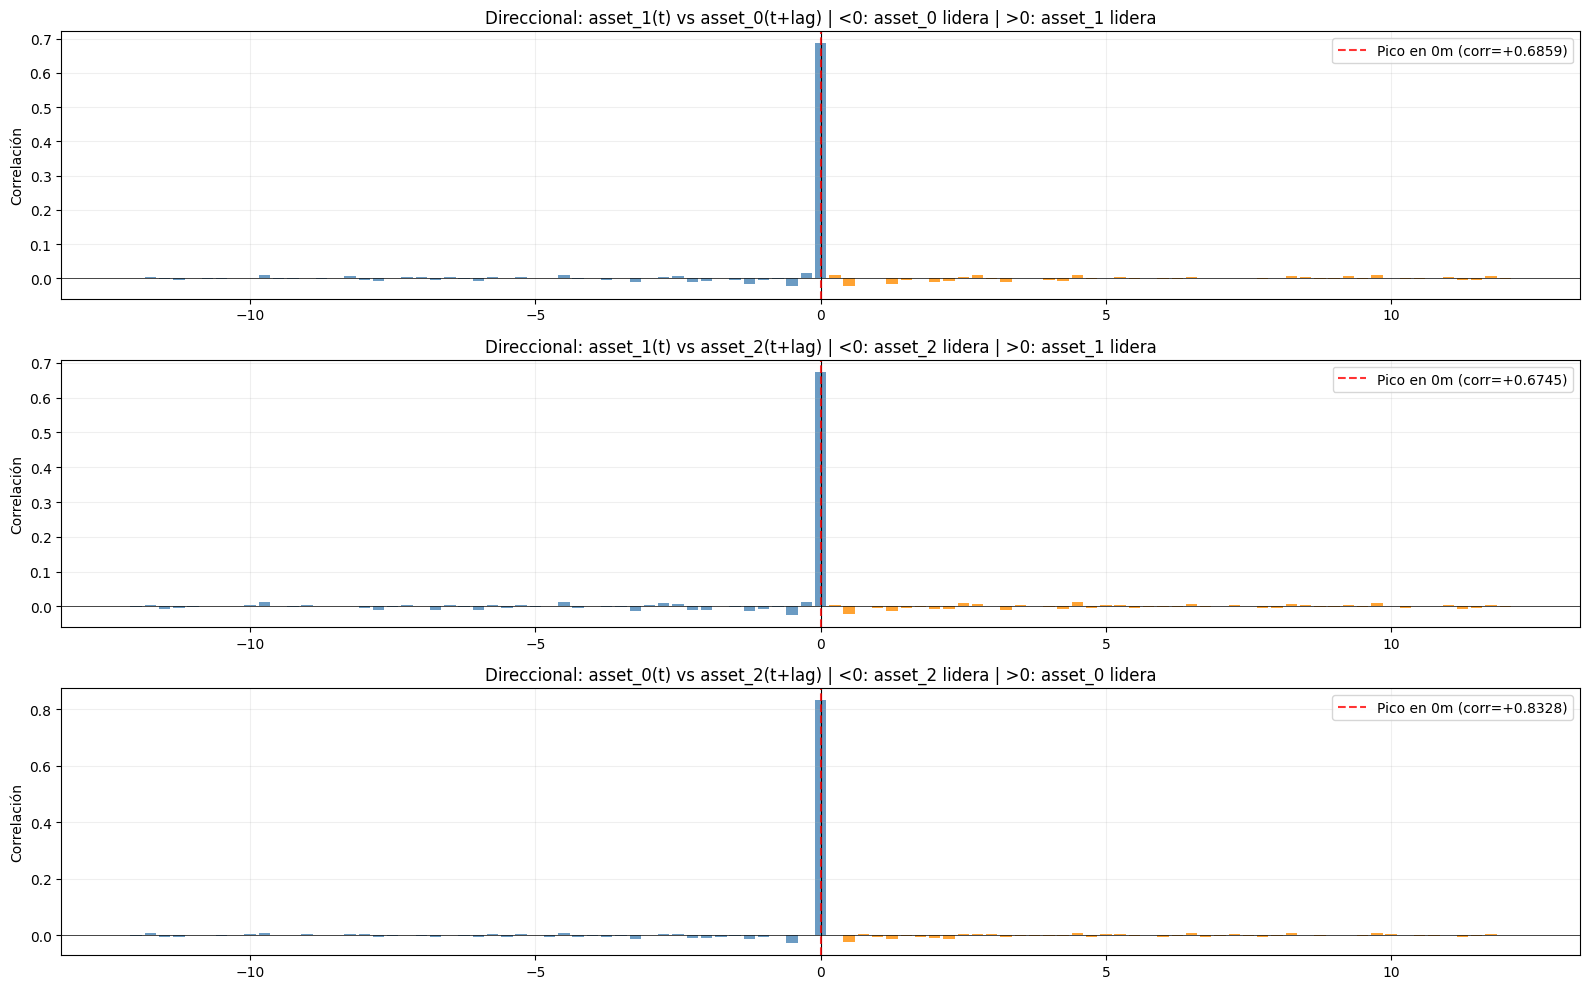

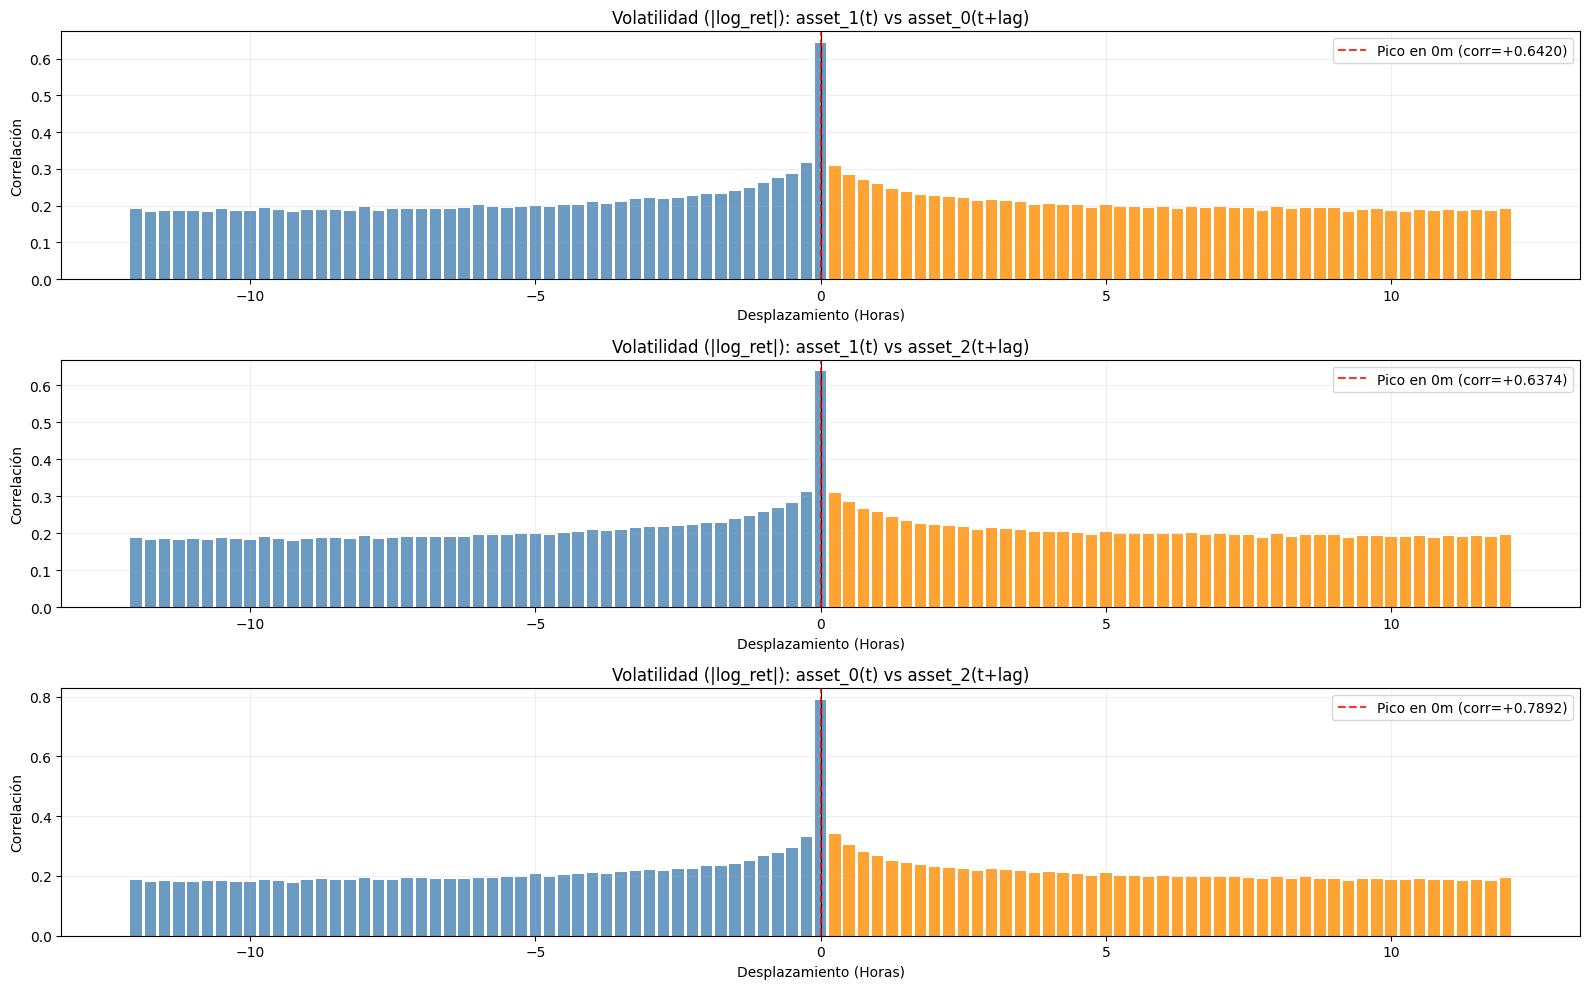

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cross_correlation_at_lags(x: pd.Series, y: pd.Series, lags: range) -> pd.Series:
    """
    Calcula corr(x(t), y(t+lag)) para cada lag.
    """
    correlations = {}
    for lag in lags:
        if lag >= 0:
            common = pd.DataFrame({'x': x, 'y': y.shift(-lag)}).dropna()
        else:
            common = pd.DataFrame({'x': x.shift(lag), 'y': y}).dropna()
            
        if len(common) > 100:
            correlations[lag] = common['x'].corr(common['y'])
    return pd.Series(correlations).sort_index()

# ════════ Configuración de Resolución 15m ════════
# Evaluaremos +/- 48 barras (es decir, +/- 12 horas)
lags_15m = range(-48, 49) 
pairs = [('asset_1', 'asset_0'), ('asset_1', 'asset_2'), ('asset_0', 'asset_2')]

# 1. Lead-lag sobre Retornos Direccionales (log_ret)
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
for ax, (x_name, y_name) in zip(axes, pairs):
    corrs = cross_correlation_at_lags(log_rets[x_name], log_rets[y_name], lags_15m)
    
    colors = ['steelblue' if k <= 0 else 'darkorange' for k in corrs.index]
    # Dibujamos las barras pero ajustamos el eje X para que muestre horas reales (lag / 4)
    ax.bar(corrs.index / 4, corrs.values, width=0.2, color=colors, alpha=0.8)
    
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axhline(0, color='black', linewidth=0.5)
    
    peak_lag = corrs.abs().idxmax()
    peak_val = corrs.loc[peak_lag]
    ax.axvline(peak_lag / 4, color='red', linestyle='--', alpha=0.8,
               label=f'Pico en {peak_lag*15}m (corr={peak_val:+.4f})')
    
    ax.set_title(f'Direccional: {x_name}(t) vs {y_name}(t+lag) | <0: {y_name} lidera | >0: {x_name} lidera')
    ax.set_ylabel('Correlación')
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 2. Lead-lag sobre Volatilidad (|log_ret|)
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
for ax, (x_name, y_name) in zip(axes, pairs):
    corrs = cross_correlation_at_lags(log_rets[x_name].abs(), log_rets[y_name].abs(), lags_15m)
    
    colors = ['steelblue' if k <= 0 else 'darkorange' for k in corrs.index]
    ax.bar(corrs.index / 4, corrs.values, width=0.2, color=colors, alpha=0.8)
    
    ax.axvline(0, color='black', linewidth=0.8)
    
    peak_lag = corrs.abs().idxmax()
    peak_val = corrs.loc[peak_lag]
    ax.axvline(peak_lag / 4, color='red', linestyle='--', alpha=0.8,
               label=f'Pico en {peak_lag*15}m (corr={peak_val:+.4f})')
    
    ax.set_title(f'Volatilidad (|log_ret|): {x_name}(t) vs {y_name}(t+lag)')
    ax.set_xlabel('Desplazamiento (Horas)')
    ax.set_ylabel('Correlación')
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## **REPORTE DE ANÁLISIS EXPLORATORIO: SINCRONICIDAD Y LATENCIA DE CONTAGIO (LEAD-LAG)**

**1. Colapso Direccional (Eficiencia Contemporánea)**

* **Sincronicidad absoluta:** El análisis direccional (`log_ret`, primer panel) expone un pico de correlación estructuralmente masivo (entre +0.6745 y +0.8328) anclado de forma exclusiva en el retardo cero (`lag 0`).
* **Ausencia de inercia operable:** Inmediatamente fuera de esa ventana contemporánea, la correlación cae en vertical hacia el ruido estocástico, tanto en los retardos positivos como negativos. Esto desarticula cualquier hipótesis de *momentum* direccional cruzado de baja latencia. Si un activo experimenta un impulso alcista o bajista, los algoritmos de alta frecuencia del ecosistema asimilan y replican ese flujo dentro de la misma vela de 15 minutos.
* **El límite físico del motor:** Dado que el entorno de simulación evalúa el estado en el instante $t$ para ejecutar la orden en $t+1$, intentar capturar estas anomalías direccionales garantiza operar sobre datos caducos. Para cuando el agente intente sumarse a la tendencia cruzada, el movimiento ya habrá sido arbitrado y absorbido por el mercado.

**2. Estructura del Contagio de Volatilidad (Efecto Derrame)**

* **La huella del riesgo continuo:** El dominio de la magnitud de la volatilidad (`|log_ret|`, segundo panel) presenta una topología radicalmente distinta. Aunque el acoplamiento máximo permanece en el instante cero, está flanqueado por "hombros" de correlación muy densos y persistentes (oscilando en una banda de +0.20 a +0.35) que decaen con extrema lentitud a lo largo de toda la ventana de $\pm 12$ horas.
* **Simetría de la turbulencia:** Esta memoria no solo es prolongada, sino estructuralmente simétrica. Un choque de liquidez en un activo particular altera el régimen del ecosistema completo, elevando la probabilidad de turbulencia paramétrica en los demás instrumentos durante las siguientes 48 velas consecutivas.

**3. Reconciliación Estadística y el Espejismo de Granger**

* Esta visualización explica las métricas extremas obtenidas en el Test de Granger. Los valores significativos de Granger en la dirección son, en la práctica, un artefacto matemático del colosal impacto en `lag 0` derramando ruido residual sobre el `lag 1`. Estadísticamente la señal existe, pero financieramente es inoperable debido al costo de transacción.
* En contraste, los estadísticos $F$ masivos observados en el test de volatilidad están plenamente validados empíricamente por los densos hombros del segundo panel. El riesgo posee inercia real, cuantificable y operable.

**Sugerencias Analíticas y de Modelamiento**

1. **Abandono del Arbitraje Direccional Retardado:** La política del agente (Actor) no debe estructurarse con la expectativa de perseguir la dirección de un activo líder. Las arquitecturas que intentan extraer *Alpha* direccional cruzado en frecuencias de 15 minutos sufren desgaste extremo por *whip-saw* y fricción de comisiones al reaccionar sistemáticamente tarde.
2. **Defensa Basada en Varianza Cruzada:** El diseño funcional debe centrarse en explotar el derrame de volatilidad. La lenta degradación temporal del riesgo confirma que el agente dispone de un margen operativo amplio (horas) para ajustar el tamaño de sus posiciones, rotar ponderaciones o migrar hacia el efectivo (*Cash*) tras detectar el estallido inicial de varianza, logrando blindar el portafolio antes de que la inercia del riesgo destruya el rendimiento acumulado.
3. **Transición hacia el Diseño de la Recompensa:** El cierre de la capa exploratoria define las reglas físicas del entorno. Un mercado sin memoria direccional pero con alta memoria de riesgo castiga los sistemas ingenuos de maximización de retornos. La etapa de modelado (Sección 4) debe plantear el problema como un experimento iterativo de control de riesgo. Formular una recompensa basada en un *Sharpe Ratio Diferencial* o penalizar activamente los *drawdowns* severos forzará a la red neuronal a interpretar estos picos de volatilidad cruzada como señales tempranas de repliegue, priorizando la supervivencia estructural antes que la extracción estocástica de retornos.

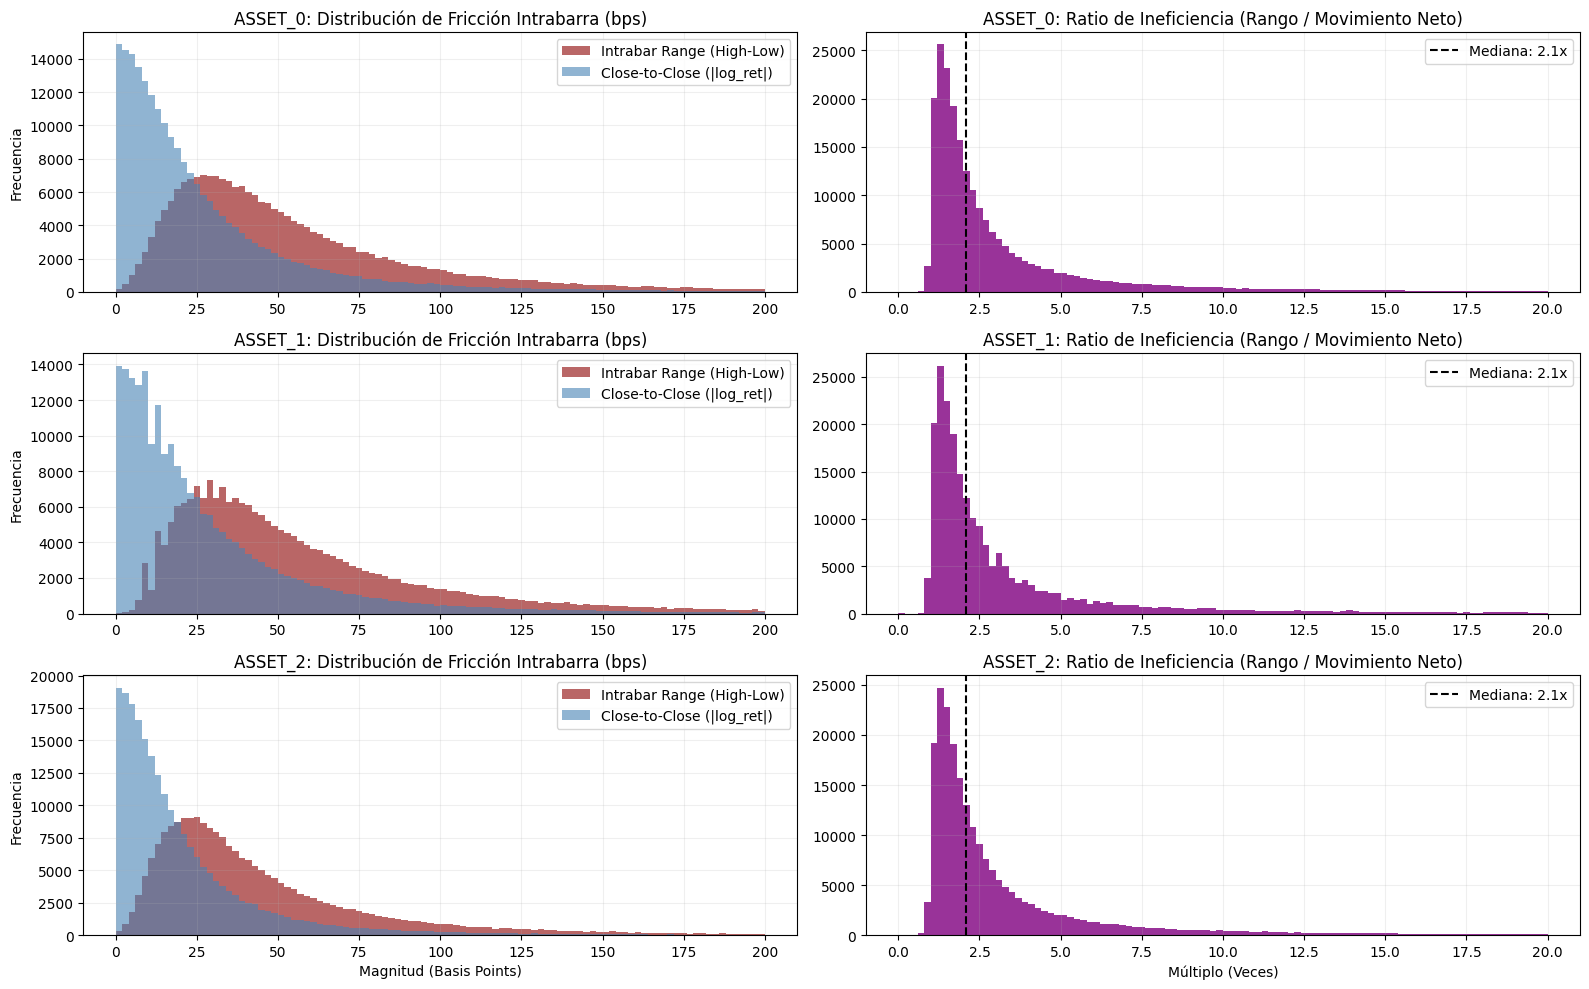

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_intrabar_range_bps(df: pd.DataFrame, asset: str) -> pd.Series:
    """
    Calcula la volatilidad máxima sufrida dentro de la vela (High - Low),
    normalizada respecto al cierre y expresada en basis points.
    """
    high = df[f'{asset}_high']
    low = df[f'{asset}_low']
    close = df[f'{asset}_close']
    
    # Rango porcentual convertido a bps
    intrabar_range = ((high - low) / close) * 10000
    return intrabar_range.dropna()

def plot_intrabar_friction(data: pd.DataFrame, assets: list[str]):
    """
    Compara la distribución del ruido intrabarra (High - Low) 
    frente a la volatilidad de cierre a cierre (|log_ret|).
    """
    fig, axes = plt.subplots(len(assets), 2, figsize=(16, 10))
    
    for i, asset in enumerate(assets):
        # 1. Rango Intrabarra (Fricción máxima)
        range_bps = compute_intrabar_range_bps(data, asset)
        
        # 2. Retorno Absoluto de Cierre a Cierre (Movimiento neto)
        close_price = data[f'{asset}_close']
        abs_ret_bps = np.abs(np.log(close_price / close_price.shift(1))) * 10000
        
        # Alineación de índices
        common_idx = range_bps.index.intersection(abs_ret_bps.index)
        range_bps = range_bps.loc[common_idx]
        abs_ret_bps = abs_ret_bps.loc[common_idx]
        
        # Panel Izquierdo: Histogramas de Densidad
        ax_dist = axes[i, 0]
        ax_dist.hist(range_bps, bins=100, range=(0, 200), alpha=0.6, color='darkred', label='Intrabar Range (High-Low)')
        ax_dist.hist(abs_ret_bps, bins=100, range=(0, 200), alpha=0.6, color='steelblue', label='Close-to-Close (|log_ret|)')
        ax_dist.set_title(f'{asset.upper()}: Distribución de Fricción Intrabarra (bps)')
        ax_dist.set_ylabel('Frecuencia')
        ax_dist.legend()
        ax_dist.grid(alpha=0.2)
        
        # Panel Derecho: Ratio de Ineficiencia (Rango / Retorno Neto)
        # Cuántas veces es más grande el viaje dentro de la vela que el destino final.
        # Sumamos 1 bp al denominador para evitar divisiones por cero o ruido extremo.
        inefficiency_ratio = range_bps / (abs_ret_bps + 1.0)
        
        ax_ratio = axes[i, 1]
        ax_ratio.hist(inefficiency_ratio, bins=100, range=(0, 20), alpha=0.8, color='purple')
        ax_ratio.set_title(f'{asset.upper()}: Ratio de Ineficiencia (Rango / Movimiento Neto)')
        ax_ratio.axvline(inefficiency_ratio.median(), color='black', linestyle='--', label=f'Mediana: {inefficiency_ratio.median():.1f}x')
        ax_ratio.legend()
        ax_ratio.grid(alpha=0.2)

    axes[-1, 0].set_xlabel('Magnitud (Basis Points)')
    axes[-1, 1].set_xlabel('Múltiplo (Veces)')
    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN FASE 1
# =============================================================================
assets_list = ['asset_0', 'asset_1', 'asset_2']
plot_intrabar_friction(data_train, assets_list) # Asumiendo que tu df principal se llama data_train

## **REPORTE DE ANÁLISIS EXPLORATORIO: MICROESTRUCTURA Y FRICCIÓN INTRABARRA**

**1. Disociación entre Trayectoria y Desplazamiento (La Ilusión del Cierre)**

* **Concentración estática aparente:** El panel izquierdo expone una divergencia estructural masiva en la representación de la serie de tiempo. La distribución del desplazamiento neto (`Close-to-Close`, en azul) exhibe una aglomeración asimétrica extrema hacia el cero absoluto. Si un agente de Reinforcement Learning evalúa el mercado basándose únicamente en esta métrica, percibirá un ecosistema altamente estacionario, asumiendo erróneamente que la ventana de 15 minutos se cierra consistentemente muy cerca de su nivel de apertura.
* **Turbulencia latente y barridos de liquidez:** La distribución del rango físico (`Intrabar Range`, en rojo) desmiente categóricamente la ilusión de inmovilidad. Su masa principal se desplaza de forma agresiva hacia la derecha, estableciendo un suelo de turbulencia operativa que orbita densamente entre los **25 y 50 puntos básicos (bps)**, con un decaimiento gradual que se extiende hacia umbrales superiores a los **150 bps**. Físicamente, esto demuestra que el mercado ejecuta barridos continuos de liquidez y expansiones de *spread* dentro de la vela. Una barra que estadísticamente parece no haber generado retorno direccional, en realidad consumió decenas de puntos básicos de liquidez profunda antes de regresar a su punto de equilibrio local.

**2. La Constante de Ineficiencia Sistémica**

* **El peaje estocástico del ecosistema:** El panel derecho cuantifica matemáticamente la fricción mediante el ratio entre el rango total recorrido y el movimiento direccional consolidado. El hallazgo más crítico es la uniformidad de la mediana: **exactamente 2.1x** de forma transversal para los tres activos. Esto no es una anomalía aislada, sino una propiedad mecánica intrínseca del mercado. Por cada punto básico de avance direccional real que el ecosistema logra consolidar, el precio se ve forzado a recorrer más del doble de esa distancia en fluctuaciones estocásticas internas.
* **Riesgo de cola extrema (Whip-saw paramétrico):** La asimetría de la cola derecha de esta distribución denota un nivel de riesgo intradiario severo. Una frecuencia operativamente significativa de observaciones transita en múltiplos de **5x, 10x e incluso 20x**. Estos regímenes representan ventanas temporales donde el activo experimenta latigazos bidireccionales extremos (whip-saws). Entrar a mercado o mantener posiciones altamente apalancadas durante estas ventanas implica absorber niveles de estrés estructural que pulverizan cualquier ventaja predictiva de corto plazo.

**3. Consecuencias Estructurales para el Modelado y el Entorno**

* **Erradicación del sesgo de supervivencia en el `TradingEnv`:** Este análisis invalida metodológicamente el diseño de entornos de simulación ingenuos que calculan *drawdowns* o topes de pérdida (stop-loss) utilizando únicamente el precio de cierre (`asset_close`). Un entorno así permitiría a un agente mantener una posición apalancada asumiendo que el mercado se movió solo **5 bps** en su contra al término del paso de tiempo, ignorando por completo que durante el transcurso de esos 15 minutos el precio ejecutó una excursión adversa de **120 bps**. En el despliegue real, esa fricción habría detonado liquidaciones forzosas. La función matemática de recompensa y riesgo debe incorporar el impacto adverso de `asset_high` y `asset_low` para evaluar la viabilidad de la supervivencia del agente.
* **Densidad de la matriz de observación:** Alimentar a la red neuronal exclusivamente con retornos logarítmicos condena al modelo a la ceguera frente a regímenes de ineficiencia y extracción de liquidez. El tensor de estado multidimensional debe integrar explícitamente el Rango Verdadero Normalizado. Esta adición dota a las capas de representación de la capacidad paramétrica para inferir cuándo el mercado transita por un régimen de fricción limpia (ratios cercanos a **1.0x**) frente a un entorno tóxico, obligando al agente a exigir una prima de convicción direccional mucho mayor antes de justificar el costo transaccional de rotar la cartera.

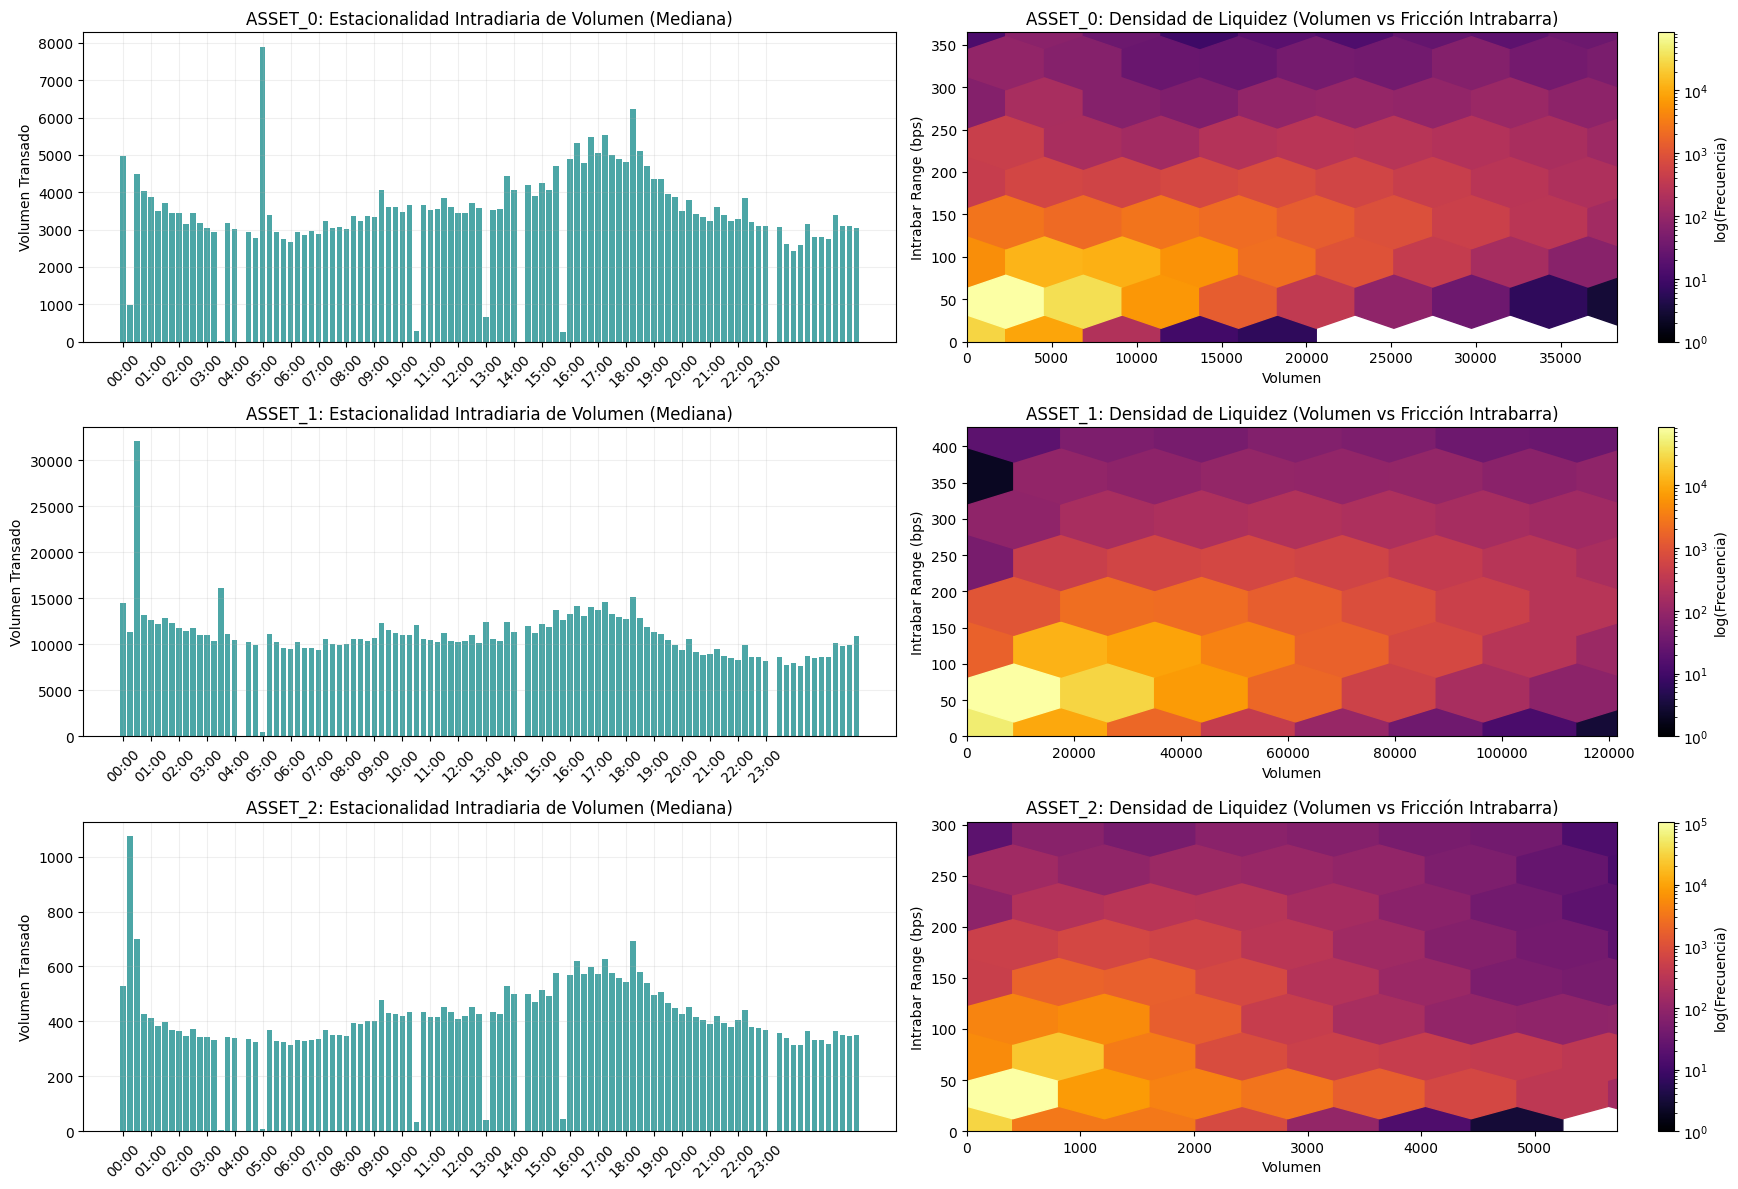

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_volume_and_liquidity(data: pd.DataFrame, assets: list[str]):
    fig, axes = plt.subplots(len(assets), 2, figsize=(18, 12))
    
    for i, asset in enumerate(assets):
        # Preparación de datos
        vol_col = data[f'{asset}_volume']
        close_col = data[f'{asset}_close']
        high_col = data[f'{asset}_high']
        low_col = data[f'{asset}_low']
        
        range_bps = ((high_col - low_col) / close_col) * 10000
        
        # Panel Izquierdo: Estacionalidad del Volumen (96 bloques de 15m)
        time_labels = vol_col.index.strftime('%H:%M')
        vol_by_time = vol_col.groupby(time_labels).median() # Usamos mediana para filtrar outliers extremos
        
        ax_season = axes[i, 0]
        ax_season.bar(vol_by_time.index, vol_by_time.values, color='teal', alpha=0.7)
        ax_season.set_title(f'{asset.upper()}: Estacionalidad Intradiaria de Volumen (Mediana)')
        ax_season.set_xticks(np.arange(0, 96, 4))
        ax_season.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
        ax_season.set_ylabel('Volumen Transado')
        ax_season.grid(alpha=0.2)
        
        # Panel Derecho: Volatilidad (Intrabar Range) vs Volumen transado
        # Usamos hexbin para densidad debido a la alta cantidad de datos (evita overplotting)
        ax_scatter = axes[i, 1]
        hb = ax_scatter.hexbin(vol_col, range_bps, gridsize=50, cmap='inferno', bins='log', mincnt=1)
        ax_scatter.set_title(f'{asset.upper()}: Densidad de Liquidez (Volumen vs Fricción Intrabarra)')
        ax_scatter.set_xlabel('Volumen')
        ax_scatter.set_ylabel('Intrabar Range (bps)')
        cb = fig.colorbar(hb, ax=ax_scatter)
        cb.set_label('log(Frecuencia)')
        
        # Límite visual para enfocar el 99% de los datos (recorte de cola extrema derecha)
        vol_99 = np.percentile(vol_col.dropna(), 99)
        ax_scatter.set_xlim(0, vol_99)
        ax_scatter.set_ylim(0, np.percentile(range_bps.dropna(), 99.5))

    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN FASE 2
# =============================================================================
plot_volume_and_liquidity(data_train, assets_list)

### Prólogo de Interpretación Visual (Matriz Hexagonal)

Para leer el panel derecho (Densidad de Liquidez), debes entender que un gráfico *hexbin* es un histograma en dos dimensiones. Se utiliza cuando hay cientos de miles de puntos de datos que, en un gráfico de dispersión tradicional, formarían una mancha sólida e ilegible (*overplotting*).

* **Ejes:** El eje X es la masa física de operaciones (Volumen). El eje Y es la turbulencia dentro de la vela (Rango Intrabarra en puntos básicos).
* **Color (Calor):** La escala de color es logarítmica. Los hexágonos blancos y amarillos brillantes indican donde el mercado pasa el 90% de su tiempo (miles de velas acumuladas en esa coordenada). Los hexágonos púrpuras y oscuros muestran eventos extremos y raros.
* **Forma de la nube:** La morfología de la mancha revela la física del mercado. Si sube en vertical pegada al eje izquierdo, hay volatilidad sin volumen (vacío). Si se expande en diagonal hacia la derecha, el volumen está empujando el precio (tracción real).

---

## **REPORTE DE ANÁLISIS EXPLORATORIO: PERFIL DE LIQUIDEZ Y RESPALDO FÍSICO**

**1. Estacionalidad del Flujo (El Motor Cíclico del Riesgo)**

* **El latigazo de medianoche:** El panel izquierdo despeja la incógnita mecánica sobre la anomalía direccional de las 00:00 UTC observada en etapas previas. Esta vela específica registra un pico de volumen transado masivo y aberrante, especialmente dominante en `ASSET_1` y `ASSET_2`. Esto valida que el quiebre de medianoche no es ruido estocástico ni baja liquidez, sino un evento de rotación de capital institucional dura, cobro de tasas de financiación (*funding rates*) o reseteo algorítmico sistemático.
* **Solapamiento de sesiones:** Se define una campana macro de volumen que inicia su rampa de aceleración cerca de las 13:00, hace techo en una meseta sostenida entre las 15:00 y 18:00, y decae progresivamente hacia las 21:00 UTC. Esta concentración geométrica mapea la apertura y el núcleo operativo de las sesiones occidentales (Londres y Nueva York).
* **Desacople idiosincrático:** `ASSET_0` exhibe una falla en la simetría del ecosistema, presentando un pico aislado y masivo exactamente a las 05:00 UTC que no se refleja en los otros dos activos. Esto señala una vulnerabilidad a dinámicas de la sesión asiática exclusivas de este instrumento.

**2. Dinámica de Densidad (Vacíos vs. Tracción)**

* **El núcleo de reposo:** La concentración absoluta de la densidad (hexágonos blancos/amarillos) habita en un régimen de volumen bajo y fricción contenida (0 a 50 bps). Este es el estado estacionario del mercado.
* **Fricción por vacío (Desiertos de liquidez):** La expansión vertical de la nube oscura paralela al eje Y expone ocurrencias sistemáticas de turbulencia extrema (rangos intradiarios superiores a 200 bps) ejecutadas con volúmenes transados cercanos a cero. Esto diagnostica desiertos en el libro de órdenes. En estas zonas, cualquier orden a mercado, por pequeña que sea, genera un deslizamiento (*slippage*) destructivo porque no hay contraparte pasiva que la absorba.
* **Fricción por flujo (Choque institucional):** La expansión diagonal de la nube hacia la esquina superior derecha demuestra que los incrementos masivos de volumen expanden inherentemente la fricción mínima. La inyección de capital rompe la liquidez local y obliga al precio a recorrer rangos más amplios (100 a 200 bps) para lograr cruzar el total de las órdenes institucionales, generando volatilidad con respaldo físico real.

**3. Consecuencias Estructurales para el Modelado**

* **Desambiguación del Estado (Volumen Obligatorio):** Queda demostrado empíricamente que una vela de alta volatilidad es engañosa si se lee de forma aislada. La red neuronal requiere el Volumen (preferiblemente estandarizado mediante un Z-Score rodante) como variable explícita en su tensor de observación. Esto le permitirá diferenciar entre un salto de precio irrelevante (un barrido en un desierto de liquidez que revertirá de inmediato) y un quiebre estructural legítimo (volatilidad impulsada por volumen diagonal).
* **Exclusión Paramétrica de Zonas Tóxicas:** La confluencia de volumen anómalo y fricción extrema predecible (como a las 00:00 UTC, o las 05:00 UTC para `ASSET_0`) genera una esperanza matemática netamente negativa para entradas a mercado. La política del agente RL debe tener la libertad arquitectónica de refugiarse en efectivo (*Cash*) instantes antes de estos eventos horarios para mitigar la destrucción de capital por ineficiencia de ejecución.

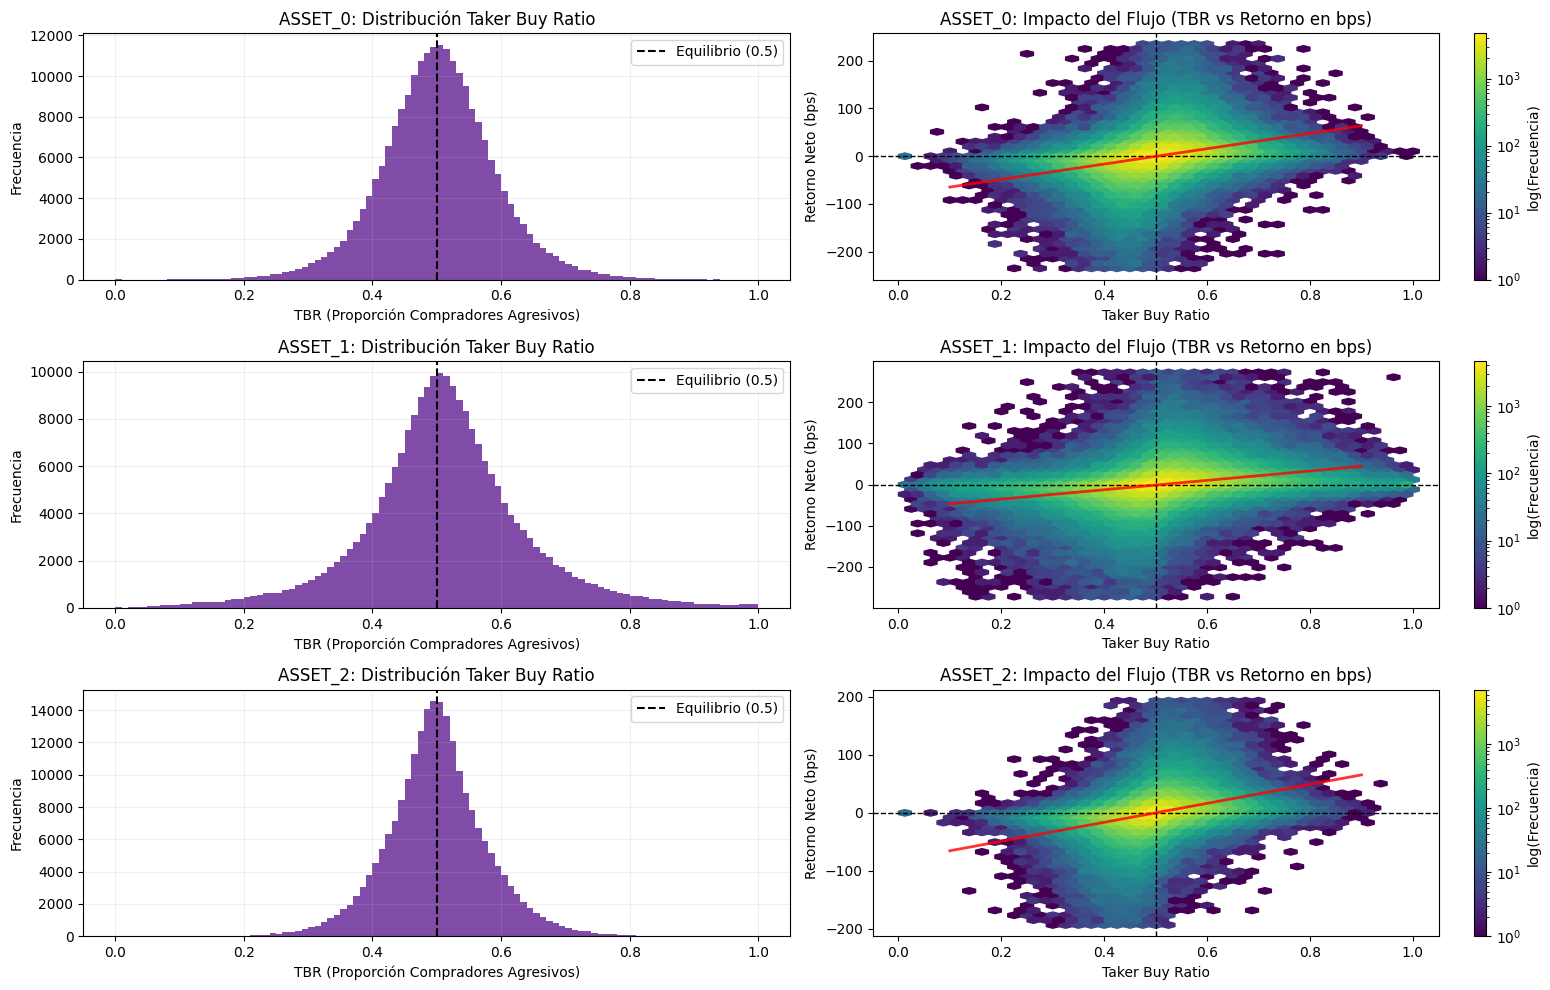

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_tbr_dynamics(data: pd.DataFrame, assets: list[str]):
    fig, axes = plt.subplots(len(assets), 2, figsize=(16, 10))
    
    for i, asset in enumerate(assets):
        # Asegurar cálculo en bps para el retorno
        close_price = data[f'{asset}_close']
        log_ret_bps = np.log(close_price / close_price.shift(1)) * 10000
        tbr = data[f'{asset}_taker_buy_ratio']
        
        # Alineación estricta de índices
        df_clean = pd.DataFrame({'tbr': tbr, 'ret': log_ret_bps}).dropna()
        
        # Panel Izquierdo: Histograma de Asimetría
        ax_dist = axes[i, 0]
        ax_dist.hist(df_clean['tbr'], bins=100, range=(0, 1), alpha=0.7, color='indigo')
        ax_dist.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Equilibrio (0.5)')
        ax_dist.set_title(f'{asset.upper()}: Distribución Taker Buy Ratio')
        ax_dist.set_xlabel('TBR (Proporción Compradores Agresivos)')
        ax_dist.set_ylabel('Frecuencia')
        ax_dist.legend()
        ax_dist.grid(alpha=0.2)
        
        # Panel Derecho: Tracción del Flujo (TBR vs Retorno)
        ax_scatter = axes[i, 1]
        # Restringimos los ejes visualmente para ignorar el 0.1% de ruido extremo
        ret_99 = np.percentile(np.abs(df_clean['ret']), 99.5)
        
        hb = ax_scatter.hexbin(df_clean['tbr'], df_clean['ret'], 
                               gridsize=40, cmap='viridis', bins='log', 
                               extent=(0, 1, -ret_99, ret_99), mincnt=1)
        
        ax_scatter.axvline(0.5, color='black', linestyle='--', linewidth=1)
        ax_scatter.axhline(0, color='black', linestyle='--', linewidth=1)
        
        # Regresión lineal simple para visualizar la pendiente de tracción
        z = np.polyfit(df_clean['tbr'], df_clean['ret'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(0.1, 0.9, 100)
        ax_scatter.plot(x_trend, p(x_trend), color='red', linestyle='-', linewidth=2, alpha=0.8)
        
        ax_scatter.set_title(f'{asset.upper()}: Impacto del Flujo (TBR vs Retorno en bps)')
        ax_scatter.set_xlabel('Taker Buy Ratio')
        ax_scatter.set_ylabel('Retorno Neto (bps)')
        cb = fig.colorbar(hb, ax=ax_scatter)
        cb.set_label('log(Frecuencia)')

    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN FASE 3
# =============================================================================
plot_tbr_dynamics(data_train, assets_list)

## **REPORTE DE ANÁLISIS EXPLORATORIO: DINÁMICA DE PRESIÓN DE EJECUCIÓN Y ABSORCIÓN (TBR)**

**1. Simetría Estructural del Flujo (Panel Izquierdo)**

* **Equilibrio termodinámico perfecto:** Los histogramas exponen una topología acampanada con una simetría absoluta, anclada con precisión milimétrica en la marca de $0.5$ (línea punteada negra) para la totalidad del ecosistema. Esto demuestra que no existe un dominio estructural persistente ni de compradores ni de vendedores agresivos a largo plazo.
* **Ausencia de sesgo direccional sistémico:** La aglomeración de la frecuencia en el centro indica que la inmensa mayoría de las velas de 15 minutos se negocian en un estado de neutralidad de flujo, donde los *takers* (ejecutores a mercado) impactan el *bid* y el *ask* en proporciones casi idénticas. El mercado es estructuralmente eficiente en su cruce de órdenes base.

**2. Tracción Direccional y el Muro de Absorción (Panel Derecho)**

* **Vector de causalidad directa (La línea de tracción):** La regresión lineal (línea roja) confirma la hipótesis mecánica fundamental del micro-flujo: existe una pendiente positiva clara entre la proporción de flujo agresivo y el retorno direccional neto de la vela. Quien paga el *spread* de forma asimétrica, dicta el signo y la magnitud base del retorno.
* **El muro de liquidez pasiva (Dispersión vertical):** La métrica visual más reveladora de este panel no es la correlación, sino la masiva nube de dispersión vertical (hexágonos púrpuras) en los extremos del eje X. Un nivel de agresión compradora extrema (ej. TBR > $0.8$) genera frecuentemente retornos altos ($+100$ bps), pero de igual forma converge en retornos de $0$ bps o incluso negativos. Esto es la evidencia física de la "absorción institucional": el flujo agresivo choca contra gruesos muros de liquidez límite (órdenes pasivas u órdenes *iceberg*), agotando la presión de los compradores a mercado sin lograr desplazar el precio.

**3. Consecuencias Estructurales para el Modelado**

* **Invalidación del TBR como Oráculo Direccional:** Este análisis demuestra que el diseño de políticas heurísticas o reglas simples basadas en el desbalance de órdenes está condenado al fracaso. Comprar ciegamente un activo porque su TBR acaba de cruzar un umbral extremo ($0.8$) garantiza estadísticamente comprar techos locales justo cuando el mercado está siendo absorbido por institucionales posicionados pasivamente.
* **Ingeniería de Características Compuestas (Detección de Divergencias):** El poder predictivo del TBR para la red neuronal no reside en su valor absoluto, sino en su divergencia geométrica frente al precio. El tensor de observación debe obligar a la arquitectura a evaluar de forma simultánea el TBR, el Volumen Transado y el Retorno Neto. Si el modelo detecta un TBR extremo (alta agresión) acompañado de alto volumen, pero el retorno neto es cercano a cero (fricción observada en la dispersión púrpura), debe aprender a interpretar este vector como una clara señal de agotamiento de la inercia, habilitando al agente para posicionarse en contra del flujo agresivo (reversión a la media).

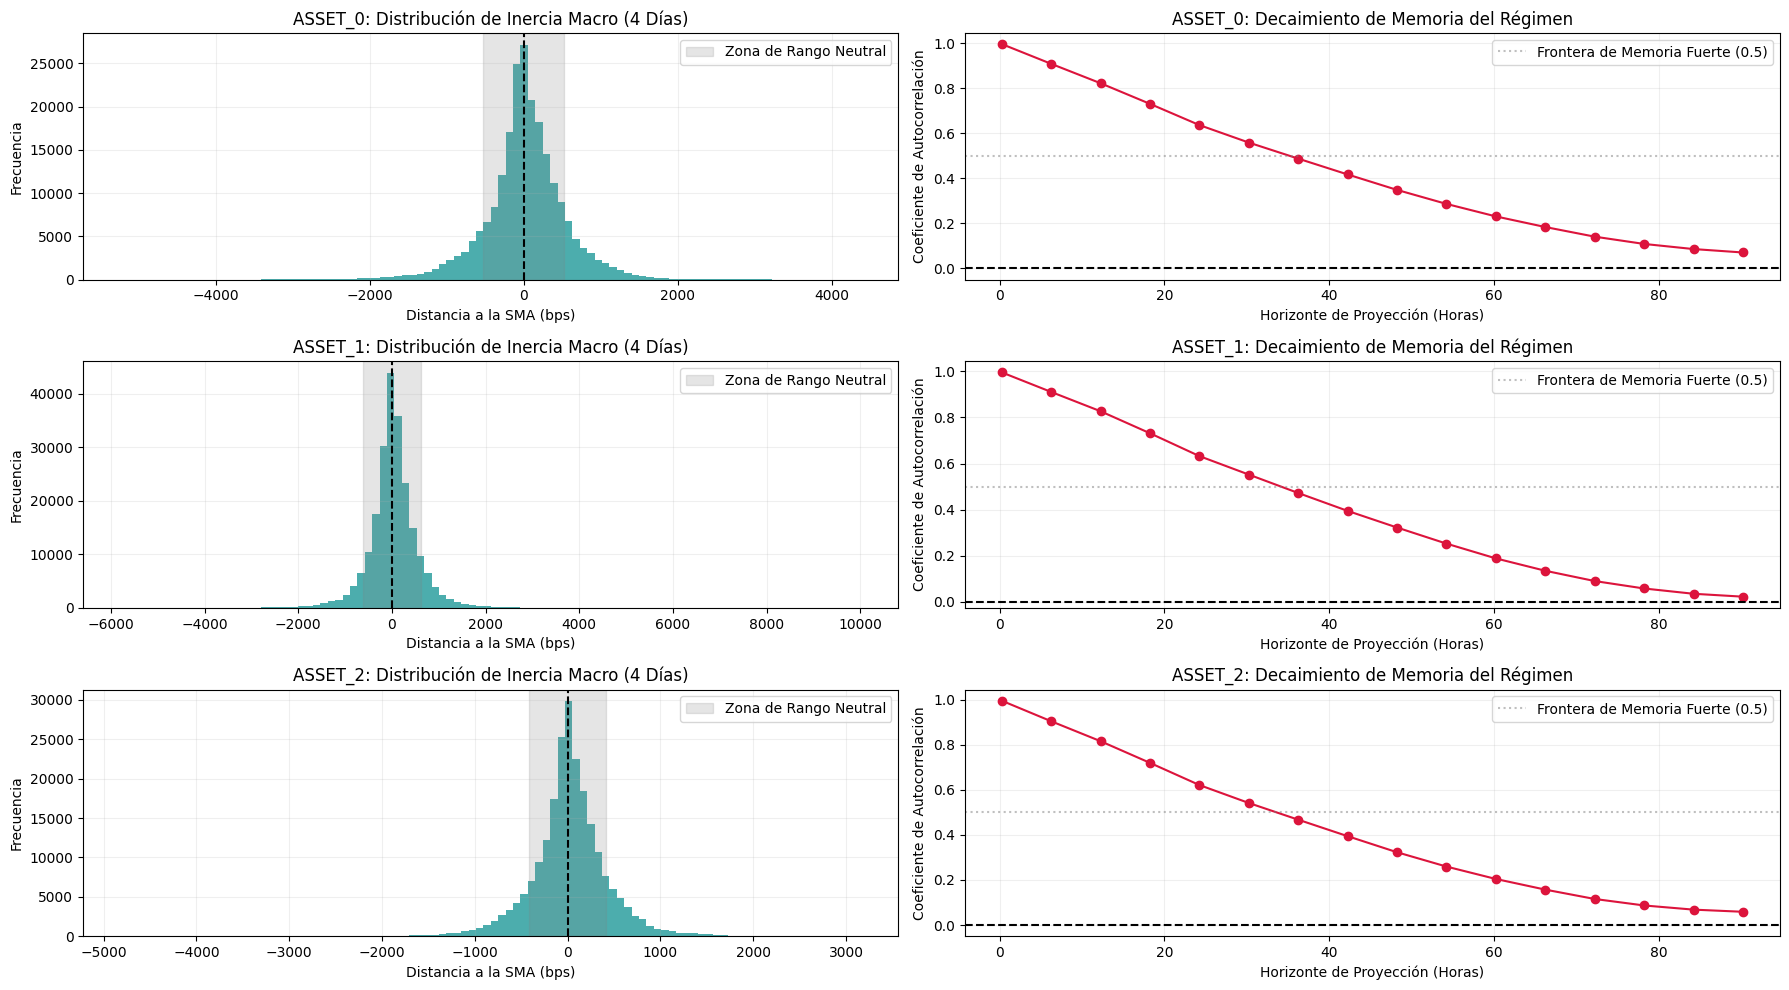

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_macro_momentum(df: pd.DataFrame, asset: str, window_bars: int = 384) -> pd.Series:
    """
    Calcula la distancia porcentual (en bps) del precio de cierre 
    respecto a su media móvil simple (SMA). 
    384 barras de 15m = 96 horas = 4 días operativos.
    """
    close = df[f'{asset}_close']
    sma = close.rolling(window=window_bars).mean()
    momentum_bps = ((close - sma) / sma) * 10000
    return momentum_bps.dropna()

def plot_macro_regimes(data: pd.DataFrame, assets: list[str]):
    fig, axes = plt.subplots(len(assets), 2, figsize=(18, 10))
    
    for i, asset in enumerate(assets):
        momentum = compute_macro_momentum(data, asset)
        
        # Panel Izquierdo: Distribución del Régimen Macro
        ax_dist = axes[i, 0]
        ax_dist.hist(momentum, bins=100, color='darkcyan', alpha=0.7)
        ax_dist.axvline(0, color='black', linestyle='--', linewidth=1.5)
        
        # Sombreado de regímenes extremos (+/- 1 desviación estándar)
        std_mom = momentum.std()
        ax_dist.axvspan(-std_mom, std_mom, color='gray', alpha=0.2, label='Zona de Rango Neutral')
        
        ax_dist.set_title(f'{asset.upper()}: Distribución de Inercia Macro (4 Días)')
        ax_dist.set_xlabel('Distancia a la SMA (bps)')
        ax_dist.set_ylabel('Frecuencia')
        ax_dist.legend()
        ax_dist.grid(alpha=0.2)
        
        # Panel Derecho: Estabilidad de la Tendencia (Autocorrelación del Régimen)
        # Queremos ver qué tan confiable es este indicador para anclar al agente
        ax_acf = axes[i, 1]
        
        lags = np.arange(1, 385, 24) # Saltos de 6 horas (24 barras) hasta 4 días
        acf_values = [momentum.autocorr(lag=lag) for lag in lags]
        lags_in_hours = lags / 4.0
        
        ax_acf.plot(lags_in_hours, acf_values, marker='o', color='crimson', linestyle='-')
        ax_acf.axhline(0, color='black', linestyle='--')
        ax_acf.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='Frontera de Memoria Fuerte (0.5)')
        
        ax_acf.set_title(f'{asset.upper()}: Decaimiento de Memoria del Régimen')
        ax_acf.set_xlabel('Horizonte de Proyección (Horas)')
        ax_acf.set_ylabel('Coeficiente de Autocorrelación')
        ax_acf.legend()
        ax_acf.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN FASE 4
# =============================================================================
plot_macro_regimes(data_train, assets_list)

## **REPORTE DE ANÁLISIS EXPLORATORIO: INERCIA MACRO Y PERSISTENCIA DE TENDENCIA**

**1. La Gravedad del Equilibrio (Distribución de Regímenes)**

* **Confinamiento neutral:** El panel izquierdo revela que la inercia macro de los tres activos posee una fuerte gravedad hacia el centro. El mercado transcurre la inmensa mayoría de su tiempo operativo (zona sombreada gris) oscilando de forma estrecha y ruidosa alrededor de su media móvil de 4 días. El estado base del ecosistema es la búsqueda del precio de equilibrio, no la tendencia.
* **Rupturas asimétricas (Colas pesadas):** A pesar de este confinamiento central, la distribución exhibe colas masivas y direccionalmente sesgadas. `ASSET_1` experimenta desviaciones positivas extremas (acercándose a los 10000 bps), mientras que `ASSET_2` muestra colas negativas profundas. Estas anomalías representan los "quiebres de régimen", momentos en los que el mercado abandona la lateralidad y entra en tendencias puras y violentas que dominan la acción del precio durante varios días.

**2. El Ancla Predictiva (Decaimiento de la Memoria)**

* **Validación de la inercia direccional:** El panel derecho expone el hallazgo predictivo más valioso del análisis. Mientras que los retornos brutos de 15 minutos carecían de autocorrelación instantánea, la inercia macro estructurada posee una memoria sistémica colosal.
* **Ventana de estabilidad operable:** La curva de autocorrelación cruza la frontera de memoria fuerte (0.5) de forma consistente entre las 35 y 40 horas de proyección, y no decae hacia el ruido estocástico (0.0) hasta acercarse a la marca de las 90 horas. Matemáticamente, esto garantiza que si un activo establece una desviación significativa respecto a su inercia macro en el instante actual, la probabilidad de que esa direccionalidad se sostenga durante la siguiente jornada operativa es abrumadora.

**Sugerencias Analíticas y de Modelamiento**

1. **Inclusión del Compás Macro:** El Oscilador de Inercia Normalizado (distancia a la SMA) debe ser una entrada obligatoria en el tensor de estado. Al entregarle esta variable pre-calculada, se libera a la red neuronal de gastar capacidad paramétrica (capas de atención) en deducir la tendencia macroeconómica a partir de velas de 15 minutos, permitiéndole enfocarse en optimizar el punto de ejecución.
2. **Bifurcación Táctica de la Política:** La presencia de dos regímenes claros (el núcleo neutral y las colas pesadas) exige que el agente aprenda estrategias duales. La recompensa debe forzarlo a operar sistemas de reversión a la media y cobro rápido de beneficios cuando se encuentre en la "Zona de Rango Neutral", y a adoptar un comportamiento de seguimiento de tendencia (dejando correr los beneficios) cuando el oscilador macro se dispare hacia las colas de distribución respaldado por la alta memoria de la serie.

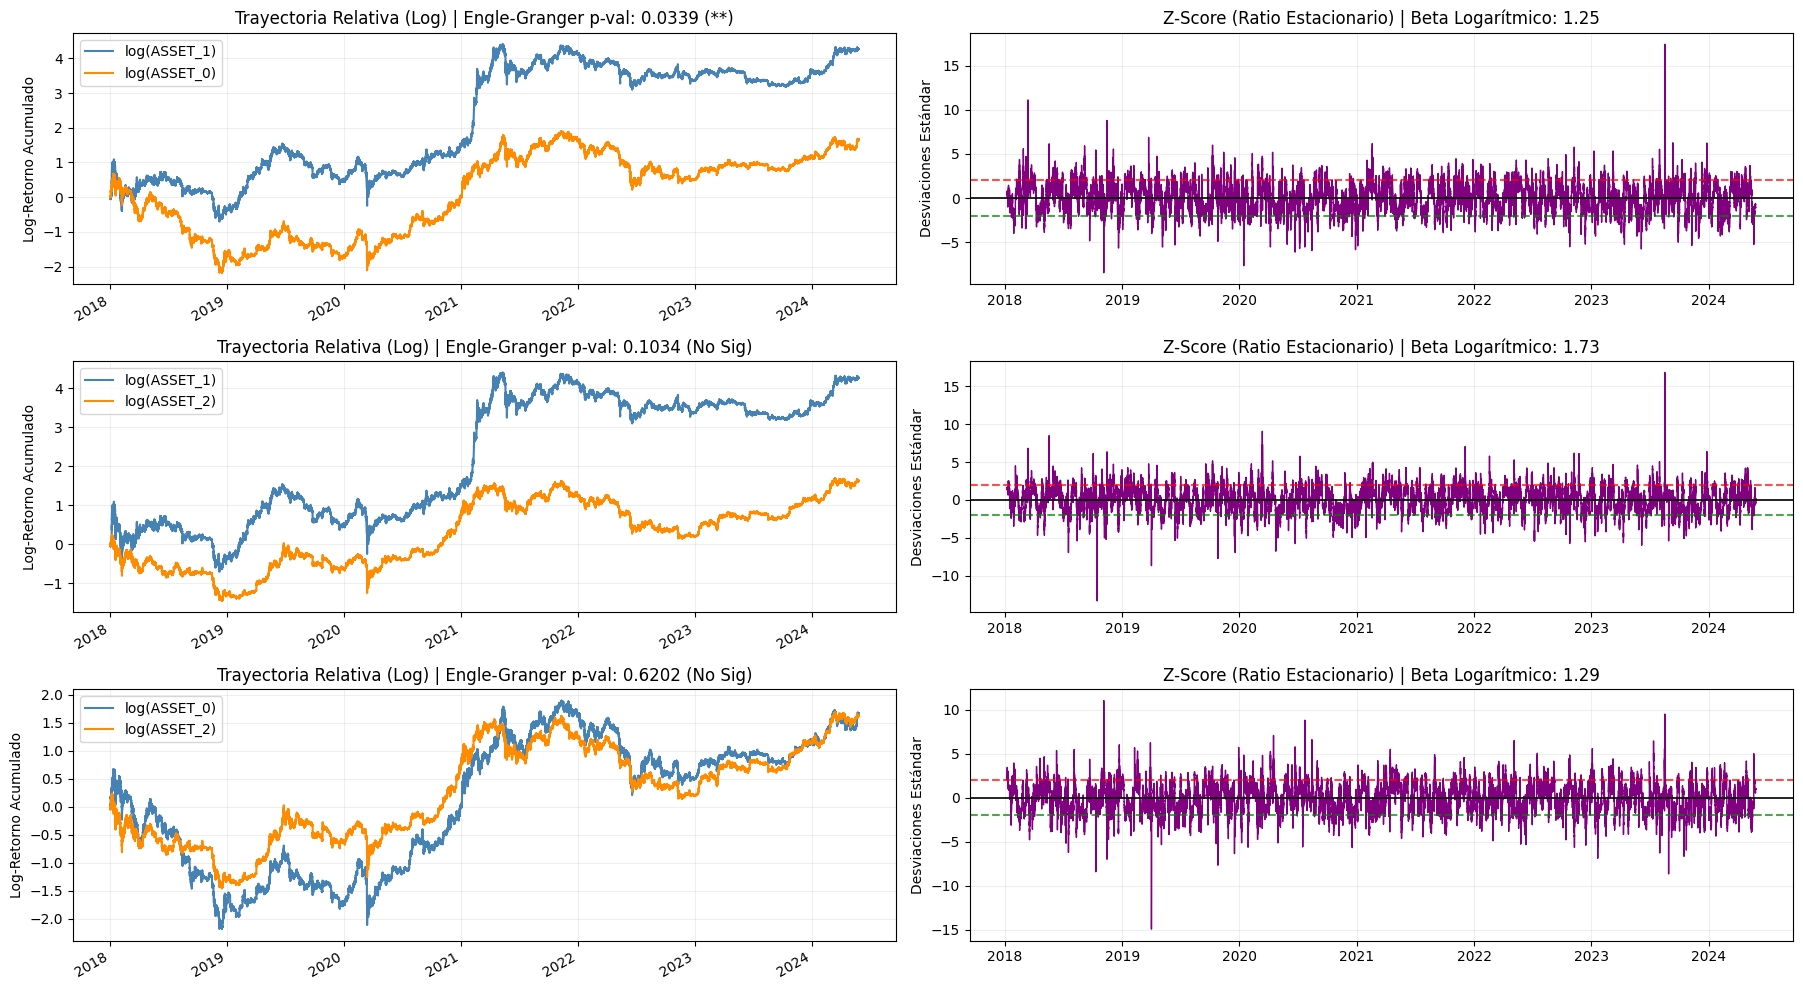

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

def plot_log_cointegration(data: pd.DataFrame, pairs: list[tuple]):
    """
    Evalúa la cointegración estricta de Engle-Granger sobre Log-Precios.
    Aísla la relación proporcional y comprime la heterocedasticidad de la varianza.
    """
    fig, axes = plt.subplots(len(pairs), 2, figsize=(18, 10))
    
    for i, (a1, a2) in enumerate(pairs):
        # Transformación logarítmica para evaluar el ratio
        log_p1 = np.log(data[f'{a1}_close'])
        log_p2 = np.log(data[f'{a2}_close'])
        
        # Test de Engle-Granger sobre log-precios
        score, p_value, _ = coint(log_p1, log_p2)
        is_coint = "***" if p_value < 0.01 else ("**" if p_value < 0.05 else "No Sig")
        
        # Cálculo del Beta estático y el Spread Logarítmico
        beta = np.cov(log_p1, log_p2)[0, 1] / np.var(log_p2)
        log_spread = log_p1 - beta * log_p2
        
        # Z-Score para la capa de observación del Agente (Ventana operativa de 7 días)
        window = 672
        spread_mean = log_spread.rolling(window=window).mean()
        spread_std = log_spread.rolling(window=window).std()
        z_score = (log_spread - spread_mean) / spread_std
        
        # Panel Izquierdo: Log-Precios Normalizados al inicio (Visualización de la proporción)
        ax_price = axes[i, 0]
        (log_p1 - log_p1.iloc[0]).plot(ax=ax_price, label=f'log({a1.upper()})', color='steelblue')
        (log_p2 - log_p2.iloc[0]).plot(ax=ax_price, label=f'log({a2.upper()})', color='darkorange')
        ax_price.set_title(f'Trayectoria Relativa (Log) | Engle-Granger p-val: {p_value:.4f} ({is_coint})')
        ax_price.set_ylabel('Log-Retorno Acumulado')
        ax_price.legend()
        ax_price.grid(alpha=0.2)
        
        # Panel Derecho: Z-Score del Log-Spread
        ax_z = axes[i, 1]
        ax_z.plot(z_score.index, z_score.values, color='purple', linewidth=1)
        ax_z.axhline(0, color='black', linewidth=1.2)
        ax_z.axhline(2, color='red', linestyle='--', alpha=0.7)
        ax_z.axhline(-2, color='green', linestyle='--', alpha=0.7)
        ax_z.set_title(f'Z-Score (Ratio Estacionario) | Beta Logarítmico: {beta:.2f}')
        ax_z.set_ylabel('Desviaciones Estándar')
        ax_z.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

# =============================================================================
# EJECUCIÓN COINTEGRACIÓN LOGARÍTMICA
# =============================================================================
target_pairs = [('asset_1', 'asset_0'), ('asset_1', 'asset_2'), ('asset_0', 'asset_2')]
plot_log_cointegration(data_train, target_pairs)

In [37]:
np.log(1.25)

np.float64(0.22314355131420976)

# Construcción de Features para RL
Basado en el EDA, aquí extraemos los features estacionarios y robustos que se utilizarán para alimentar el agente.

In [47]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from typing import List, Dict

# =============================================================================
# 1. PIPELINE DE EXTRACCIÓN DE DATOS (ESTADO)
# =============================================================================

def scale_local(series: pd.Series, window_bars: int) -> pd.Series:
    """Escalado robusto rodante estricto. Lookahead = 0."""
    min_obs = max(4, window_bars // 2)
    roll = series.rolling(window=window_bars, min_periods=min_obs)
    iqr = roll.quantile(0.75) - roll.quantile(0.25)
    return (series - roll.median()) / (iqr + 1e-8)

def calc_drawdown_local(close: pd.Series, high: pd.Series, window_bars: int) -> pd.Series:
    """Calcula el drawdown rodante relativo al máximo de la ventana estricta."""
    min_obs = max(4, window_bars // 2)
    rolling_max = high.rolling(window=window_bars, min_periods=min_obs).max()
    return (close - rolling_max) / (rolling_max + 1e-8)

def build_cyclical_time_15m(timestamps: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Extrae estrictamente los relojes cíclicos del mercado.
    Valores normalizados [0, 1]. SIN tiempo absoluto, índices continuos ni años.
    """
    coords = {
        "time_min": timestamps.minute / 60.0,
        "time_hour": timestamps.hour / 24.0,
        "time_dow": timestamps.dayofweek / 7.0
    }
    return pd.DataFrame(coords, index=timestamps)

def build_complete_agent_state(data: pd.DataFrame, scales_hours: List[int] = [171, 410]) -> pd.DataFrame:
    """
    Construye el tensor S_t completo: 60 Canales.
    - 54 Canales de Microestructura (18 por activo).
    - 6 Canales de Cointegración (Spreads relativos a asset_0 en 3 escalas).
    """
    frames: List[pd.DataFrame] = []
    assets: List[str] = ['asset_0', 'asset_1', 'asset_2']
    
    # 1. Tiempo Cíclico (3 dimensiones físicas)
    time_df = build_cyclical_time_15m(data.index)
    frames.append(time_df)

    # 2. Señales de Cointegración (Arbitraje relativo)
    log_p0 = np.log(data["asset_0_close"])
    log_p1 = np.log(data["asset_1_close"])
    log_p2 = np.log(data["asset_2_close"])
    
    spread_features: Dict[str, pd.Series] = {}
    
    # Táctica intradiaria (base 24h = 96 barras)
    spread_features["spread_1_0_base"] = scale_local(log_p1 - log_p0, 96)
    spread_features["spread_2_0_base"] = scale_local(log_p2 - log_p0, 96)
    
    # Escalas macro (171h y 410h)
    for h in scales_hours:
        w_bars = h * 4
        spread_features[f"spread_1_0_{h}h"] = scale_local(log_p1 - log_p0, w_bars)
        spread_features[f"spread_2_0_{h}h"] = scale_local(log_p2 - log_p0, w_bars)
        
    frames.append(pd.DataFrame(spread_features, index=data.index))

    # 3. Microestructura Táctica y Sensores Macro por Activo
    for asset in assets:
        close = data[f"{asset}_close"]
        high = data[f"{asset}_high"]
        low = data[f"{asset}_low"]
        vol = data[f"{asset}_volume"]
        tbr = data[f"{asset}_taker_buy_ratio"]
        
        # Táctica cruda (15 minutos)
        log_ret = np.log(close / close.shift(1))
        abs_ret = log_ret.abs()
        amplitude = (high - low) / close.shift(1)
        vol_roc = np.log1p(vol) - np.log1p(vol.shift(1))
        
        # Drawdown táctico base (24h)
        drawdown_base = calc_drawdown_local(close, high, window_bars=96)
        
        asset_features: Dict[str, pd.Series] = {
            f"{asset}_raw_log_ret": log_ret,
            f"{asset}_raw_abs_ret": abs_ret,
            f"{asset}_raw_amplitude": amplitude,
            f"{asset}_raw_vol_roc": vol_roc,
            f"{asset}_raw_tbr": tbr,
            f"{asset}_raw_drawdown": drawdown_base
        }
        
        # Sensores de Régimen Multiescala
        for h in scales_hours:
            w_bars = h * 4
            hours_label = f"{h}h"
            
            asset_features[f"{asset}_log_ret_{hours_label}"] = scale_local(log_ret, w_bars)
            asset_features[f"{asset}_abs_ret_{hours_label}"] = scale_local(abs_ret, w_bars)
            asset_features[f"{asset}_amplitude_{hours_label}"] = scale_local(amplitude, w_bars)
            asset_features[f"{asset}_vol_roc_{hours_label}"] = scale_local(vol_roc, w_bars)
            asset_features[f"{asset}_tbr_{hours_label}"] = scale_local(tbr, w_bars)
            asset_features[f"{asset}_drawdown_{hours_label}"] = calc_drawdown_local(close, high, w_bars)

        frames.append(pd.DataFrame(asset_features, index=data.index))
        
    return pd.concat(frames, axis=1).dropna()


In [44]:
feat_train = build_complete_agent_state(data_train)
feat_test = build_complete_agent_state(data_test)

In [42]:
feat_train

,time_continuous,spread_1_0_171h,spread_2_0_171h,spread_1_0_410h,spread_2_0_410h,asset_0_raw_log_ret,asset_0_raw_abs_ret,asset_0_raw_amplitude,asset_0_raw_vol_roc,asset_0_raw_tbr,...,asset_2_amplitude_171h,asset_2_vol_roc_171h,asset_2_tbr_171h,asset_2_drawdown_171h,asset_2_log_ret_410h,asset_2_abs_ret_410h,asset_2_amplitude_410h,asset_2_vol_roc_410h,asset_2_tbr_410h,asset_2_drawdown_410h
2018-01-09 14:29:59.999,0.023402,-0.029223,-1.844299,0.497795,-1.916450,0.014304,0.014304,0.027380,-0.602110,0.505678,...,1.337749,-1.514109,-0.493875,-0.164602,0.514988,0.059365,1.392654,-1.489332,-0.360370,-0.164602
2018-01-09 14:44:59.999,0.023430,-0.021345,-1.851155,0.506220,-1.917981,0.013317,0.013317,0.019225,0.175902,0.509418,...,1.577415,0.288715,-0.550907,-0.154513,1.303269,1.268169,1.649271,0.286986,-0.413259,-0.154513
2018-01-09 14:59:59.999,0.023459,-0.037119,-1.860160,0.489806,-1.918539,0.004511,0.004511,0.053393,0.257375,0.513118,...,0.143862,-1.356668,-0.983979,-0.152289,0.272145,-0.310914,0.149667,-1.337055,-0.813238,-0.152289
2018-01-09 15:14:59.999,0.023487,-0.023535,-1.821865,0.503758,-1.872027,-0.001682,0.001682,0.010566,-0.112585,0.586769,...,1.009152,0.796555,-0.805343,-0.149232,0.379445,-0.145908,1.060086,0.788420,-0.649628,-0.149232
2018-01-09 15:29:59.999,0.023516,0.007806,-1.823050,0.537640,-1.875728,0.010041,0.010041,0.016708,-0.589530,0.544231,...,0.082992,-0.879681,-0.763921,-0.141282,1.002014,0.813104,0.086984,-0.862920,-0.607527,-0.141282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-26 19:44:59.999,6.390411,-1.483499,-1.005823,-1.000667,-1.080545,0.003566,0.003566,0.004018,0.038371,0.581843,...,-0.765999,-0.573693,0.185591,-0.042915,0.287492,-0.249057,-0.801992,-0.544305,0.224757,-0.042915
2024-05-26 19:59:59.999,6.390439,-1.584555,-1.121091,-1.016239,-1.095759,0.002574,0.002574,0.003841,0.659620,0.571411,...,-0.721652,1.373331,-0.199095,-0.042727,0.056786,-0.580915,-0.755079,1.286732,-0.160840,-0.042727
2024-05-26 20:14:59.999,6.390468,-1.562108,-1.119432,-1.012112,-1.087422,-0.001806,0.001806,0.003318,-0.360243,0.438727,...,-0.774904,-0.609621,-0.552630,-0.043352,-0.347052,-0.269003,-0.812167,-0.575648,-0.510147,-0.043352
2024-05-26 20:29:59.999,6.390497,-1.501769,-1.089646,-1.003233,-1.080408,-0.002112,0.002112,0.002846,-0.057143,0.422521,...,-0.523498,-0.291024,-1.270398,-0.044443,-0.578806,0.068152,-0.555504,-0.272821,-1.235091,-0.044443


In [48]:
feat_train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 223105 entries, 2018-01-09 14:29:59.999000 to 2024-05-26 20:44:59.999000
Data columns (total 63 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time_min                223105 non-null  float64
 1   time_hour               223105 non-null  float64
 2   time_dow                223105 non-null  float64
 3   spread_1_0_base         223105 non-null  float64
 4   spread_2_0_base         223105 non-null  float64
 5   spread_1_0_171h         223105 non-null  float64
 6   spread_2_0_171h         223105 non-null  float64
 7   spread_1_0_410h         223105 non-null  float64
 8   spread_2_0_410h         223105 non-null  float64
 9   asset_0_raw_log_ret     223105 non-null  float64
 10  asset_0_raw_abs_ret     223105 non-null  float64
 11  asset_0_raw_amplitude   223105 non-null  float64
 12  asset_0_raw_vol_roc     223105 non-null  float64
 13  asset_0_raw_tbr         223105 non-nu

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Time2Vec(nn.Module):
    """
    Codificador temporal continuo. 
    Separa el tiempo en una componente lineal (tendencia) y una periódica (estacionalidad).
    """
    def __init__(self, in_features: int = 3, out_dim: int = 128):
        super().__init__()
        self.k_linear = in_features 
        self.k_periodic = out_dim - in_features
        
        self.trend_proj = nn.Linear(in_features, self.k_linear)
        self.periodic_proj = nn.Linear(in_features, self.k_periodic)
        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.uniform_(self.trend_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.trend_proj.bias)
        nn.init.uniform_(self.periodic_proj.weight, -1.0, 1.0)
        nn.init.zeros_(self.periodic_proj.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        trend = self.trend_proj(t)
        periodic = torch.sin(self.periodic_proj(t))
        return torch.cat([trend, periodic], dim=-1)


class RevIN(nn.Module):
    """
    Reversible Instance Normalization.
    Centra la ventana local a media 0 y varianza 1 para proteger el espacio latente
    de cambios macroeconómicos y permitir un enmascaramiento con ceros coherente.
    """
    def __init__(self, num_features: int, eps: float = 1e-5, affine: bool = True):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        
        if self.affine:
            self.weight = nn.Parameter(torch.ones(1, 1, num_features))
            self.bias = nn.Parameter(torch.zeros(1, 1, num_features))

    def forward(self, x: torch.Tensor, mode: str) -> torch.Tensor:
        if mode == 'norm':
            self._get_statistics(x)
            return self._normalize(x)
        elif mode == 'denorm':
            return self._denormalize(x)
        else:
            raise ValueError("El modo debe ser 'norm' o 'denorm'")

    def _get_statistics(self, x: torch.Tensor):
        # Mantenemos el grafo computacional intacto (sin detach)
        self.mean = torch.mean(x, dim=1, keepdim=True)
        self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps)

    def _normalize(self, x: torch.Tensor):
        x = (x - self.mean) / self.stdev
        if self.affine:
            x = x * self.weight + self.bias
        return x

    def _denormalize(self, x: torch.Tensor):
        if self.affine:
            x = (x - self.bias) / (self.weight + self.eps)
        x = (x * self.stdev) + self.mean
        return x


class QuantRoberta(nn.Module):
    """
    Transformer de Arbitraje Estadístico con Parcheo Temporal (PatchTST).
    Diseñado para actuar como Autoencoder en pre-entrenamiento y extractor de estado [CLS] para RL.
    """
    def __init__(
        self, 
        input_features_dim: int = 60, 
        time_features_dim: int = 3, 
        d_model: int = 128,  
        raw_window_bars: int = 688,  
        patch_size: int = 16,        
        stride: int = 8,             
        n_heads: int = 4, 
        n_layers: int = 2,
        dropout_rate: float = 0.1
    ):
        super().__init__()
        self.d_model = d_model
        self.patch_size = patch_size
        self.stride = stride
        self.num_patches = ((raw_window_bars - patch_size) // stride) + 1
        
        # 0. Normalización Temporal
        self.revin = RevIN(num_features=input_features_dim, affine=True)

        # 1. Compresión Espacial
        self.patch_embedding = nn.Conv1d(
            in_channels=input_features_dim, 
            out_channels=d_model, 
            kernel_size=patch_size, 
            stride=stride
        )
        
        # 2. Codificador Temporal
        self.time_encoding = Time2Vec(in_features=time_features_dim, out_dim=d_model)
        
        # 3. Tokens Estructurales (CLS para estado RL, PAD para tensores asimétricos)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pad_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.pad_token, std=0.02)
        
        # 4. Positional Encoding (Absoluto para series de contexto rígido)
        # Tamaño = num_patches + 1 (por el token [CLS])
        self.positional_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 1, d_model))
        nn.init.normal_(self.positional_embedding, std=0.02)
        
        self.emb_norm = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout_rate)
        
        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 2, 
            dropout=dropout_rate, 
            activation="gelu", 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # 6. Cabeza Decodificadora MLM (Solo activa durante pre-entrenamiento)
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.LayerNorm(d_model * 2),
            nn.Linear(d_model * 2, input_features_dim * patch_size)
        )

    def forward(
        self, 
        x: torch.Tensor, 
        t: torch.Tensor, 
        raw_padding_mask: torch.Tensor = None, 
        return_reconstruction: bool = False,
        spatial_mask: torch.Tensor = None  # <--- CORRECCIÓN AÑADIDA AQUÍ
    ) -> torch.Tensor:
        """
        x: Tensor de características físicas [Batch, 688, 60]
        t: Tensor de relojes cíclicos [Batch, 688, 3]
        raw_padding_mask: Booleano [Batch, 688]. True donde la barra es PAD.
        return_reconstruction: True = Devuelve parches reconstruidos. False = Devuelve vector [CLS].
        spatial_mask: Booleano [Batch, 688, 60]. True en los canales que el PreTrainer decidió ocultar.
        """
        B = x.shape[0]
        
        # --- 0. NORMALIZACIÓN DE INSTANCIA ---
        # Calculamos la estadística REAL de la serie limpia
        x_norm = self.revin(x, mode='norm')

        # --- 0.5 MÁSCARA ESPACIAL (Solo Pre-entrenamiento) ---
        if spatial_mask is not None:
            # En el espacio ya normalizado de RevIN, 0.0 significa "comportamiento promedio exacto"
            x_norm = x_norm.masked_fill(spatial_mask, 0.0)
        
        # --- 1. COMPRESIÓN FÍSICA ---
        x_t = x_norm.transpose(1, 2)               # [B, 60, 688]
        patched = self.patch_embedding(x_t)        # [B, 128, 85]
        tokens = patched.transpose(1, 2)           # [B, 85, 128]
        
        # --- 2. FUSIÓN TARDÍA DEL TIEMPO ---
        patch_end_indices = torch.arange(self.patch_size - 1, x.shape[1], self.stride, device=x.device)
        t_sampled = t[:, patch_end_indices, :]     # [B, 85, 3]
        tokens = tokens + self.time_encoding(t_sampled)
        
        # --- 3. LÓGICA DE PADDING ---
        if raw_padding_mask is not None:
            mask_float = raw_padding_mask.float().unsqueeze(1) # [B, 1, 688]
            # Un parche es PAD exclusivamente si TODAS sus barras internas son PAD (promedio = 1.0)
            patch_pad_float = F.avg_pool1d(mask_float, kernel_size=self.patch_size, stride=self.stride)
            patch_padding_mask = (patch_pad_float == 1.0).squeeze(1) # [B, 85] booleano
            
            # Reemplazar parches vacíos con el pad_token limpio
            expanded_pad = self.pad_token.expand(B, self.num_patches, -1)
            tokens = torch.where(patch_padding_mask.unsqueeze(-1), expanded_pad, tokens)
        else:
            patch_padding_mask = torch.zeros((B, self.num_patches), dtype=torch.bool, device=x.device)

        # --- 4. ENSAMBLAJE ESTRUCTURAL ---
        cls_tokens_batch = self.cls_token.expand(B, -1, -1)
        
        # Secuencia: [CLS] + Parches
        sequence = torch.cat([cls_tokens_batch, tokens], dim=1) # [B, 86, 128]
        sequence = sequence + self.positional_embedding
        sequence = self.emb_dropout(self.emb_norm(sequence))
        
        # --- 5. ATENCIÓN Y ENRUTAMIENTO ---
        # El CLS nunca es PAD (False). Concatenamos para obtener máscara [B, 86]
        cls_pad = torch.zeros((B, 1), dtype=torch.bool, device=x.device)
        attn_padding_mask = torch.cat([cls_pad, patch_padding_mask], dim=1) 
        
        transformer_out = self.transformer(sequence, src_key_padding_mask=attn_padding_mask)
        
        # --- 6. ENRUTAMIENTO FÍSICO ---
        if return_reconstruction:
            # Descartamos el token CLS en posición 0, pasamos los 85 parches al decodificador
            return self.mlm_head(transformer_out[:, 1:, :])
        else:
            # Devolvemos exclusivamente el estado latente (CLS) al agente RL
            return transformer_out[:, 0, :]

In [60]:
from typing import List

def get_asset_groups_by_name(feature_cols: List[str]) -> List[List[int]]:
    """
    Agrupa los índices del tensor físico según el activo al que pertenecen.
    Inmune a cambios en el orden o cantidad de las columnas.
    """
    asset_0_indices = []
    asset_1_indices = []
    asset_2_indices = []
    
    for i, col in enumerate(feature_cols):
        # Activo 0 (Base): Controla sus datos directos y TODOS los spreads
        if 'asset_0' in col or 'spread_1_0' in col or 'spread_2_0' in col:
            asset_0_indices.append(i)
            
        # Activo 1: Controla sus datos directos y SOLO sus spreads contra el 0
        if 'asset_1' in col or 'spread_1_0' in col:
            asset_1_indices.append(i)
            
        # Activo 2: Controla sus datos directos y SOLO sus spreads contra el 0
        if 'asset_2' in col or 'spread_2_0' in col:
            asset_2_indices.append(i)
            
    # Retornamos sin duplicados por si acaso
    return [
        list(set(asset_0_indices)), 
        list(set(asset_1_indices)), 
        list(set(asset_2_indices))
    ]

groups = get_asset_groups_by_name(feat_train)

In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from typing import List, Tuple
import random
from tqdm import tqdm

def get_asset_groups_by_name(feature_cols: List[str]) -> List[List[int]]:
    """Agrupa dinámicamente los índices por activo. Inmune al orden de las columnas."""
    groups = [[], [], []]
    for i, col in enumerate(feature_cols):
        # Si ocultamos el Activo 0 (Base), caen sus datos y TODOS los spreads del mercado
        if 'asset_0' in col or 'spread_1_0' in col or 'spread_2_0' in col:
            groups[0].append(i)
        # Activo 1: sus datos y sus spreads contra el 0
        if 'asset_1' in col or 'spread_1_0' in col:
            groups[1].append(i)
        # Activo 2: sus datos y sus spreads contra el 0
        if 'asset_2' in col or 'spread_2_0' in col:
            groups[2].append(i)
    return [list(set(g)) for g in groups]

class QuantPretrainDataset(Dataset):
    def __init__(self, data: pd.DataFrame, window_bars: int = 688, step: int = 8):
        self.window_bars = window_bars
        
        # Separación ciega del tiempo y la física
        self.time_cols = [c for c in data.columns if c.startswith('time_')]
        self.feature_cols = [c for c in data.columns if not c.startswith('time_')]
        
        # Extracción a numpy float32 para fluir veloz a la GPU
        self.t_data = data[self.time_cols].values.astype(np.float32)
        self.x_data = data[self.feature_cols].values.astype(np.float32)
        
        # Índices de inicio válidos para la ventana deslizante
        self.valid_indices = np.arange(0, len(self.x_data) - self.window_bars + 1, step)
        
    def __len__(self):
        return len(self.valid_indices)
        
    def __getitem__(self, idx):
        start = self.valid_indices[idx]
        end = start + self.window_bars
        
        x = self.x_data[start:end]
        t = self.t_data[start:end]
        
        # En pre-entrenamiento sobre datos continuos no hay padding (todo es historia útil)
        pad_mask = np.zeros(self.window_bars, dtype=bool)
        
        return torch.tensor(x), torch.tensor(t), torch.tensor(pad_mask)
    
class LogCoshLoss(nn.Module):
    def forward(self, y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        diff = y_pred - y_true
        return torch.mean(diff + F.softplus(-2.0 * diff) - 0.693147)

class QuantPreTrainer:
    def __init__(self, model: nn.Module, optimizer: torch.optim.Optimizer, asset_groups: List[List[int]], mask_ratio: float = 0.15):
        self.model = model
        self.optimizer = optimizer
        self.asset_groups = asset_groups
        self.mask_ratio = mask_ratio
        
        self.patch_size = model.patch_size
        self.stride = model.stride
        self.num_patches = model.num_patches
        self.criterion = LogCoshLoss()

    def _forward_pass(self, x: torch.Tensor, t: torch.Tensor, pad_mask: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        B, seq_len, num_features = x.shape
        device = x.device
        
        # 1. Crear Máscara Espacial Estocástica
        spatial_mask = torch.zeros((B, seq_len, num_features), dtype=torch.bool, device=device)
        num_to_mask = max(1, int(self.num_patches * self.mask_ratio))
        
        for b in range(B):
            patches_to_mask = random.sample(range(self.num_patches), num_to_mask)
            for p in patches_to_mask:
                num_assets_to_hide = random.choice([1, 2]) # ¿Cegamos 1 o 2 monedas?
                assets_to_hide = random.sample(range(len(self.asset_groups)), num_assets_to_hide)
                
                start_bar = p * self.stride
                end_bar = start_bar + self.patch_size
                for a_idx in assets_to_hide:
                    spatial_mask[b, start_bar:end_bar, self.asset_groups[a_idx]] = True

        # 2. Extraer la Verdad Normalizada (Targets)
        with torch.no_grad():
            x_target_norm = self.model.revin(x, mode='norm')
            
        targets_patched = x_target_norm.transpose(1, 2).unfold(2, self.patch_size, self.stride) 
        targets_patched = targets_patched.transpose(1, 2).contiguous().view(B, self.num_patches, -1)
        
        mask_patched = spatial_mask.transpose(1, 2).unfold(2, self.patch_size, self.stride)
        mask_patched = mask_patched.transpose(1, 2).contiguous().view(B, self.num_patches, -1)

        # 3. Forward Pass del Transformer (El modelo es ciego donde spatial_mask es True)
        raw_pad = pad_mask if pad_mask.any() else None
        preds = self.model(
            x=x, t=t, raw_padding_mask=raw_pad, 
            return_reconstruction=True, spatial_mask=spatial_mask
        )
        
        # 4. Pérdida Quirúrgica (Solo evaluamos lo que ocultamos)
        valid_preds = preds[mask_patched]
        valid_targets = targets_patched[mask_patched]
        
        if valid_preds.numel() > 0:
            loss = self.criterion(valid_preds, valid_targets)
            # MAE (Mean Absolute Error) para lectura humana
            with torch.no_grad():
                mae = torch.mean(torch.abs(valid_preds - valid_targets))
        else:
            loss = torch.tensor(0.0, requires_grad=True, device=device)
            mae = torch.tensor(0.0, device=device)
            
        return loss, mae

    def train_step(self, x: torch.Tensor, t: torch.Tensor, pad_mask: torch.Tensor) -> Tuple[float, float]:
        self.model.train()
        self.optimizer.zero_grad()
        loss, mae = self._forward_pass(x, t, pad_mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
        self.optimizer.step()
        return loss.item(), mae.item()

    @torch.no_grad()
    def val_step(self, x: torch.Tensor, t: torch.Tensor, pad_mask: torch.Tensor) -> Tuple[float, float]:
        self.model.eval()
        loss, mae = self._forward_pass(x, t, pad_mask)
        return loss.item(), mae.item()

In [62]:
def run_pretraining(
    df: pd.DataFrame, 
    model: nn.Module, 
    epochs: int = 15, 
    batch_size: int = 128, 
    lr: float = 3e-4,
    val_split: float = 0.15
):
    # Detección de hardware nativo
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"\n🚀 Iniciando Fase 1 en: {device}")
    print(f"📊 Barrera de la ignorancia (Adivinar media): MAE ~0.79\n")
    
    # 1. División Cronológica (El futuro jamás toca el entrenamiento)
    split_idx = int(len(df) * (1 - val_split))
    train_df = df.iloc[:split_idx]
    val_df = df.iloc[split_idx:] 
    
    train_dataset = QuantPretrainDataset(train_df, step=8)
    # Valid_dataset salta de 16 en 16 para evaluar el doble de rápido sin perder rigor estadístico
    val_dataset = QuantPretrainDataset(val_df, step=16) 
    
    # IMPORTANTE: shuffle=True en Train obliga a aprender covarianza y no a memorizar la fecha
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    
    asset_groups = get_asset_groups_by_name(train_dataset.feature_cols)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    trainer = QuantPreTrainer(model, optimizer, asset_groups, mask_ratio=0.15)
    
    best_val_mae = float('inf')
    
    # 2. Bucle Principal
    for epoch in range(epochs):
        # --- TRAIN ---
        train_loss, train_mae = 0.0, 0.0
        pbar_train = tqdm(train_loader, desc=f"🟢 Ep {epoch+1:02d}/{epochs} [Train]", leave=False)
        
        for batch_x, batch_t, batch_pad in pbar_train:
            loss, mae = trainer.train_step(batch_x.to(device), batch_t.to(device), batch_pad.to(device))
            train_loss += loss
            train_mae += mae
            pbar_train.set_postfix({'LCosh': f"{loss:.4f}", 'MAE': f"{mae:.4f}"})
            
        train_loss /= len(train_loader)
        train_mae /= len(train_loader)
        
        # --- VALIDATION ---
        val_loss, val_mae = 0.0, 0.0
        pbar_val = tqdm(val_loader, desc=f"🔵 Ep {epoch+1:02d}/{epochs} [Valid]", leave=False)
        
        for batch_x, batch_t, batch_pad in pbar_val:
            loss, mae = trainer.val_step(batch_x.to(device), batch_t.to(device), batch_pad.to(device))
            val_loss += loss
            val_mae += mae
            
        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        
        # --- REPORTE Y GUARDADO ---
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            # weights_only=True por seguridad de PyTorch 2.x
            torch.save(model.state_dict(), "quantroberta_best.pth")
            marker = "💾 [NUEVO RÉCORD]"
        else:
            marker = ""
            
        print(f"Ep {epoch+1:02d} | Train MAE: {train_mae:.4f} | Valid MAE: {val_mae:.4f} {marker}")

    print("\n✅ Pre-entrenamiento completado.")
    print("Carga los pesos de 'quantroberta_best.pth' en el Agente PPO para la Fase 2.")
    return model

In [63]:
# =============================================================================
# EJECUCIÓN DE LA FASE 1: PRE-ENTRENAMIENTO (CROSS-ASSET MASKING)
# =============================================================================

# 1. Extraer dinámicamente las dimensiones a partir de tu DataFrame
time_cols = [c for c in feat_train.columns if c.startswith('time_')]
feature_cols = [c for c in feat_train.columns if not c.startswith('time_')]

input_features_dim = len(feature_cols)  # Debería dar exactamente 60
time_features_dim = len(time_cols)      # Debería dar exactamente 3

print(f"📊 Configurando modelo con {input_features_dim} canales físicos y {time_features_dim} canales temporales.")

# 2. Instanciar la red QuantRoberta
model = QuantRoberta(
    input_features_dim=input_features_dim, 
    time_features_dim=time_features_dim, 
    d_model=128,              # Dimensión del estado latente [CLS] que usará el PPO después
    raw_window_bars=688,      # El tamaño estricto de tu ventana
    patch_size=16,            # Compresión: Agrupación de a 4 horas
    stride=8,                 # Solapamiento: Stride de 2 horas para continuidad
    n_heads=4, 
    n_layers=2,               # 2 capas es el "sweet spot" para no sobreajustar en ruido financiero
    dropout_rate=0.1
)

# 3. Arrancar el bucle de pre-entrenamiento
# ⚠️ NOTA DE HARDWARE: Un lote de 128 con tensores de 688x60 consume bastante VRAM.
# Si la consola te lanza un error "CUDA/MPS Out Of Memory", simplemente baja el batch_size a 64 o 32.
trained_model = run_pretraining(
    df=feat_train, 
    model=model, 
    epochs=20,             # 20 épocas es un buen horizonte para ver la convergencia
    batch_size=128,        # Ajusta esto según tu tarjeta gráfica
    lr=3e-4,               # Tasa de aprendizaje "estándar de oro" para AdamW en Transformers
    val_split=0.15         # Reserva el último 15% cronológico estrictamente para validación
)

📊 Configurando modelo con 60 canales físicos y 3 canales temporales.

🚀 Iniciando Fase 1 en: cuda
📊 Barrera de la ignorancia (Adivinar media): MAE ~0.79



Ep 01 | Train MAE: 0.6356 | Valid MAE: 0.5723 💾 [NUEVO RÉCORD]


Ep 02 | Train MAE: 0.5596 | Valid MAE: 0.5248 💾 [NUEVO RÉCORD]


Ep 03 | Train MAE: 0.5336 | Valid MAE: 0.5170 💾 [NUEVO RÉCORD]


Ep 04 | Train MAE: 0.5234 | Valid MAE: 0.4992 💾 [NUEVO RÉCORD]


...

Ep 16 | Train MAE: 0.4636 | Valid MAE: 0.4351 💾 [NUEVO RÉCORD]


Ep 17 | Train MAE: 0.4605 | Valid MAE: 0.4308 💾 [NUEVO RÉCORD]


Ep 18 | Train MAE: 0.4584 | Valid MAE: 0.4275 💾 [NUEVO RÉCORD]


Ep 19 | Train MAE: 0.4561 | Valid MAE: 0.4259 💾 [NUEVO RÉCORD]


Ep 20 | Train MAE: 0.4540 | Valid MAE: 0.4282 

✅ Pre-entrenamiento completado.
Carga los pesos de 'quantroberta_best.pth' en el Agente PPO para la Fase 2.


In [67]:
trained_model = run_pretraining(
    df=feat_train, 
    model=trained_model, 
    epochs=20,             # 20 épocas es un buen horizonte para ver la convergencia
    batch_size=128,        # Ajusta esto según tu tarjeta gráfica
    lr=3e-4,               # Tasa de aprendizaje "estándar de oro" para AdamW en Transformers
    val_split=0.10         # Reserva el último 15% cronológico estrictamente para validación
)


🚀 Iniciando Fase 1 en: cuda
📊 Barrera de la ignorancia (Adivinar media): MAE ~0.79



Ep 01 | Train MAE: 0.4508 | Valid MAE: 0.4289 💾 [NUEVO RÉCORD]


Ep 02 | Train MAE: 0.4481 | Valid MAE: 0.4283 💾 [NUEVO RÉCORD]


Ep 03 | Train MAE: 0.4463 | Valid MAE: 0.4249 💾 [NUEVO RÉCORD]


Ep 04 | Train MAE: 0.4439 | Valid MAE: 0.4227 💾 [NUEVO RÉCORD]


...

Ep 16 | Train MAE: 0.4238 | Valid MAE: 0.4028 💾 [NUEVO RÉCORD]


Ep 17 | Train MAE: 0.4224 | Valid MAE: 0.4000 💾 [NUEVO RÉCORD]


Ep 18 | Train MAE: 0.4210 | Valid MAE: 0.3987 💾 [NUEVO RÉCORD]


Ep 19 | Train MAE: 0.4194 | Valid MAE: 0.3983 💾 [NUEVO RÉCORD]


Ep 20 | Train MAE: 0.4177 | Valid MAE: 0.3961 💾 [NUEVO RÉCORD]

✅ Pre-entrenamiento completado.
Carga los pesos de 'quantroberta_best.pth' en el Agente PPO para la Fase 2.


In [68]:
trained_model = run_pretraining(
    df=feat_train, 
    model=trained_model, 
    epochs=60,             # 20 épocas es un buen horizonte para ver la convergencia
    batch_size=128,        # Ajusta esto según tu tarjeta gráfica
    lr=3e-4,               # Tasa de aprendizaje "estándar de oro" para AdamW en Transformers
    val_split=0.10         # Reserva el último 15% cronológico estrictamente para validación
)


🚀 Iniciando Fase 1 en: cuda
📊 Barrera de la ignorancia (Adivinar media): MAE ~0.79



Ep 01 | Train MAE: 0.4164 | Valid MAE: 0.3951 💾 [NUEVO RÉCORD]


Ep 02 | Train MAE: 0.4154 | Valid MAE: 0.3932 💾 [NUEVO RÉCORD]


Ep 03 | Train MAE: 0.4137 | Valid MAE: 0.3924 💾 [NUEVO RÉCORD]


Ep 04 | Train MAE: 0.4128 | Valid MAE: 0.3915 💾 [NUEVO RÉCORD]


...

Ep 56 | Train MAE: 0.3521 | Valid MAE: 0.3304 💾 [NUEVO RÉCORD]


Ep 57 | Train MAE: 0.3509 | Valid MAE: 0.3309 


Ep 58 | Train MAE: 0.3500 | Valid MAE: 0.3279 💾 [NUEVO RÉCORD]


Ep 59 | Train MAE: 0.3490 | Valid MAE: 0.3288 


Ep 60 | Train MAE: 0.3477 | Valid MAE: 0.3269 💾 [NUEVO RÉCORD]

✅ Pre-entrenamiento completado.
Carga los pesos de 'quantroberta_best.pth' en el Agente PPO para la Fase 2.


Entrenamos por 100 epocas, todavía parece haber espacio para seugir aprendiendo ... pero no sé qué tan bueno sea

In [69]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

@torch.no_grad()
def evaluate_test_set(
    df_test: pd.DataFrame, 
    model: torch.nn.Module, 
    weights_path: str = "quantroberta_best.pth", 
    batch_size: int = 128
):
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: {device}")
    
    # 1. Cargar la red y los pesos congelados
    model = model.to(device)
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model.eval()

    # 2. Preparar el dataset de prueba (salto de 16 barras para cubrir todo rápido sin redundancia extrema)
    test_dataset = QuantPretrainDataset(df_test, window_bars=688, step=16)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Extraer grupos dinámicos
    asset_groups = get_asset_groups_by_name(test_dataset.feature_cols)
    
    # 3. Instanciar el Trainer en modo "dummy" solo para usar su lógica de enmascaramiento y cálculo
    # No le pasamos optimizador porque no habrá backpropagation
    evaluator = QuantPreTrainer(model, optimizer=None, asset_groups=asset_groups, mask_ratio=0.15)
    
    test_loss = 0.0
    test_mae = 0.0
    
    pbar = tqdm(test_loader, desc="Evaluando Test", leave=True)
    
    for batch_x, batch_t, batch_pad in pbar:
        batch_x = batch_x.to(device)
        batch_t = batch_t.to(device)
        batch_pad = batch_pad.to(device)
        
        # Ejecutar el paso de validación (Inyecta ceros aleatorios y evalúa el MAE)
        loss, mae = evaluator.val_step(batch_x, batch_t, batch_pad)
        
        test_loss += loss
        test_mae += mae
        pbar.set_postfix({'LCosh': f"{loss:.4f}", 'MAE': f"{mae:.4f}"})
        
    final_loss = test_loss / len(test_loader)
    final_mae = test_mae / len(test_loader)
    
    print("\n" + "="*50)
    print("📈 RESULTADOS FINALES EN TEST (FEAT_TEST)")
    print("="*50)
    print(f"Log-Cosh Loss : {final_loss:.4f}")
    print(f"MAE Absoluto  : {final_mae:.4f}")
    print("="*50)
    
    if final_mae < 0.55:
        print("✅ Resultado positivo. El modelo retuvo la covarianza estructural en el futuro lejano.")
    else:
        print("⚠️ Advertencia. Caída de rendimiento por cambio de régimen no mapeado en el entrenamiento.")
        
    return final_loss, final_mae


# Instancia la misma arquitectura base que usaste en pre-entrenamiento
model_eval = QuantRoberta(
    input_features_dim=60, 
    time_features_dim=3, 
    d_model=128
)

# Ejecuta la métrica en el futuro
test_loss, test_mae = evaluate_test_set(
    df_test=feat_test, 
    model=model_eval, 
    weights_path="quantroberta_best.pth"
)

🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: cuda


Evaluando Test: 100%|██████████| 27/27 [00:07<00:00,  3.67it/s, LCosh=0.0837, MAE=0.3017]


📈 RESULTADOS FINALES EN TEST (FEAT_TEST)
Log-Cosh Loss : 0.0953
MAE Absoluto  : 0.3258
✅ Resultado positivo. El modelo retuvo la covarianza estructural en el futuro lejano.


In [89]:
import torch
import numpy as np
import pandas as pd
from typing import Tuple, List
from numpy.lib.stride_tricks import sliding_window_view

def _precompute_embeddings(
    self, 
    df: pd.DataFrame, 
    encoder: nn.Module, 
    time_cols: List[str], 
    feat_cols: List[str], 
    window_bars: int = 688, 
    batch_size: int = 256
) -> Tuple[np.ndarray, int]:
    """
    Precomputa el estado latente [CLS] para todo el dataset utilizando QuantRoberta.
    Separa físicamente los tensores de tiempo (t) y características (x).
    """
    device = next(encoder.parameters()).device
    encoder.eval()

    # 1. Extracción pura de las matrices
    x_data = df[feat_cols].values.astype(np.float32) # [T, 60]
    t_data = df[time_cols].values.astype(np.float32) # [T, 3]
    total_bars = len(df)

    # 2. Vectorización Funcional: Vistas de memoria en bloque (O(1) en RAM)
    # Genera tensores de forma [N_valid, 688, features] sin copiar datos
    x_windows = sliding_window_view(x_data, window_shape=(window_bars, len(feat_cols))).squeeze(1)
    t_windows = sliding_window_view(t_data, window_shape=(window_bars, len(time_cols))).squeeze(1)

    n_valid_windows = x_windows.shape[0]
    
    # 3. Inicialización del contenedor del espacio latente
    # Las primeras `window_bars - 1` posiciones quedarán en ceros porque no hay contexto suficiente.
    latents = np.zeros((total_bars, encoder.d_model), dtype=np.float32)
    
    # 4. Inferencia por lotes
    with torch.no_grad():
        for start_idx in range(0, n_valid_windows, batch_size):
            end_idx = min(start_idx + batch_size, n_valid_windows)
            
            # Sub-lotes
            batch_x = torch.from_numpy(x_windows[start_idx:end_idx]).to(device)
            batch_t = torch.from_numpy(t_windows[start_idx:end_idx]).to(device)
            
            # Forward pass explotando la firma específica de QuantRoberta
            cls_out = encoder(
                x=batch_x, 
                t=batch_t, 
                raw_padding_mask=None, 
                return_reconstruction=False, 
                spatial_mask=None
            )
            
            # El índice destino en el DataFrame original es start_idx + window_bars - 1
            # (El tiempo 't' actual corresponde a la última barra de la ventana)
            target_indices = np.arange(start_idx, end_idx) + (window_bars - 1)
            latents[target_indices] = cls_out.cpu().numpy()

    # Devolvemos la matriz latente y el instante en que el agente puede empezar a operar
    valid_t_min = window_bars - 1
    return latents, valid_t_min

In [97]:

from typing import Tuple, Optional
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import gymnasium as gym
from gymnasium import spaces

from src.env import BaseTradingEnv
from src.base import BaseAgent
from src.data import load_prices, split, build_features


# ── Funciones Puras (Filosofía Funcional) ────────────────────────────────────

def compute_gae(
    rewards: torch.Tensor,
    values: torch.Tensor,
    dones: torch.Tensor,
    last_value: torch.Tensor,
    gamma: float,
    lam: float
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Cálculo vectorizado puro de la Estimación de Ventaja Generalizada (GAE)."""
    size = rewards.size(0)
    advantages = torch.zeros(size, dtype=torch.float32, device=rewards.device)
    gae = 0.0
    for t in reversed(range(size)):
        next_value = last_value if t == size - 1 else values[t + 1]
        next_non_terminal = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * next_non_terminal - values[t]
        gae = delta + gamma * lam * next_non_terminal * gae
        advantages[t] = gae
    returns = advantages + values
    return advantages, returns


# ── Environment ──────────────────────────────────────────────────────────────

class TradingEnv(BaseTradingEnv):
    """
    Entorno RL purgado. Solo gestiona la física del dinero, el margen asimétrico y el tiempo.
    Las características latentes ([CLS]) se inyectan externamente en el notebook.
    """
    def __init__(self, prices: pd.DataFrame, transaction_cost_bps: float = 10.0, initial_cash: float = 10_000.0):
        super().__init__(prices, transaction_cost_bps, initial_cash)

        # Dimensiones estrictas: 128 (CLS de QuantRoberta) + 4 (Pesos) + 1 (log_age)
        self.obs_dim = 128 + 4 + 1
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(3,), dtype=np.float32
        )

        self._bars_since_trade = 0.0
        self._margin_violation = 0.0
        
        # Atributos que inyectaremos desde tu celda
        self._lookback = 687 
        self._latents = None 

    def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None) -> Tuple[np.ndarray, dict]:
        gym.Env.reset(self, seed=seed)

        self._t = self._lookback
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        self._value = float(self.initial_cash)
        
        self._bars_since_trade = 0.0
        self._margin_violation = 0.0
        
        return self._obs(), {}

    def _obs(self):
        # PROTECCIÓN ESTRUCTURAL: Ancla el índice al último timestep válido 
        # para sobrevivir a la llamada del estado terminal del BaseTradingEnv.
        safe_t = min(self._t, len(self._latents) - 1)
        
        market_emb = self._latents[safe_t]
        portfolio = self._weights.astype(np.float32)
        log_age = np.array([np.log1p(self._bars_since_trade)], dtype=np.float32)
        
        return np.concatenate([market_emb, portfolio, log_age], axis=0)

    def _weights_from_action(self, action: np.ndarray) -> np.ndarray:
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. Amplificador: Raíz Cuadrada Signada
        a_amp = np.sign(a) * np.sqrt(np.abs(a) + 1e-8)
        
        # 2. Desglose
        w_long = np.maximum(a_amp, 0.0)
        w_short = np.minimum(a_amp, 0.0)
        
        # 3. Contabilidad de Margen
        cash_available = 1.0 - np.sum(w_short) 
        long_exposure = np.sum(w_long)
        
        self._margin_violation = float(long_exposure - cash_available)
        
        # 4. Soft Constraint
        if self._margin_violation > 1e-5:
            # Rechazado por sobreapalancamiento
            return np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)
            
        w_cash = cash_available - long_exposure
        return np.array([a_amp[0], a_amp[1], a_amp[2], w_cash], dtype=np.float32)

    def _reward(self, prev_value: float, curr_value: float) -> float:
        # Ruta A: Castigo por romper el margen asimétrico
        if getattr(self, "_margin_violation", 0.0) > 1e-5:
            penalty = -75.0 - (self._margin_violation * 50.0)
            return float(np.clip(penalty, -150.0, -75.0))
            
        # Ruta B: Retorno financiero
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        
        if reward_bps < 0:
            reward_bps *= 2.5
            
        return float(np.clip(reward_bps, -75.0, 75.0))

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, dict]:
        prev_weights = self._weights.copy()
        
        obs, reward, terminated, truncated, info = super().step(action)
        
        # Fricción temporal (reloj)
        turnover = float(np.sum(np.abs(self._weights - prev_weights)))
        if turnover > 1e-4:
            self._bars_since_trade = 0.0
        else:
            self._bars_since_trade += 1.0
            
        return self._obs(), reward, terminated, truncated, info

# ── Arquitectura Actor-Crítico Continuo ──────────────────────────────────────

class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        
        # Red de Actor (Independiente para evitar interferencia de gradientes)
        self.actor_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.actor_mu = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Tanh() # Acción restringida topológicamente a [-1, 1]
        )
        # Desviación estándar paramétrica, independiente del estado
        self.actor_log_std = nn.Parameter(torch.zeros(action_dim))

        # Red del Crítico
        self.critic_trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        self.critic_head = nn.Linear(hidden_dim, 1)

    def get_action_dist(self, obs: torch.Tensor) -> Normal:
        h = self.actor_trunk(obs)
        mu = self.actor_mu(h)
        std = torch.exp(self.actor_log_std).expand_as(mu)
        return Normal(mu, std)

    def get_value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic_head(self.critic_trunk(obs)).squeeze(-1)


# ── Estructura del Buffer de PPO ─────────────────────────────────────────────

class RolloutBuffer:
    def __init__(self, size: int, obs_dim: int, action_dim: int, device: torch.device):
        self.obs       = torch.zeros((size, obs_dim),    device=device)
        self.actions   = torch.zeros((size, action_dim), device=device)
        self.log_probs = torch.zeros(size,               device=device)
        self.rewards   = torch.zeros(size,               device=device)
        self.values    = torch.zeros(size,               device=device)
        self.dones     = torch.zeros(size,               device=device)
        self.ptr = 0

    def add(self, obs: torch.Tensor, action: torch.Tensor, log_prob: torch.Tensor, reward: float, value: torch.Tensor, done: bool) -> None:
        i = self.ptr
        self.obs[i]       = obs
        self.actions[i]   = action
        self.log_probs[i] = log_prob
        self.rewards[i]   = reward
        self.values[i]    = value
        self.dones[i]     = float(done)
        self.ptr += 1


# ── Agente PPO Principal ─────────────────────────────────────────────────────

class Agent(BaseAgent):
    """
    Implementación del Algoritmo Proximal Policy Optimization (PPO).
    Maneja espacios de acción continuos ajustados a los requerimientos del evaluador.
    """
    
    def __init__(self, obs_dim: int, n_actions: int = 3):
        # n_actions representa la dimensionalidad de salida para el Box continuo
        super().__init__(obs_dim, n_actions)
        
        self.obs_dim = obs_dim
        self.action_dim = n_actions
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Hiperparámetros de control
        self.hidden_dim = 128
        self.lr = 3e-4
        self.gamma = 0.99
        self.lam = 0.95
        self.clip_eps = 0.2
        self.epochs_ppo = 10
        self.minibatch_size = 64
        self.rollout_len = 2048
        self.c_value = 0.5
        self.c_entropy = 0.01
        self.grad_clip = 0.5
        
        self.ac = ActorCritic(self.obs_dim, self.action_dim, self.hidden_dim).to(self.device)
        self.optimizer = torch.optim.Adam(self.ac.parameters(), lr=self.lr)

    def train(self, env: TradingEnv, n_steps: int = 200_000) -> None:
        n_iters = max(1, n_steps // self.rollout_len)
        obs, _ = env.reset()
        obs = torch.from_numpy(obs).float().to(self.device)

        for it in range(n_iters):
            buffer = RolloutBuffer(self.rollout_len, self.obs_dim, self.action_dim, self.device)
            self.ac.eval()

            # 1. Muestreo de trayectoria empírica (Rollout)
            for _ in range(self.rollout_len):
                with torch.no_grad():
                    dist = self.ac.get_action_dist(obs.unsqueeze(0))
                    action = dist.sample()
                    log_prob = dist.log_prob(action).sum(dim=-1)
                    value = self.ac.get_value(obs.unsqueeze(0))
                    
                    a_np = action.squeeze(0).cpu().numpy()
                    lp_np = log_prob.squeeze(0)
                    v_np = value.squeeze(0)

                # Se evalúa en el entorno
                next_obs, reward, terminated, truncated, _ = env.step(a_np)
                done = terminated or truncated

                buffer.add(obs, action.squeeze(0), lp_np, float(reward), v_np, done)

                if done:
                    next_obs, _ = env.reset()

                obs = torch.from_numpy(next_obs).float().to(self.device)

            # 2. Estimación de Ventaja y Retornos Funcionales (GAE)
            with torch.no_grad():
                last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
                
            advantages, returns = compute_gae(
                buffer.rewards, buffer.values, buffer.dones, 
                last_value, self.gamma, self.lam
            )
            # Normalización estricta de la ventaja
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # 3. Optimización del Modelo Actor-Crítico (PPO Clipping)
            self.ac.train()
            idx = np.arange(self.rollout_len)
            for _ in range(self.epochs_ppo):
                np.random.shuffle(idx)
                for start in range(0, self.rollout_len, self.minibatch_size):
                    mb = idx[start:start + self.minibatch_size]
                    
                    mb_obs    = buffer.obs[mb]
                    mb_acts   = buffer.actions[mb]
                    mb_old_lp = buffer.log_probs[mb]
                    mb_adv    = advantages[mb]
                    mb_ret    = returns[mb]

                    # Re-evaluación del lote actual
                    dist = self.ac.get_action_dist(mb_obs)
                    new_lp = dist.log_prob(mb_acts).sum(dim=-1)
                    entropy = dist.entropy().sum(dim=-1)
                    value = self.ac.get_value(mb_obs)

                    # Cálculo del Ratio y Surrogate Losses
                    ratio = torch.exp(new_lp - mb_old_lp)
                    surr1 = ratio * mb_adv
                    surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                    
                    actor_loss   = -torch.min(surr1, surr2).mean()
                    value_loss   = F.mse_loss(value, mb_ret)
                    entropy_loss = -entropy.mean()

                    loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                    self.optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                    self.optimizer.step()

            # Logging de pérdida de actor para monitorizar el entrenamiento
            print(f"[Iter {it+1}/{n_iters}] actor_loss={actor_loss.item():+.4f} | value_loss={value_loss.item():+.4f}")

    def act(self, obs: np.ndarray) -> np.ndarray:
        """
        Modo explotación: Empleado por el evaluador automatizado.
        Inferencia puramente determinista empleando la media de la distribución sin ruido.
        """
        self.ac.eval()
        obs_t = torch.from_numpy(obs).float().to(self.device).unsqueeze(0)
        with torch.no_grad():
            dist = self.ac.get_action_dist(obs_t)
            action = dist.mean.squeeze(0)
            
        return np.clip(action.cpu().numpy(), -1.0, 1.0)


🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO
🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: cuda
✅ QuantRoberta congelado. Listo para extraer matrices [CLS].
⚙️ Procesando 222418 ventanas causales...
✅ Matriz de latentes calculada.
✅ Entorno instanciado. Dimensión de estado: 133D

🚀 Iniciando Entrenamiento PPO (L1 Proyección)...
[Iter 1/29] Rew/Ep: -14606.48 | Actor Loss: -0.0020 | Value Loss: 145.3267 | Entropía: 4.252
[Iter 2/29] Rew/Ep: -18260.47 | Actor Loss: -0.0008 | Value Loss: 178.6598 | Entropía: 4.247
[Iter 3/29] Rew/Ep: -18703.18 | Actor Loss: -0.0039 | Value Loss: 157.0848 | Entropía: 4.260
[Iter 4/29] Rew/Ep: -24968.10 | Actor Loss: -0.0038 | Value Loss: 194.3017 | Entropía: 4.260
[Iter 5/29] Rew/Ep: -18872.01 | Actor Loss: -0.0025 | Value Loss: 140.0918 | Entropía: 4.249
[Iter 6/29] Rew/Ep: -19543.60 | Actor Loss: -0.0028 | Value Loss: 142.6879 | Entropía: 4.251
[Iter 7/29] Rew/Ep: -20056.03 | Actor Loss: -0.0032 | Value Loss: 144.2441 | Entropía: 4.242
[Iter 8/29]

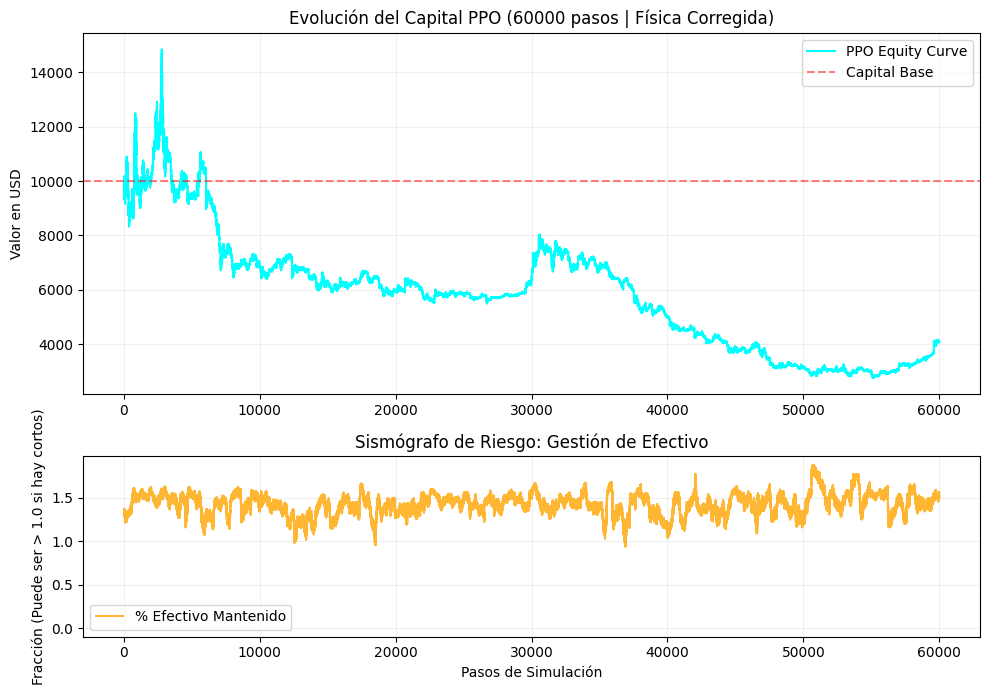

💰 Retorno Diagnóstico: -59.18%
🛡️ Uso Promedio de Efectivo: 142.29%


In [110]:
# =============================================================================
# FASE 2: ORQUESTACIÓN DEL AGENTE RL (GEOMETRÍA Y FÍSICA CORREGIDAS)
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import spaces
from numpy.lib.stride_tricks import sliding_window_view

print("\n" + "="*50)
print("🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO")
print("="*50)

# 1. RECUPERAR EL MODELO PRE-ENTRENADO
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: {device}")

model_eval = QuantRoberta(
    input_features_dim=60, 
    time_features_dim=3, 
    d_model=128
)
# 1. Cargar la red y los pesos congelados
encoder = model.to(device)
model.load_state_dict(torch.load("quantroberta_best.pth", map_location=device, weights_only=True))
model.eval()
encoder.eval()
device = next(encoder.parameters()).device

for param in encoder.parameters():
    param.requires_grad = False
print("✅ QuantRoberta congelado. Listo para extraer matrices [CLS].")

# 2. PRECOMPUTACIÓN ACELERADA DE ESTADOS LATENTES
def precompute_latents_for_rl(df_features, encoder, time_cols, feat_cols):
    x_data = df_features[feat_cols].values.astype(np.float32)
    t_data = df_features[time_cols].values.astype(np.float32)
    
    window_bars = 688
    x_w = sliding_window_view(x_data, window_shape=(window_bars, len(feat_cols))).squeeze(1)
    t_w = sliding_window_view(t_data, window_shape=(window_bars, len(time_cols))).squeeze(1)
    
    latents = np.zeros((len(df_features), encoder.d_model), dtype=np.float32)
    
    print(f"⚙️ Procesando {x_w.shape[0]} ventanas causales...")
    with torch.no_grad():
        for start in range(0, x_w.shape[0], 256):
            end = min(start + 256, x_w.shape[0])
            b_x = torch.from_numpy(np.ascontiguousarray(x_w[start:end])).to(device)
            b_t = torch.from_numpy(np.ascontiguousarray(t_w[start:end])).to(device)
            
            cls_out = encoder(
                x=b_x, t=b_t, 
                raw_padding_mask=None, 
                return_reconstruction=False, 
                spatial_mask=None
            )
            latents[np.arange(start, end) + (window_bars - 1)] = cls_out.cpu().numpy()
            
    return latents

train_latents = precompute_latents_for_rl(feat_train, encoder, time_cols, feature_cols)
print("✅ Matriz de latentes calculada.")

# 3. ENTORNO RL CORREGIDO (L1 PROJECTION Y DEADBAND)
class CleanTradingEnv(BaseTradingEnv):
    def __init__(self, prices: pd.DataFrame, latents: np.ndarray, d_model: int, transaction_cost_bps: float = 10.0):
        super().__init__(prices, transaction_cost_bps, initial_cash=10_000.0)
        self._latents = latents
        self._lookback = 687
        
        self.obs_dim = d_model + 4 + 1 
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        self._bars_since_trade = 0.0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._t = self._lookback
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        self._value = float(self.initial_cash)
        self._bars_since_trade = 0.0
        return self._obs(), {}

    def _obs(self):
        safe_t = min(self._t, len(self._latents) - 1)
        market_emb = self._latents[safe_t]
        
        # Evitar envenenamiento de NaNs si el capital se destruye temporalmente
        portfolio = np.nan_to_num(self._weights, nan=0.0).astype(np.float32)
        log_age = np.array([np.log1p(self._bars_since_trade)], dtype=np.float32)
        
        return np.concatenate([market_emb, portfolio, log_age], axis=0)

    def _weights_from_action(self, action):
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. Zona muerta: Destruye ruido neuronal exploratorio (< 5%)
        a = np.where(np.abs(a) < 0.05, 0.0, a)
        
        # 2. Proyección L1: Acota exposición bruta máxima al 100%
        gross_exposure = np.sum(np.abs(a))
        if gross_exposure > 1.0:
            a = a / gross_exposure 
            
        # 3. Blindaje Float32 (La solución al AssertionError)
        w_cash = float(1.0 - np.sum(a))
        w_cash = max(0.0, w_cash)  # Aniquila el residuo negativo (-1e-8)
        
        target_w = np.array([a[0], a[1], a[2], w_cash], dtype=np.float32)
        target_w = target_w / np.sum(target_w) # Fuerza suma matemática perfecta a 1.0
        
        # 4. Filtro de inercia: Rotaciones < 5% se ignoran para no desangrar comisiones
        current_w_safe = np.nan_to_num(self._weights, nan=0.0)
        turnover_intention = float(np.sum(np.abs(target_w - current_w_safe)))
        if turnover_intention < 0.05:  
            return self._weights.copy()
            
        return target_w

    def _reward(self, prev_value, curr_value):
        # Recompensa financiera pura (Sortino Implícito). Cero castigos por reglas que ya no se pueden romper.
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        if reward_bps < 0:
            reward_bps *= 2.5
        return float(np.clip(reward_bps, -75.0, 75.0))

    def step(self, action):
        prev_weights = self._weights.copy()
        obs, reward, terminated, truncated, info = super().step(action)
        
        # Stop-Loss Global de entrenamiento
        if self._value < 2000.0:
            truncated = True
            
        turnover = float(np.sum(np.abs(np.nan_to_num(self._weights, nan=0.0) - np.nan_to_num(prev_weights, nan=0.0))))
        if turnover > 1e-4:
            self._bars_since_trade = 0.0
        else:
            self._bars_since_trade += 1.0
            
        return self._obs(), reward, terminated, truncated, info

env_train = CleanTradingEnv(prices=data_train, latents=train_latents, d_model=encoder.d_model, transaction_cost_bps=0)
print(f"✅ Entorno instanciado. Dimensión de estado: {env_train.obs_dim}D")

# 4. ENTRENAMIENTO PPO
print(f"\n🚀 Iniciando Entrenamiento PPO (L1 Proyección)...")
agent = Agent(obs_dim=env_train.obs_dim, n_actions=3)
agent.train(env_train, n_steps=60_000)

# =============================================================================
# 5. DIAGNÓSTICO VISUAL RÁPIDO (EN CPU)
# =============================================================================
print("\n📈 Evaluando política determinista...")

original_device = agent.device
agent.device = torch.device("cpu")
agent.ac.to(agent.device)
agent.ac.eval()

obs, _ = env_train.reset()
done = False

portfolio_values = []
cash_weights = []

max_eval_steps = 60_000
step_count = 0

while not done and step_count < max_eval_steps:
    action = agent.act(obs) 
    obs, reward, terminated, truncated, _ = env_train.step(action)
    done = terminated or truncated
    
    portfolio_values.append(env_train._value)
    cash_weights.append(env_train._weights[3])
    step_count += 1

agent.device = original_device
agent.ac.to(agent.device)

# --- GRAFICAR RESULTADOS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(portfolio_values, color='cyan', linewidth=1.5, label='PPO Equity Curve')
ax1.axhline(y=10_000, color='red', linestyle='--', alpha=0.5, label='Capital Base')
ax1.set_title(f"Evolución del Capital PPO ({step_count} pasos | Física Corregida)")
ax1.set_ylabel("Valor en USD")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot(cash_weights, color='orange', alpha=0.8, label='% Efectivo Mantenido')
ax2.set_title("Sismógrafo de Riesgo: Gestión de Efectivo")
ax2.set_ylabel("Fracción (Puede ser > 1.0 si hay cortos)")

# LÍMITE DINÁMICO: Si se va en corto (Efectivo > 1.0), el gráfico crecerá con él para que no desaparezca.
if cash_weights:
    min_c = min(0.0, np.nanmin(cash_weights))
    max_c = max(1.1, np.nanmax(cash_weights))
    ax2.set_ylim(min_c - 0.1, max_c + 0.1)

ax2.set_xlabel("Pasos de Simulación")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

retorno = ((portfolio_values[-1] / 10_000) - 1) * 100
avg_cash = np.mean(np.nan_to_num(cash_weights)) * 100

print(f"💰 Retorno Diagnóstico: {retorno:+.2f}%")
print(f"🛡️ Uso Promedio de Efectivo: {avg_cash:.2f}%")


🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO
🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: cuda
✅ QuantRoberta congelado. Listo para extraer matrices [CLS].
⚙️ Procesando 222418 ventanas causales...
✅ Matriz de latentes calculada.
✅ Entorno instanciado. Dimensión de estado: 133D

🚀 Iniciando Entrenamiento PPO (Cuantizado)...
[Iter 1/14] Rew/Ep: -15833.28 | Actor Loss: +0.0018 | Value Loss: 36279.8333 | Entropía: 4.255
[Iter 2/14] Rew/Ep: -19886.04 | Actor Loss: -0.0012 | Value Loss: 43631.1019 | Entropía: 4.236
[Iter 3/14] Rew/Ep: -21372.06 | Actor Loss: -0.0027 | Value Loss: 37601.6692 | Entropía: 4.229
[Iter 4/14] Rew/Ep: -20922.09 | Actor Loss: -0.0022 | Value Loss: 41298.9841 | Entropía: 4.225
[Iter 5/14] Rew/Ep: -16304.48 | Actor Loss: -0.0014 | Value Loss: 26101.6472 | Entropía: 4.193
[Iter 6/14] Rew/Ep: -22137.31 | Actor Loss: -0.0040 | Value Loss: 35568.1943 | Entropía: 4.170
[Iter 7/14] Rew/Ep: -18101.53 | Actor Loss: -0.0036 | Value Loss: 29177.9106 | Entropía: 4.173


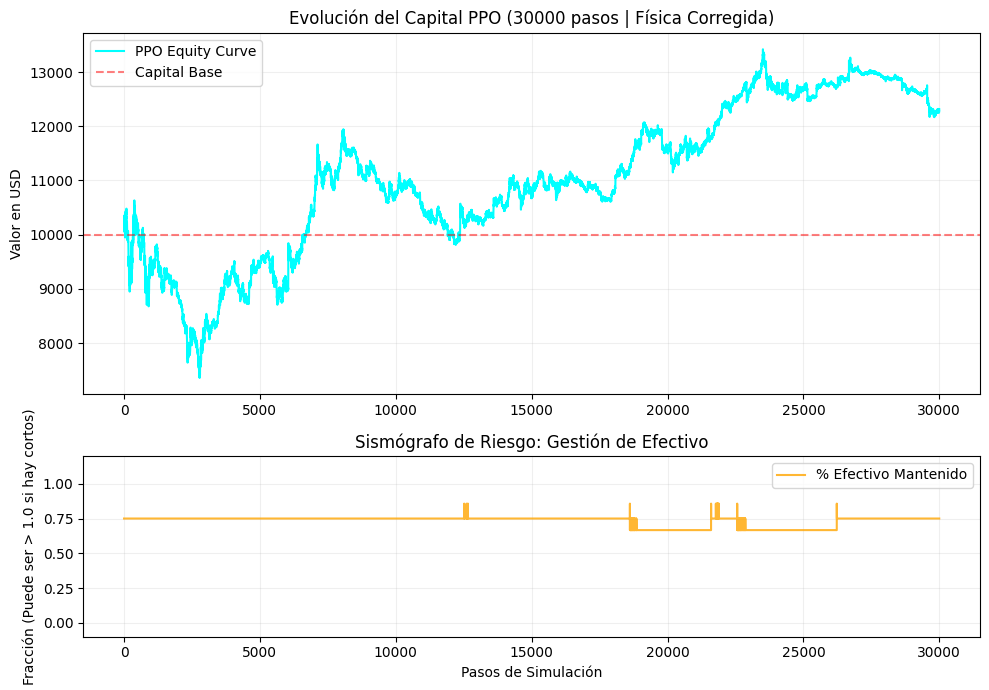

💰 Retorno Diagnóstico: +23.14%
🛡️ Uso Promedio de Efectivo: 73.21%


In [111]:
# =============================================================================
# FASE 2: ORQUESTACIÓN DEL AGENTE RL (GEOMETRÍA, FÍSICA Y TELEMETRÍA)
# =============================================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import spaces
from numpy.lib.stride_tricks import sliding_window_view

print("\n" + "="*50)
print("🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO")
print("="*50)

# 1. RECUPERAR EL MODELO PRE-ENTRENADO
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: {device}")

# Asumimos que model ya está instanciado y QuantRoberta está definido en memoria
encoder = model.to(device)
encoder.eval()
device = next(encoder.parameters()).device

for param in encoder.parameters():
    param.requires_grad = False
print("✅ QuantRoberta congelado. Listo para extraer matrices [CLS].")

# 2. PRECOMPUTACIÓN ACELERADA DE ESTADOS LATENTES
def precompute_latents_for_rl(df_features, encoder, time_cols, feat_cols):
    x_data = df_features[feat_cols].values.astype(np.float32)
    t_data = df_features[time_cols].values.astype(np.float32)
    
    window_bars = 688
    x_w = sliding_window_view(x_data, window_shape=(window_bars, len(feat_cols))).squeeze(1)
    t_w = sliding_window_view(t_data, window_shape=(window_bars, len(time_cols))).squeeze(1)
    
    latents = np.zeros((len(df_features), encoder.d_model), dtype=np.float32)
    
    print(f"⚙️ Procesando {x_w.shape[0]} ventanas causales...")
    with torch.no_grad():
        for start in range(0, x_w.shape[0], 256):
            end = min(start + 256, x_w.shape[0])
            b_x = torch.from_numpy(np.ascontiguousarray(x_w[start:end])).to(device)
            b_t = torch.from_numpy(np.ascontiguousarray(t_w[start:end])).to(device)
            
            cls_out = encoder(
                x=b_x, t=b_t, 
                raw_padding_mask=None, 
                return_reconstruction=False, 
                spatial_mask=None
            )
            latents[np.arange(start, end) + (window_bars - 1)] = cls_out.cpu().numpy()
            
    return latents

train_latents = precompute_latents_for_rl(feat_train, encoder, time_cols, feature_cols)
print("✅ Matriz de latentes calculada.")

# 3. ENTORNO RL CORREGIDO (CUANTIZACIÓN Y DEADBAND ESTRUCTURAL)
class CleanTradingEnv(BaseTradingEnv):
    def __init__(self, prices: pd.DataFrame, latents: np.ndarray, d_model: int, transaction_cost_bps: float = 10.0):
        super().__init__(prices, transaction_cost_bps, initial_cash=10_000.0)
        self._latents = latents
        self._lookback = 687
        
        self.obs_dim = d_model + 4 + 1 
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        self._bars_since_trade = 0.0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._t = self._lookback
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        self._value = float(self.initial_cash)
        self._bars_since_trade = 0.0
        return self._obs(), {}

    def _obs(self):
        safe_t = min(self._t, len(self._latents) - 1)
        market_emb = self._latents[safe_t]
        
        portfolio = np.nan_to_num(self._weights, nan=0.0).astype(np.float32)
        log_age = np.array([np.log1p(self._bars_since_trade)], dtype=np.float32)
        
        return np.concatenate([market_emb, portfolio, log_age], axis=0)

    def _weights_from_action(self, action):
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. CUANTIZACIÓN: Destruye ruido microscópico. Bloques del 20%
        a = np.round(a * 5.0) / 5.0
        
        # 2. Proyección L1: Acota exposición bruta máxima al 100%
        gross_exposure = np.sum(np.abs(a))
        if gross_exposure > 1.0:
            a = a / gross_exposure 
            
        # 3. Blindaje Float32
        w_cash = float(1.0 - np.sum(a))
        w_cash = max(0.0, w_cash) 
        
        target_w = np.array([a[0], a[1], a[2], w_cash], dtype=np.float32)
        target_w = target_w / np.sum(target_w) 
        
        # 4. FILTRO DE HISTÉRESIS (Muro de Inercia): 
        # Si no cambia al menos el 25% del portafolio, se asume inercia. Aniquila el turnover.
        current_w_safe = np.nan_to_num(self._weights, nan=0.0)
        turnover_intention = float(np.sum(np.abs(target_w - current_w_safe)))
        if turnover_intention < 0.25:  
            return self._weights.copy()
            
        return target_w

    def _reward(self, prev_value, curr_value):
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        if reward_bps < 0:
            reward_bps *= 2.5
        return float(np.clip(reward_bps, -75.0, 75.0))

    def step(self, action):
        prev_weights = self._weights.copy()
        obs, reward, terminated, truncated, info = super().step(action)
        
        if self._value < 2000.0:
            truncated = True
            
        turnover = float(np.sum(np.abs(np.nan_to_num(self._weights, nan=0.0) - np.nan_to_num(prev_weights, nan=0.0))))
        if turnover > 1e-4:
            self._bars_since_trade = 0.0
        else:
            self._bars_since_trade += 1.0
            
        return self._obs(), reward, terminated, truncated, info

# =============================================================================
# 4. PARCHE DE TELEMETRÍA PPO
# =============================================================================
def train_with_metrics(self, env, n_steps: int = 60_000):
    n_iters = max(1, n_steps // self.rollout_len)
    obs, _ = env.reset()
    obs = torch.from_numpy(obs).float().to(self.device)

    for it in range(n_iters):
        buffer = RolloutBuffer(self.rollout_len, self.obs_dim, self.action_dim, self.device)
        self.ac.eval()

        ep_returns = []
        running_ret = 0.0

        for _ in range(self.rollout_len):
            with torch.no_grad():
                dist = self.ac.get_action_dist(obs.unsqueeze(0))
                action = dist.sample()
                log_prob = dist.log_prob(action).sum(dim=-1)
                value = self.ac.get_value(obs.unsqueeze(0))
                a_np = action.squeeze(0).cpu().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(a_np)
            done = terminated or truncated
            running_ret += reward

            buffer.add(obs, action.squeeze(0), log_prob.squeeze(0), float(reward), value.squeeze(0), done)

            if done:
                ep_returns.append(running_ret)
                running_ret = 0.0
                next_obs, _ = env.reset()

            obs = torch.from_numpy(next_obs).float().to(self.device)

        with torch.no_grad():
            last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
            
        advantages, returns = compute_gae(buffer.rewards, buffer.values, buffer.dones, last_value, self.gamma, self.lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        self.ac.train()
        idx = np.arange(self.rollout_len)
        
        avg_actor_loss, avg_value_loss, avg_entropy = 0.0, 0.0, 0.0
        batches = 0

        for _ in range(self.epochs_ppo):
            np.random.shuffle(idx)
            for start in range(0, self.rollout_len, self.minibatch_size):
                mb = idx[start:start + self.minibatch_size]
                
                mb_obs, mb_acts, mb_old_lp = buffer.obs[mb], buffer.actions[mb], buffer.log_probs[mb]
                mb_adv, mb_ret = advantages[mb], returns[mb]

                dist = self.ac.get_action_dist(mb_obs)
                new_lp = dist.log_prob(mb_acts).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1)
                value = self.ac.get_value(mb_obs)

                ratio = torch.exp(new_lp - mb_old_lp)
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                
                actor_loss   = -torch.min(surr1, surr2).mean()
                value_loss   = F.mse_loss(value, mb_ret)
                entropy_loss = -entropy.mean()

                loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                self.optimizer.step()

                avg_actor_loss += actor_loss.item()
                avg_value_loss += value_loss.item()
                avg_entropy += (-entropy_loss.item())
                batches += 1

        mean_reward = np.mean(ep_returns) if ep_returns else running_ret
        print(f"[Iter {it+1}/{n_iters}] Rew/Ep: {mean_reward:+.2f} | "
              f"Actor Loss: {avg_actor_loss/batches:+.4f} | "
              f"Value Loss: {avg_value_loss/batches:.4f} | "
              f"Entropía: {avg_entropy/batches:.3f}")

# Inyectamos dinámicamente el método al Agente
Agent.train = train_with_metrics

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
env_train = CleanTradingEnv(prices=data_train, latents=train_latents, d_model=encoder.d_model, transaction_cost_bps=0)
print(f"✅ Entorno instanciado. Dimensión de estado: {env_train.obs_dim}D")

print(f"\n🚀 Iniciando Entrenamiento PPO (Cuantizado)...")
agent = Agent(obs_dim=env_train.obs_dim, n_actions=3)
agent.train(env_train, n_steps=30_000)

# =============================================================================
# 6. DIAGNÓSTICO VISUAL RÁPIDO (EN CPU)
# =============================================================================
print("\n📈 Evaluando política determinista...")

original_device = agent.device
agent.device = torch.device("cpu")
agent.ac.to(agent.device)
agent.ac.eval()

obs, _ = env_train.reset()
done = False

portfolio_values = []
cash_weights = []

max_eval_steps = 30_000
step_count = 0

while not done and step_count < max_eval_steps:
    action = agent.act(obs) 
    obs, reward, terminated, truncated, _ = env_train.step(action)
    done = terminated or truncated
    
    portfolio_values.append(env_train._value)
    cash_weights.append(env_train._weights[3])
    step_count += 1

agent.device = original_device
agent.ac.to(agent.device)

# --- GRAFICAR RESULTADOS ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(portfolio_values, color='cyan', linewidth=1.5, label='PPO Equity Curve')
ax1.axhline(y=10_000, color='red', linestyle='--', alpha=0.5, label='Capital Base')
ax1.set_title(f"Evolución del Capital PPO ({step_count} pasos | Física Corregida)")
ax1.set_ylabel("Valor en USD")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot(cash_weights, color='orange', alpha=0.8, label='% Efectivo Mantenido')
ax2.set_title("Sismógrafo de Riesgo: Gestión de Efectivo")
ax2.set_ylabel("Fracción (Puede ser > 1.0 si hay cortos)")

if cash_weights:
    min_c = min(0.0, np.nanmin(cash_weights))
    max_c = max(1.1, np.nanmax(cash_weights))
    ax2.set_ylim(min_c - 0.1, max_c + 0.1)

ax2.set_xlabel("Pasos de Simulación")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

retorno = ((portfolio_values[-1] / 10_000) - 1) * 100
avg_cash = np.mean(np.nan_to_num(cash_weights)) * 100

print(f"💰 Retorno Diagnóstico: {retorno:+.2f}%")
print(f"🛡️ Uso Promedio de Efectivo: {avg_cash:.2f}%")


🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO
🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: cuda
✅ QuantRoberta congelado. Listo para extraer matrices [CLS].
⚙️ Procesando 222418 ventanas causales...
✅ Matriz de latentes calculada.
✅ Entorno instanciado. Dimensión de estado: 133D

🚀 Iniciando Entrenamiento PPO...
[Iter 1/29] Rew/Ep: -103.11 | Actor Loss: +0.0099 | Value Loss: 0.4680 | Entropía: 1.257
[Iter 2/29] Rew/Ep: -136.30 | Actor Loss: +0.0055 | Value Loss: 0.2845 | Entropía: 1.255
[Iter 3/29] Rew/Ep: -135.93 | Actor Loss: -0.0014 | Value Loss: 0.2845 | Entropía: 1.298
[Iter 4/29] Rew/Ep: -148.73 | Actor Loss: -0.0014 | Value Loss: 0.2822 | Entropía: 1.336
[Iter 5/29] Rew/Ep: -129.25 | Actor Loss: +0.0020 | Value Loss: 0.2126 | Entropía: 1.328
[Iter 6/29] Rew/Ep: -127.98 | Actor Loss: -0.0008 | Value Loss: 0.2188 | Entropía: 1.305
[Iter 7/29] Rew/Ep: -159.78 | Actor Loss: +0.0002 | Value Loss: 0.2395 | Entropía: 1.294
[Iter 8/29] Rew/Ep: -162.31 | Actor Loss: -0.0004 | Val

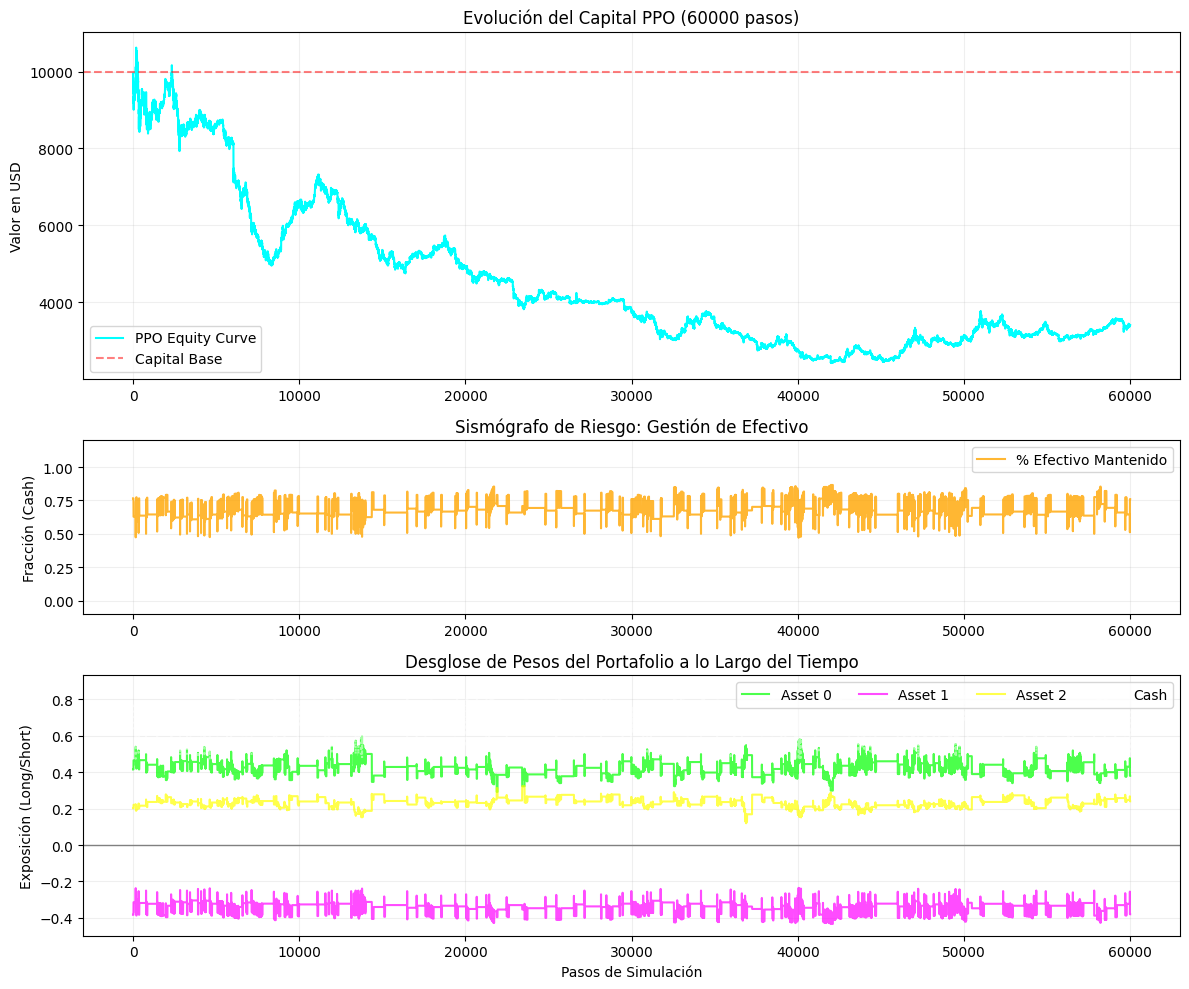

💰 Retorno Diagnóstico: -65.97%
🛡️ Uso Promedio de Efectivo: 69.82%


In [ ]:
# =============================================================================
# FASE 2: ORQUESTACIÓN DEL AGENTE RL (GEOMETRÍA, FÍSICA Y TELEMETRÍA)
# =============================================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import spaces
from numpy.lib.stride_tricks import sliding_window_view

print("\n" + "="*50)
print("🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO")
print("="*50)

# 1. RECUPERAR EL MODELO PRE-ENTRENADO
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: {device}")

model_eval = QuantRoberta(
    input_features_dim=60, 
    time_features_dim=3, 
    d_model=128
)
# 1. Cargar la red y los pesos congelados
encoder = model.to(device)
model.load_state_dict(torch.load("quantroberta_best.pth", map_location=device, weights_only=True))
model.eval()
encoder.eval()
device = next(encoder.parameters()).device

for param in encoder.parameters():
    param.requires_grad = False
print("✅ QuantRoberta congelado. Listo para extraer matrices [CLS].")

# 2. PRECOMPUTACIÓN ACELERADA DE ESTADOS LATENTES
def precompute_latents_for_rl(df_features, encoder, time_cols, feat_cols):
    x_data = df_features[feat_cols].values.astype(np.float32)
    t_data = df_features[time_cols].values.astype(np.float32)
    
    window_bars = 688
    x_w = sliding_window_view(x_data, window_shape=(window_bars, len(feat_cols))).squeeze(1)
    t_w = sliding_window_view(t_data, window_shape=(window_bars, len(time_cols))).squeeze(1)
    
    latents = np.zeros((len(df_features), encoder.d_model), dtype=np.float32)
    
    print(f"⚙️ Procesando {x_w.shape[0]} ventanas causales...")
    with torch.no_grad():
        for start in range(0, x_w.shape[0], 256):
            end = min(start + 256, x_w.shape[0])
            b_x = torch.from_numpy(np.ascontiguousarray(x_w[start:end])).to(device)
            b_t = torch.from_numpy(np.ascontiguousarray(t_w[start:end])).to(device)
            
            cls_out = encoder(
                x=b_x, t=b_t, 
                raw_padding_mask=None, 
                return_reconstruction=False, 
                spatial_mask=None
            )
            latents[np.arange(start, end) + (window_bars - 1)] = cls_out.cpu().numpy()
            
    return latents

train_latents = precompute_latents_for_rl(feat_train, encoder, time_cols, feature_cols)
print("✅ Matriz de latentes calculada.")

# 3. ENTORNO RL CORREGIDO (CUANTIZACIÓN, DEADBAND Y RECOMPENSA ESCALADA)
class CleanTradingEnv(BaseTradingEnv):
    def __init__(self, prices: pd.DataFrame, latents: np.ndarray, d_model: int, transaction_cost_bps: float = 10.0):
        super().__init__(prices, transaction_cost_bps, initial_cash=10_000.0)
        self._latents = latents
        self._lookback = 687
        
        self.obs_dim = d_model + 4 + 1 
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        self._bars_since_trade = 0.0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._t = self._lookback
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        self._value = float(self.initial_cash)
        self._bars_since_trade = 0.0
        return self._obs(), {}

    def _obs(self):
        safe_t = min(self._t, len(self._latents) - 1)
        market_emb = self._latents[safe_t]
        
        portfolio = np.nan_to_num(self._weights, nan=0.0).astype(np.float32)
        log_age = np.array([np.log1p(self._bars_since_trade)], dtype=np.float32)
        
        return np.concatenate([market_emb, portfolio, log_age], axis=0)

    def _weights_from_action(self, action):
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. CUANTIZACIÓN: Destruye ruido microscópico. Bloques del 20%
        a = np.round(a * 50.0) / 50.0
        
        # 2. Proyección L1: Acota exposición bruta máxima al 100%
        gross_exposure = np.sum(np.abs(a))
        if gross_exposure > 1.0:
            a = a / gross_exposure 
            
        # 3. Blindaje Float32
        w_cash = float(1.0 - np.sum(a))
        w_cash = max(0.0, w_cash) 
        
        target_w = np.array([a[0], a[1], a[2], w_cash], dtype=np.float32)
        target_w = target_w / np.sum(target_w) 
        
        # 4. FILTRO DE HISTÉRESIS (Muro de Inercia): Aniquila el turnover.
        current_w_safe = np.nan_to_num(self._weights, nan=0.0)
        turnover_intention = float(np.sum(np.abs(target_w - current_w_safe)))
        if turnover_intention < 0.25:  
            return self._weights.copy()
            
        return target_w

    def _reward(self, prev_value, curr_value):
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        if reward_bps < 0:
            reward_bps *= 2.5
        # Reducimos la escala para estabilizar el Value Loss del Crítico
        return float(np.clip(reward_bps, -50.0, 50.0)) / 100.0

    def step(self, action):
        prev_weights = self._weights.copy()
        obs, reward, terminated, truncated, info = super().step(action)
        
        if self._value < 2000.0:
            truncated = True
            
        turnover = float(np.sum(np.abs(np.nan_to_num(self._weights, nan=0.0) - np.nan_to_num(prev_weights, nan=0.0))))
        if turnover > 1e-4:
            self._bars_since_trade = 0.0
        else:
            self._bars_since_trade += 1.0
            
        return self._obs(), reward, terminated, truncated, info

# =============================================================================
# 4. PARCHE DE TELEMETRÍA PPO Y PÉRDIDA HUBER
# =============================================================================
def train_with_metrics(self, env, n_steps: int = 60_000):
    n_iters = max(1, n_steps // self.rollout_len)
    obs, _ = env.reset()
    obs = torch.from_numpy(obs).float().to(self.device)

    for it in range(n_iters):
        buffer = RolloutBuffer(self.rollout_len, self.obs_dim, self.action_dim, self.device)
        self.ac.eval()

        ep_returns = []
        running_ret = 0.0

        for _ in range(self.rollout_len):
            with torch.no_grad():
                dist = self.ac.get_action_dist(obs.unsqueeze(0))
                action = dist.sample()
                log_prob = dist.log_prob(action).sum(dim=-1)
                value = self.ac.get_value(obs.unsqueeze(0))
                a_np = action.squeeze(0).cpu().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(a_np)
            done = terminated or truncated
            running_ret += reward

            buffer.add(obs, action.squeeze(0), log_prob.squeeze(0), float(reward), value.squeeze(0), done)

            if done:
                ep_returns.append(running_ret)
                running_ret = 0.0
                next_obs, _ = env.reset()

            obs = torch.from_numpy(next_obs).float().to(self.device)

        with torch.no_grad():
            last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
            
        advantages, returns = compute_gae(buffer.rewards, buffer.values, buffer.dones, last_value, self.gamma, self.lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        self.ac.train()
        idx = np.arange(self.rollout_len)
        
        avg_actor_loss, avg_value_loss, avg_entropy = 0.0, 0.0, 0.0
        batches = 0

        for _ in range(self.epochs_ppo):
            np.random.shuffle(idx)
            for start in range(0, self.rollout_len, self.minibatch_size):
                mb = idx[start:start + self.minibatch_size]
                
                mb_obs, mb_acts, mb_old_lp = buffer.obs[mb], buffer.actions[mb], buffer.log_probs[mb]
                mb_adv, mb_ret = advantages[mb], returns[mb]

                dist = self.ac.get_action_dist(mb_obs)
                new_lp = dist.log_prob(mb_acts).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1)
                value = self.ac.get_value(mb_obs)

                ratio = torch.exp(new_lp - mb_old_lp)
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                
                actor_loss   = -torch.min(surr1, surr2).mean()
                
                # REEMPLAZO A HUBER LOSS (Smooth L1) PARA ESTABILIZAR GRADIENTES EXTREMOS
                value_loss   = F.smooth_l1_loss(value, mb_ret, beta=1.0)
                entropy_loss = -entropy.mean()

                loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                self.optimizer.step()

                avg_actor_loss += actor_loss.item()
                avg_value_loss += value_loss.item()
                avg_entropy += (-entropy_loss.item())
                batches += 1

        mean_reward = np.mean(ep_returns) if ep_returns else running_ret
        print(f"[Iter {it+1}/{n_iters}] Rew/Ep: {mean_reward:+.2f} | "
              f"Actor Loss: {avg_actor_loss/batches:+.4f} | "
              f"Value Loss: {avg_value_loss/batches:.4f} | "
              f"Entropía: {avg_entropy/batches:.3f}")

Agent.train = train_with_metrics

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
env_train = CleanTradingEnv(prices=data_train, latents=train_latents, d_model=encoder.d_model, transaction_cost_bps=0)
print(f"✅ Entorno instanciado. Dimensión de estado: {env_train.obs_dim}D")

print(f"\n🚀 Iniciando Entrenamiento PPO...")
agent = Agent(obs_dim=env_train.obs_dim, n_actions=3)

# AJUSTES DE ESTABILIZACIÓN DEL AGENTE (Control del Caos Inicial)
agent.c_entropy = 0.001 


agent.train(env_train, n_steps=30_000)

# =============================================================================
# 6. DIAGNÓSTICO VISUAL: CURVA DE CAPITAL Y COMPOSICIÓN DEL PORTAFOLIO
# =============================================================================
print("\n📈 Evaluando política determinista...")

original_device = agent.device
agent.device = torch.device("cpu")
agent.ac.to(agent.device)
agent.ac.eval()

obs, _ = env_train.reset()
done = False

portfolio_values = []
all_weights = []

max_eval_steps = 30_000
step_count = 0

while not done and step_count < max_eval_steps:
    action = agent.act(obs) 
    obs, reward, terminated, truncated, _ = env_train.step(action)
    done = terminated or truncated
    
    portfolio_values.append(env_train._value)
    all_weights.append(env_train._weights.copy())
    step_count += 1

agent.device = original_device
agent.ac.to(agent.device)

all_weights = np.array(all_weights) # Shape: (steps, 4)

# --- GRAFICAR RESULTADOS (3 PANELES) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1, 1.5]})

# Panel 1: Capital
ax1.plot(portfolio_values, color='cyan', linewidth=1.5, label='PPO Equity Curve')
ax1.axhline(y=10_000, color='red', linestyle='--', alpha=0.5, label='Capital Base')
ax1.set_title(f"Evolución del Capital PPO ({step_count} pasos)")
ax1.set_ylabel("Valor en USD")
ax1.legend()
ax1.grid(alpha=0.2)

# Panel 2: Efectivo Exclusivo
ax2.plot(all_weights[:, 3], color='orange', alpha=0.8, label='% Efectivo Mantenido')
ax2.set_title("Sismógrafo de Riesgo: Gestión de Efectivo")
ax2.set_ylabel("Fracción (Cash)")
if len(all_weights) > 0:
    min_c = min(0.0, np.nanmin(all_weights[:, 3]))
    max_c = max(1.1, np.nanmax(all_weights[:, 3]))
    ax2.set_ylim(min_c - 0.1, max_c + 0.1)
ax2.legend()
ax2.grid(alpha=0.2)

# Panel 3: Composición Completa del Portafolio
ax3.plot(all_weights[:, 0], color='lime', alpha=0.7, label='Asset 0')
ax3.plot(all_weights[:, 1], color='magenta', alpha=0.7, label='Asset 1')
ax3.plot(all_weights[:, 2], color='yellow', alpha=0.7, label='Asset 2')
ax3.plot(all_weights[:, 3], color='white', linestyle=':', alpha=0.5, label='Cash')
ax3.axhline(y=0.0, color='gray', linestyle='-', linewidth=1)
ax3.set_title("Desglose de Pesos del Portafolio a lo Largo del Tiempo")
ax3.set_ylabel("Exposición (Long/Short)")
ax3.set_xlabel("Pasos de Simulación")
ax3.legend(loc='upper right', ncol=4)
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

retorno = ((portfolio_values[-1] / 10_000) - 1) * 100
avg_cash = np.mean(np.nan_to_num(all_weights[:, 3])) * 100

print(f"💰 Retorno Diagnóstico: {retorno:+.2f}%")
print(f"🛡️ Uso Promedio de Efectivo: {avg_cash:.2f}%")


🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO
🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: cuda
✅ QuantRoberta congelado. Listo para extraer matrices [CLS].
⚙️ Procesando 222418 ventanas causales...
✅ Matriz de latentes calculada.
✅ Entorno instanciado. Dimensión de estado: 133D

🚀 Iniciando Entrenamiento PPO (Cuantizado)...
[Iter 1/14] Rew/Ep: -17154.75 | Actor Loss: -0.0021 | Value Loss: 38059.8114 | Entropía: 4.236
[Iter 2/14] Rew/Ep: -21759.18 | Actor Loss: -0.0022 | Value Loss: 43478.6529 | Entropía: 4.212
[Iter 3/14] Rew/Ep: -20624.98 | Actor Loss: -0.0034 | Value Loss: 36777.9602 | Entropía: 4.202
[Iter 4/14] Rew/Ep: -19582.06 | Actor Loss: -0.0013 | Value Loss: 39579.3272 | Entropía: 4.206
[Iter 5/14] Rew/Ep: -18973.86 | Actor Loss: -0.0022 | Value Loss: 28279.5999 | Entropía: 4.225
[Iter 6/14] Rew/Ep: -16934.45 | Actor Loss: -0.0028 | Value Loss: 25903.8870 | Entropía: 4.229
[Iter 7/14] Rew/Ep: -16043.16 | Actor Loss: -0.0023 | Value Loss: 20331.9273 | Entropía: 4.217


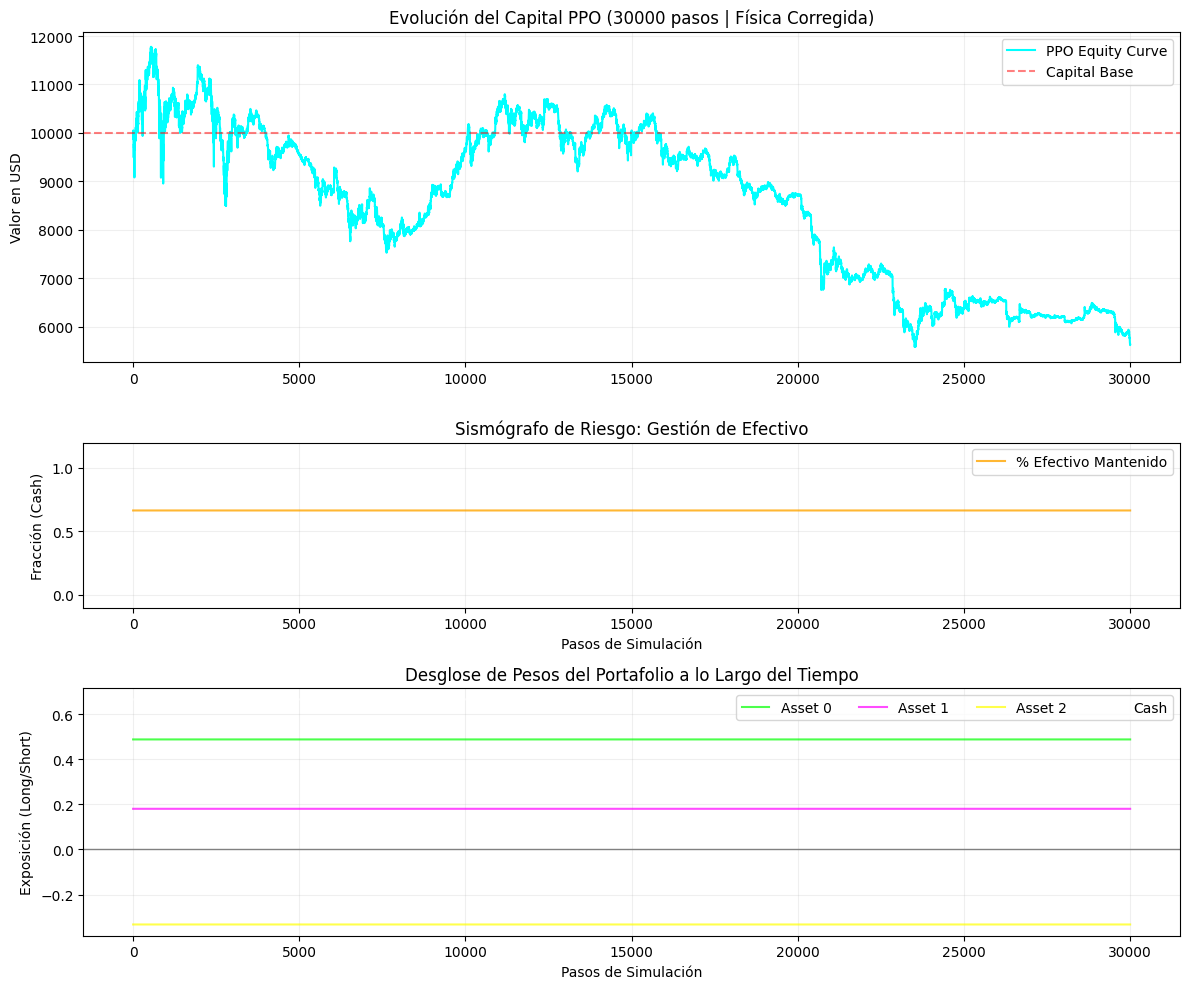

💰 Retorno Diagnóstico: -43.69%
🛡️ Uso Promedio de Efectivo: 66.48%


In [114]:
# =============================================================================
# FASE 2: ORQUESTACIÓN DEL AGENTE RL (GEOMETRÍA Y FÍSICA CORREGIDAS)
# =============================================================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import spaces
from numpy.lib.stride_tricks import sliding_window_view

print("\n" + "="*50)
print("🛡️ INICIANDO FASE 2: PRECOMPUTACIÓN Y PPO")
print("="*50)

# 1. RECUPERAR EL MODELO PRE-ENTRENADO
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"🔍 Evaluando conjunto de Test fuera de muestra (OOS) en: {device}")

model_eval = QuantRoberta(
    input_features_dim=60, 
    time_features_dim=3, 
    d_model=128
)
# 1. Cargar la red y los pesos congelados
encoder = model.to(device)
model.load_state_dict(torch.load("quantroberta_best.pth", map_location=device, weights_only=True))
model.eval()
encoder.eval()
device = next(encoder.parameters()).device

for param in encoder.parameters():
    param.requires_grad = False
print("✅ QuantRoberta congelado. Listo para extraer matrices [CLS].")

# 2. PRECOMPUTACIÓN ACELERADA DE ESTADOS LATENTES
def precompute_latents_for_rl(df_features, encoder, time_cols, feat_cols):
    x_data = df_features[feat_cols].values.astype(np.float32)
    t_data = df_features[time_cols].values.astype(np.float32)
    
    window_bars = 688
    x_w = sliding_window_view(x_data, window_shape=(window_bars, len(feat_cols))).squeeze(1)
    t_w = sliding_window_view(t_data, window_shape=(window_bars, len(time_cols))).squeeze(1)
    
    latents = np.zeros((len(df_features), encoder.d_model), dtype=np.float32)
    
    print(f"⚙️ Procesando {x_w.shape[0]} ventanas causales...")
    with torch.no_grad():
        for start in range(0, x_w.shape[0], 256):
            end = min(start + 256, x_w.shape[0])
            b_x = torch.from_numpy(np.ascontiguousarray(x_w[start:end])).to(device)
            b_t = torch.from_numpy(np.ascontiguousarray(t_w[start:end])).to(device)
            
            cls_out = encoder(
                x=b_x, t=b_t, 
                raw_padding_mask=None, 
                return_reconstruction=False, 
                spatial_mask=None
            )
            latents[np.arange(start, end) + (window_bars - 1)] = cls_out.cpu().numpy()
            
    return latents

train_latents = precompute_latents_for_rl(feat_train, encoder, time_cols, feature_cols)
print("✅ Matriz de latentes calculada.")

# 3. ENTORNO RL CORREGIDO (L1 PROJECTION Y DEADBAND)
class CleanTradingEnv(BaseTradingEnv):
    def __init__(self, prices: pd.DataFrame, latents: np.ndarray, d_model: int, transaction_cost_bps: float = 10.0):
        super().__init__(prices, transaction_cost_bps, initial_cash=10_000.0)
        self._latents = latents
        self._lookback = 687
        
        self.obs_dim = d_model + 4 + 1 
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        
        self._bars_since_trade = 0.0

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._t = self._lookback
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        self._value = float(self.initial_cash)
        self._bars_since_trade = 0.0
        return self._obs(), {}

    def _obs(self):
        safe_t = min(self._t, len(self._latents) - 1)
        market_emb = self._latents[safe_t]
        
        portfolio = np.nan_to_num(self._weights, nan=0.0).astype(np.float32)
        log_age = np.array([np.log1p(self._bars_since_trade)], dtype=np.float32)
        
        return np.concatenate([market_emb, portfolio, log_age], axis=0)

    def _weights_from_action(self, action):
        a = np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0)
        
        # 1. CUANTIZACIÓN: Destruye ruido microscópico. Bloques del 20%
        k = 1000.
        a = np.round(a * k) / k
        
        # 2. Proyección L1: Acota exposición bruta máxima al 100%
        gross_exposure = np.sum(np.abs(a))
        if gross_exposure > 1.0:
            a = a / gross_exposure 
            
        # 3. Blindaje Float32
        w_cash = float(1.0 - np.sum(a))
        w_cash = max(0.0, w_cash) 
        
        target_w = np.array([a[0], a[1], a[2], w_cash], dtype=np.float32)
        target_w = target_w / np.sum(target_w) 
        
        # 4. Filtro de inercia: Rotaciones < 25% se ignoran para no desangrar comisiones
        current_w_safe = np.nan_to_num(self._weights, nan=0.0)
        turnover_intention = float(np.sum(np.abs(target_w - current_w_safe)))
        if turnover_intention < 0.25:  
            return self._weights.copy()
            
        return target_w

    def _reward(self, prev_value, curr_value):
        reward_bps = np.log(curr_value / max(prev_value, 1e-8)) * 10_000.0
        if reward_bps < 0:
            reward_bps *= 2.5
        return float(np.clip(reward_bps, -75.0, 75.0))

    def step(self, action):
        prev_weights = self._weights.copy()
        obs, reward, terminated, truncated, info = super().step(action)
        
        if self._value < 2000.0:
            truncated = True
            
        turnover = float(np.sum(np.abs(np.nan_to_num(self._weights, nan=0.0) - np.nan_to_num(prev_weights, nan=0.0))))
        if turnover > 1e-4:
            self._bars_since_trade = 0.0
        else:
            self._bars_since_trade += 1.0
            
        return self._obs(), reward, terminated, truncated, info

# =============================================================================
# 4. PARCHE DE TELEMETRÍA PPO (MANTENIENDO MSE_LOSS)
# =============================================================================
def train_with_metrics(self, env, n_steps: int = 60_000):
    n_iters = max(1, n_steps // self.rollout_len)
    obs, _ = env.reset()
    obs = torch.from_numpy(obs).float().to(self.device)

    for it in range(n_iters):
        buffer = RolloutBuffer(self.rollout_len, self.obs_dim, self.action_dim, self.device)
        self.ac.eval()

        ep_returns = []
        running_ret = 0.0

        for _ in range(self.rollout_len):
            with torch.no_grad():
                dist = self.ac.get_action_dist(obs.unsqueeze(0))
                action = dist.sample()
                log_prob = dist.log_prob(action).sum(dim=-1)
                value = self.ac.get_value(obs.unsqueeze(0))
                a_np = action.squeeze(0).cpu().numpy()

            next_obs, reward, terminated, truncated, _ = env.step(a_np)
            done = terminated or truncated
            running_ret += reward

            buffer.add(obs, action.squeeze(0), log_prob.squeeze(0), float(reward), value.squeeze(0), done)

            if done:
                ep_returns.append(running_ret)
                running_ret = 0.0
                next_obs, _ = env.reset()

            obs = torch.from_numpy(next_obs).float().to(self.device)

        with torch.no_grad():
            last_value = self.ac.get_value(obs.unsqueeze(0)).squeeze(0)
            
        advantages, returns = compute_gae(buffer.rewards, buffer.values, buffer.dones, last_value, self.gamma, self.lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        self.ac.train()
        idx = np.arange(self.rollout_len)
        
        avg_actor_loss, avg_value_loss, avg_entropy = 0.0, 0.0, 0.0
        batches = 0

        for _ in range(self.epochs_ppo):
            np.random.shuffle(idx)
            for start in range(0, self.rollout_len, self.minibatch_size):
                mb = idx[start:start + self.minibatch_size]
                
                mb_obs, mb_acts, mb_old_lp = buffer.obs[mb], buffer.actions[mb], buffer.log_probs[mb]
                mb_adv, mb_ret = advantages[mb], returns[mb]

                dist = self.ac.get_action_dist(mb_obs)
                new_lp = dist.log_prob(mb_acts).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1)
                value = self.ac.get_value(mb_obs)

                ratio = torch.exp(new_lp - mb_old_lp)
                surr1 = ratio * mb_adv
                surr2 = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * mb_adv
                
                actor_loss   = -torch.min(surr1, surr2).mean()
                
                # SE MANTIENE MSE ESTRICTAMENTE
                value_loss   = F.mse_loss(value, mb_ret)
                
                entropy_loss = -entropy.mean()

                loss = actor_loss + self.c_value * value_loss + self.c_entropy * entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.ac.parameters(), self.grad_clip)
                self.optimizer.step()

                avg_actor_loss += actor_loss.item()
                avg_value_loss += value_loss.item()
                avg_entropy += (-entropy_loss.item())
                batches += 1

        mean_reward = np.mean(ep_returns) if ep_returns else running_ret
        print(f"[Iter {it+1}/{n_iters}] Rew/Ep: {mean_reward:+.2f} | "
              f"Actor Loss: {avg_actor_loss/batches:+.4f} | "
              f"Value Loss: {avg_value_loss/batches:.4f} | "
              f"Entropía: {avg_entropy/batches:.3f}")

Agent.train = train_with_metrics

# =============================================================================
# 5. EJECUCIÓN DEL ENTRENAMIENTO
# =============================================================================
env_train = CleanTradingEnv(prices=data_train, latents=train_latents, d_model=encoder.d_model, transaction_cost_bps=0)
print(f"✅ Entorno instanciado. Dimensión de estado: {env_train.obs_dim}D")

print(f"\n🚀 Iniciando Entrenamiento PPO (Cuantizado)...")
agent = Agent(obs_dim=env_train.obs_dim, n_actions=3)
agent.train(env_train, n_steps=30_000)

# =============================================================================
# 6. DIAGNÓSTICO VISUAL RÁPIDO (EN CPU)
# =============================================================================
print("\n📈 Evaluando política determinista...")

original_device = agent.device
agent.device = torch.device("cpu")
agent.ac.to(agent.device)
agent.ac.eval()

obs, _ = env_train.reset()
done = False

portfolio_values = []
cash_weights = []
all_weights = []  # Lista añadida para capturar el portafolio completo

max_eval_steps = 30_000
step_count = 0

while not done and step_count < max_eval_steps:
    action = agent.act(obs) 
    obs, reward, terminated, truncated, _ = env_train.step(action)
    done = terminated or truncated
    
    portfolio_values.append(env_train._value)
    cash_weights.append(env_train._weights[3])
    all_weights.append(env_train._weights.copy()) # Guardado de pesos por iteración
    step_count += 1

agent.device = original_device
agent.ac.to(agent.device)

all_weights = np.array(all_weights) # Shape: (steps, 4)

# --- GRAFICAR RESULTADOS (3 PANELES) ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1, 1.5]})

ax1.plot(portfolio_values, color='cyan', linewidth=1.5, label='PPO Equity Curve')
ax1.axhline(y=10_000, color='red', linestyle='--', alpha=0.5, label='Capital Base')
ax1.set_title(f"Evolución del Capital PPO ({step_count} pasos | Física Corregida)")
ax1.set_ylabel("Valor en USD")
ax1.legend()
ax1.grid(alpha=0.2)

ax2.plot(cash_weights, color='orange', alpha=0.8, label='% Efectivo Mantenido')
ax2.set_title("Sismógrafo de Riesgo: Gestión de Efectivo")
ax2.set_ylabel("Fracción (Cash)")

if cash_weights:
    min_c = min(0.0, np.nanmin(cash_weights))
    max_c = max(1.1, np.nanmax(cash_weights))
    ax2.set_ylim(min_c - 0.1, max_c + 0.1)

ax2.set_xlabel("Pasos de Simulación")
ax2.legend()
ax2.grid(alpha=0.2)

# PANEL AÑADIDO: Composición Completa del Portafolio
ax3.plot(all_weights[:, 0], color='lime', alpha=0.7, label='Asset 0')
ax3.plot(all_weights[:, 1], color='magenta', alpha=0.7, label='Asset 1')
ax3.plot(all_weights[:, 2], color='yellow', alpha=0.7, label='Asset 2')
ax3.plot(all_weights[:, 3], color='white', linestyle=':', alpha=0.5, label='Cash')
ax3.axhline(y=0.0, color='gray', linestyle='-', linewidth=1)
ax3.set_title("Desglose de Pesos del Portafolio a lo Largo del Tiempo")
ax3.set_ylabel("Exposición (Long/Short)")
ax3.set_xlabel("Pasos de Simulación")
ax3.legend(loc='upper right', ncol=4)
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

retorno = ((portfolio_values[-1] / 10_000) - 1) * 100
avg_cash = np.mean(np.nan_to_num(cash_weights)) * 100

print(f"💰 Retorno Diagnóstico: {retorno:+.2f}%")
print(f"🛡️ Uso Promedio de Efectivo: {avg_cash:.2f}%")